This notebook implements a pipeline for detecting parasites using the Segment Anything Model (SAM).

**Model Architecture**

We fine-tune SAM using Low-Rank Adaptation (LoRA), which injects small trainable matrices into the image encoder's attention layers while keeping the base weights frozen. The mask decoder is fully trainable.

**Preprocessing and Tiling**

Full-resolution specimen images are preprocessed with CLAHE for contrast enhancement, then split into fixed 1024×1024 tiles. This notebook uses **negative sampling**: in addition to all parasite-containing tiles, we retain ~15% of empty intestine tiles as negative examples. This helps the model learn to distinguish parasites from normal tissue, reducing false positive detections.


In [ ]:
import os
!git clone https://github.com/ia-project-parasite/IA-PROJECT-PARASITE-REPO.git
os.chdir('IA-PROJECT-PARASITE-REPO')

Cloning into 'IA-PROJECT-PARASITE-REPO'...
remote: Enumerating objects: 431, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 431 (delta 20), reused 77 (delta 16), pack-reused 345 (from 1)
Receiving objects: 100% (431/431), 730.61 MiB | 60.86 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (206/206), done.


In [ ]:
!pip install -q torch torchvision
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python scikit-image pandas numpy matplotlib tqdm scikit-learn
!pip install -q loralib

  Preparing metadata (setup.py) ... done


In [ ]:
import os
import cv2
import numpy as np
import json
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from scipy.ndimage import label as ndimage_label
from skimage.morphology import remove_small_holes, remove_small_objects
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import random
import shutil
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
from segment_anything import sam_model_registry
import loralib as lora  # LoRA library

## Dataset Preprocessing Functions


**Image Enhancement** `apply_clahe_and_brightness(bgr)`

Enhances image visibility using a two-stage approach:
1. CLAHE applied to the luminance channel in LAB color space (preserves color fidelity)
2. Fixed brightness boost via HSV value channel

**Specimen Segmentation**

`specimen_mask(bgr, use_hull=False)`

Isolates the specimen from the background using adaptive thresholding on HSV channels. The algorithm:
- Computes Otsu's threshold on the value channel, scaled to 70% for robustness
- Applies morphological opening/closing to clean up noise
- Retains only the largest connected component
- Optionally returns convex hull for simplified boundary

`roi_from_mask(img, mask, pad=10)`

Extracts a bounding box around the masked region with optional padding. Returns cropped image and mask.


In [ ]:
def apply_clahe_and_brightness(bgr):
    """
    Apply contrast-limited adaptive histogram equalization (CLAHE)
    followed by a brightness boost to enhance image visibility.

    Args:
        bgr: Input image in BGR color space

    Returns:
        Enhanced BGR image with improved contrast and brightness
    """
    # Convert to LAB color space to work on luminance channel
    img_lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)

    # Apply CLAHE to luminance channel only (preserves color information)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l2 = clahe.apply(l)

    # Merge enhanced luminance back with original color channels
    img_lab = cv2.merge((l2, a, b))
    bgr_corr = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)

    # Additional brightness boost via HSV value channel
    hsv = cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    v = cv2.add(v, 15)  # Add fixed brightness offset (saturates at 255)
    hsv = cv2.merge([h, s, v])
    bgr_corr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    return bgr_corr


def specimen_mask(bgr, use_hull=False):
    """
    Generate a binary mask isolating the specimen from background.
    Uses adaptive thresholding on value/saturation channels.

    Args:
        bgr: Input image in BGR color space
        use_hull: If True, return convex hull of specimen instead of actual boundary

    Returns:
        Boolean mask where True indicates specimen pixels
    """
    # Convert to HSV for better foreground/background separation
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)

    # Use Otsu's method to find optimal threshold, then scale down for robustness
    ret, _ = cv2.threshold(V, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    v_thr, s_thr = int(max(ret * 0.7, 25)), 15  # Minimum thresholds to avoid noise

    # Mask pixels with sufficient brightness and saturation (excludes dark background)
    m = ((V >= v_thr) & (S >= s_thr)).astype(np.uint8)

    # Morphological cleanup to remove noise and fill small gaps
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)   # Remove small bright spots
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)  # Fill small holes

    # Remove small disconnected regions and fill remaining holes
    m = remove_small_objects(m.astype(bool), min_size=3000)
    m = remove_small_holes(m, area_threshold=50000).astype(np.uint8)

    # Keep only the largest connected component (assumes single specimen)
    n, lab = cv2.connectedComponents(m)
    if n <= 1:
        return np.zeros(m.shape, bool)  # No foreground found
    cnts = np.bincount(lab.ravel())[1:]  # Skip background (label 0)
    keep = 1 + np.argmax(cnts)
    m = (lab == keep).astype(np.uint8)

    # Optionally compute convex hull for a simpler boundary
    if use_hull:
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            hull = cv2.convexHull(np.vstack(contours))
            m_hull = np.zeros_like(m)
            cv2.drawContours(m_hull, [hull], -1, 1, -1)
            m = m_hull

    return m.astype(bool)


def roi_from_mask(img, mask, pad=10):
    """
    Extract the bounding box region of interest from a binary mask.

    Args:
        img: Source image to crop
        mask: Binary mask indicating region of interest
        pad: Padding in pixels around the bounding box

    Returns:
        Tuple of (bbox_coords, cropped_image, cropped_mask) or (None, None, None) if empty
    """
    # Find all True pixels in the mask
    ys, xs = np.where(mask)
    if len(ys) == 0 or len(xs) == 0:
        return None, None, None

    # Compute bounding box with padding, clipped to image bounds
    y0, y1 = max(0, ys.min() - pad), min(img.shape[0], ys.max() + pad)
    x0, x1 = max(0, xs.min() - pad), min(img.shape[1], xs.max() + pad)

    return (y0, y1, x0, x1), img[y0:y1, x0:x1], mask[y0:y1, x0:x1]


def get_white_points_from_label(label_img):
    """
    Extract coordinates of white (bright) pixels from a label/annotation image.
    Used to parse point annotations marking parasite locations.

    Args:
        label_img: Annotation image (grayscale or BGR) with white markers

    Returns:
        List of (x, y) tuples for each white pixel
    """
    # Convert to grayscale if needed
    if len(label_img.shape) == 3:
        gray = cv2.cvtColor(label_img, cv2.COLOR_BGR2GRAY)
    else:
        gray = label_img

    # Threshold to isolate near-white pixels (annotation markers)
    _, thresh = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)
    ys, xs = np.where(thresh > 0)

    if len(xs) == 0:
        return []

    # Return as (x, y) coordinate pairs
    points = [(int(x), int(y)) for x, y in zip(xs, ys)]
    return points


def extract_centroids_from_points(points, img_shape):
    """
    Convert a dense point cloud (e.g., from brush annotations) into
    distinct object centroids via connected component analysis.

    Args:
        points: List of (x, y) coordinates forming annotation blobs
        img_shape: Shape of the original image (for creating binary mask)

    Returns:
        List of (x, y) centroid coordinates, one per connected region
    """
    if len(points) == 0:
        return []

    # Reconstruct binary mask from point list
    binary_mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for x, y in points:
        if 0 <= y < img_shape[0] and 0 <= x < img_shape[1]:
            binary_mask[y, x] = 255

    # Label connected components (each annotation blob becomes one region)
    labeled_mask, num_parasites = ndimage_label(binary_mask)

    # Compute centroid for each labeled region
    centroids = []
    for region_id in range(1, num_parasites + 1):
        ys, xs = np.where(labeled_mask == region_id)
        if len(ys) > 0:
            centroid_x = int(xs.mean())
            centroid_y = int(ys.mean())
            centroids.append((centroid_x, centroid_y))

    return centroids

## Tiling

The `split_images_fixed_grid_with_intestine` function extends basic tiling by including a controlled subset of empty intestine tiles as negative examples. This helps the model learn to distinguish parasites from normal tissue, reducing false positives. The `keep_empty_ratio` parameter controls the fraction of empty tiles retained (default: 15%).

In [ ]:
def split_images_fixed_grid_with_intestine(
        original_img, label_img, mask_img, points,
        tile_size=1024, roi_bbox=None,
        specimen_mask=None, keep_empty_ratio=0.15,
        min_tissue_ratio=0.10):
    """
    Split images into fixed-size tiles with intelligent negative sampling.

    Unlike basic tiling that only keeps parasite-containing tiles, this version
    also retains a controlled subset of empty intestine tiles. This provides
    the model with negative examples (tissue without parasites), which is
    essential for reducing false positives during inference.

    Tile selection strategy:
        - Parasite tiles: Always kept (100%)
        - Empty intestine tiles: Randomly sampled (keep_empty_ratio fraction)
        - Background tiles: Always discarded (no learning value)

    Args:
        original_img: Source image to tile (H, W, 3)
        label_img: Annotation image with parasite markers
        mask_img: Optional mask for each tile
        points: List of (x, y) parasite centroid coordinates
        tile_size: Size of square tiles (default: 1024)
        roi_bbox: Optional ROI bounding box (unused, for API compatibility)
        specimen_mask: Binary mask indicating intestine tissue (0=background, 255=tissue)
        keep_empty_ratio: Fraction of empty intestine tiles to retain (default: 0.15)
        min_tissue_ratio: Minimum tissue coverage to classify as intestine tile (default: 0.10)

    Returns:
        List of tile dictionaries with metadata including tile_type ('parasite' or 'empty_intestine')
    """
    import random
    import numpy as np

    height, width = original_img.shape[:2]
    tiles = []
    tile_count = 0

    # Track statistics for logging
    stats = {
        'parasite_tiles': 0,
        'empty_intestine': 0,
        'empty_background': 0,
        'empty_intestine_kept': 0
    }

    # Iterate over non-overlapping grid
    for y in range(0, height, tile_size):
        for x in range(0, width, tile_size):

            # Define tile window
            x1, y1 = x, y
            x2, y2 = min(x + tile_size, width), min(y + tile_size, height)

            # Crop all image layers
            tile_original = original_img[y1:y2, x1:x2]
            tile_label = label_img[y1:y2, x1:x2]
            tile_mask = mask_img[y1:y2, x1:x2] if mask_img is not None else None
            tile_specimen = specimen_mask[y1:y2, x1:x2] if specimen_mask is not None else None

            # Handle edge tiles that need padding
            actual_h, actual_w = tile_original.shape[:2]
            if actual_h < tile_size or actual_w < tile_size:

                def pad_tile(tile, channels=1):
                    """Zero-pad tile to target size."""
                    shape = (tile_size, tile_size, channels) if channels == 3 else (tile_size, tile_size)
                    padded = np.zeros(shape, dtype=np.uint8)
                    padded[:actual_h, :actual_w] = tile
                    return padded

                tile_original = pad_tile(tile_original, 3)
                tile_label = pad_tile(tile_label, 3 if len(tile_label.shape) == 3 else 1)
                tile_mask = pad_tile(tile_mask) if tile_mask is not None else None
                tile_specimen = pad_tile(tile_specimen) if tile_specimen is not None else None

            # Find parasite points within this tile (convert to local coordinates)
            tile_points = [
                (px - x1, py - y1)
                for (px, py) in points
                if x1 <= px < x2 and y1 <= py < y2
            ]

            # Decide whether to keep this tile
            keep_tile = False
            tile_type = None

            if len(tile_points) > 0:
                # ALWAYS keep tiles containing parasites
                keep_tile = True
                tile_type = "parasite"
                stats['parasite_tiles'] += 1

            else:
                # No parasites - check if tile contains intestine tissue
                if tile_specimen is not None:
                    tissue_pixels = (tile_specimen > 0).sum()
                    total_pixels = tile_specimen.size
                    tissue_ratio = tissue_pixels / total_pixels

                    if tissue_ratio >= min_tissue_ratio:
                        # Tile has significant intestine tissue
                        stats['empty_intestine'] += 1

                        # Randomly sample a subset of empty intestine tiles
                        if random.random() < keep_empty_ratio:
                            keep_tile = True
                            tile_type = "empty_intestine"
                            stats['empty_intestine_kept'] += 1
                    else:
                        # Tile is mostly background - discard
                        stats['empty_background'] += 1

            # Store tile if selected
            if keep_tile:
                tiles.append({
                    'tile_original': tile_original,
                    'tile_label': tile_label,
                    'tile_mask': tile_mask,
                    'points_local': tile_points,
                    'tile_id': f"tile_{tile_count:04d}",
                    'global_bbox': (x1, y1, x2, y2),
                    'num_parasites': len(tile_points),
                    'tile_type': tile_type
                })
                tile_count += 1

    # Log tile selection statistics
    print(f"  Tile Statistics:")
    print(f"    Parasite tiles:        {stats['parasite_tiles']}")
    print(f"    Empty with intestine:  {stats['empty_intestine']} ({stats['empty_intestine_kept']} kept)")
    print(f"    Empty background:      {stats['empty_background']} (discarded)")
    print(f"    Total kept:            {len(tiles)}")

    # Report class balance ratio
    if stats['empty_intestine_kept'] > 0:
        ratio = stats['parasite_tiles'] / stats['empty_intestine_kept']
        print(f"    Ratio (parasite:empty): {ratio:.1f}:1")

    return tiles

In [ ]:
def process_image_complete(
        image_path, label_path, mask_path, image_id,
        tile_size=1024, apply_clahe=True, extract_roi=True,
        keep_empty_ratio=0.15, min_tissue_ratio=0.10):  # ⭐ ADDED PARAMETER
    import os
    import cv2

    img = cv2.imread(image_path)
    label = cv2.imread(label_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if mask_path and os.path.exists(mask_path) else None

    if img is None or label is None:
        print(f"Warning: Could not read {image_id}")
        return []

    original_shape = img.shape

    if apply_clahe:
        img = apply_clahe_and_brightness(img)

    roi_bbox = None
    specimen_mask_img = None

    if extract_roi:
        specimen_m = specimen_mask(img, use_hull=False)
        bbox, img_roi, mask_roi = roi_from_mask(img, specimen_m, pad=10)

        if bbox is None:
            # No ROI found, use original
            img_roi = img
            label_roi = label
            mask_roi_img = mask
            specimen_mask_img = specimen_m.astype(np.uint8) * 255
        else:
            y0, y1, x0, x1 = bbox
            roi_bbox = bbox

            img_roi = img_roi.copy()
            img_roi[~mask_roi] = 0

            label_roi = label[y0:y1, x0:x1]
            mask_roi_img = mask[y0:y1, x0:x1] if mask is not None else None

            specimen_mask_img = mask_roi.astype(np.uint8) * 255

    else:
        img_roi = img
        label_roi = label
        mask_roi_img = mask
        specimen_mask_img = None

    points = get_white_points_from_label(label_roi)
    if len(points) == 0:
        return []

    centroids = extract_centroids_from_points(points, label_roi.shape)
    print(f"  [{image_id}] {len(points)} pixels → {len(centroids)} centroids")

    if len(centroids) == 0:
        return []

    # --- NEW tiling with intestine awareness ---
    tiles = split_images_fixed_grid_with_intestine(
        img_roi, label_roi, mask_roi_img, centroids,
        tile_size=tile_size,
        roi_bbox=roi_bbox,
        specimen_mask=specimen_mask_img,
        keep_empty_ratio=keep_empty_ratio,
        min_tissue_ratio=min_tissue_ratio   # pass parameter
    )

    for tile in tiles:
        tile['image_id'] = f"{image_id}_{tile['tile_id']}"
        tile['base_image_id'] = image_id
        tile['original_shape'] = original_shape
        tile['roi_bbox'] = roi_bbox

    return tiles


In [ ]:
import os
import cv2
import json
from tqdm import tqdm

museum_labels_dir = "Museum labels"
output_dir = "Combined_Dataset"
TILE_SIZE = 1024

os.makedirs(output_dir, exist_ok=True)

# Find all subfolders
folders = [
    f for f in os.listdir(museum_labels_dir)
    if os.path.isdir(os.path.join(museum_labels_dir, f))
]

all_tiles = []
tiles_per_image = {}

stats = {
    'total_parasite': 0,
    'total_empty': 0
}

for folder in tqdm(folders, desc="Processing images"):
    folder_path = os.path.join(museum_labels_dir, folder)

    # File paths
    raw_img_path = os.path.join(folder_path, f"{folder}.JPG")
    label_mask_path = os.path.join(folder_path, f"{folder}_labels.png")
    mask_path = os.path.join(folder_path, f"{folder}_mask.png")

    # Labels may be JPG instead of PNG
    if not os.path.exists(label_mask_path):
        label_mask_path = os.path.join(folder_path, f"{folder}_labels.JPG")

    # Skip if missing
    if not os.path.exists(raw_img_path) or not os.path.exists(label_mask_path):
        continue

    # Process
    tiles = process_image_complete(
        raw_img_path,
        label_mask_path,
        mask_path if os.path.exists(mask_path) else None,
        folder,
        tile_size=TILE_SIZE,
        apply_clahe=True,
        extract_roi=True,
        keep_empty_ratio=0.40,
        min_tissue_ratio=0.10
    )

    if len(tiles) == 0:
        continue

    n_parasite = sum(1 for t in tiles if t['num_parasites'] > 0)
    n_empty = sum(1 for t in tiles if t['num_parasites'] == 0)

    stats['total_parasite'] += n_parasite
    stats['total_empty'] += n_empty

    image_output_dir = os.path.join(output_dir, folder)
    tiles_dir = os.path.join(image_output_dir, "tiles")
    labels_dir = os.path.join(image_output_dir, "labels")
    masks_dir = os.path.join(image_output_dir, "masks")
    annotations_dir = os.path.join(image_output_dir, "annotations")

    os.makedirs(tiles_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)
    os.makedirs(masks_dir, exist_ok=True)
    os.makedirs(annotations_dir, exist_ok=True)


    for tile in tiles:
        tile_id = tile['tile_id']

        # Save tile images
        cv2.imwrite(os.path.join(tiles_dir, f"{tile_id}.png"), tile['tile_original'])
        cv2.imwrite(os.path.join(labels_dir, f"{tile_id}.png"), tile['tile_label'])

        if tile['tile_mask'] is not None:
            cv2.imwrite(os.path.join(masks_dir, f"{tile_id}.png"), tile['tile_mask'])


        x1g, y1g, x2g, y2g = tile['global_bbox']

        annotation_data = {
            'tile_id': tile['image_id'],
            'base_image_id': tile['base_image_id'],

            'num_parasites': tile['num_parasites'],
            'tile_type': tile['tile_type'],  # parasite / empty_intestine

            'centroids_local': [
                [int(x), int(y)] for x, y in tile['points_local']
            ],

            'centroids_global': [
                [int(x + x1g), int(y + y1g)]
                for x, y in tile['points_local']
            ],

            # Small bounding box around each centroid
            'bboxes_local': [
                [
                    max(0, int(x - 20)),
                    max(0, int(y - 20)),
                    min(TILE_SIZE, int(x + 20)),
                    min(TILE_SIZE, int(y + 20))
                ]
                for x, y in tile['points_local']
            ],

            'box_size': 40,
            'tile_bbox': [int(x1g), int(y1g), int(x2g), int(y2g)],
            'original_shape': [int(d) for d in tile['original_shape']],
            'roi_bbox': (
                [int(d) for d in tile['roi_bbox']]
                if tile['roi_bbox'] is not None else None
            )
        }

        with open(os.path.join(annotations_dir, f"{tile_id}.json"), "w") as f:
            json.dump(annotation_data, f, indent=2)

    # Track per-image tile count
    all_tiles.extend(tiles)
    tiles_per_image[folder] = len(tiles)

print("FINAL STATISTICS")
print("="*70)
print(f"Total images:         {len(tiles_per_image)}")
print(f"Total tiles:          {len(all_tiles)}")
print(f"Parasite tiles:       {stats['total_parasite']}")
print(f"Empty tiles:          {stats['total_empty']}")

if stats['total_empty'] > 0:
    ratio = stats['total_parasite'] / stats['total_empty']
    print(f"Ratio (parasite:empty): {ratio:.1f}:1")

print(f"Total parasites:      {sum(t['num_parasites'] for t in all_tiles)}")
print("\nTiles per image:")
print(tiles_per_image)


Processing images:   0%|          | 0/44 [00:00<?, ?it/s]

  [B2025-00146c] 10460 pixels → 291 centroids
  Tile Statistics:
    Parasite tiles:        8
    Empty with intestine:  0 (0 kept)
    Empty background:      7 (discarded)
    Total kept:            8


Processing images:   2%|▏         | 1/44 [00:15<11:00, 15.35s/it]

  [B2025-00139b] 9395 pixels → 127 centroids
  Tile Statistics:
    Parasite tiles:        8
    Empty with intestine:  0 (0 kept)
    Empty background:      8 (discarded)
    Total kept:            8


Processing images:   5%|▍         | 2/44 [00:24<08:03, 11.50s/it]

...

  [B2025-00139a-1] 38 pixels → 38 centroids
  Tile Statistics:
    Parasite tiles:        2
    Empty with intestine:  1 (0 kept)
    Empty background:      3 (discarded)
    Total kept:            2


Processing images:  98%|█████████▊| 43/44 [08:25<00:06,  6.74s/it]

  [B2025-00142a] 6 pixels → 6 centroids
  Tile Statistics:
    Parasite tiles:        1
    Empty with intestine:  5 (2 kept)
    Empty background:      10 (discarded)
    Total kept:            3
    Ratio (parasite:empty): 0.5:1
  [B2025-00130e] 170 pixels → 170 centroids
  Tile Statistics:
    Parasite tiles:        7
    Empty with intestine:  1 (1 kept)
    Empty background:      1 (discarded)
    Total kept:            8
    Ratio (parasite:empty): 7.0:1


Processing images: 100%|██████████| 44/44 [08:33<00:00, 11.66s/it]

FINAL STATISTICS
Total images:         44
Total tiles:          332
Parasite tiles:       312
Empty tiles:          20
Ratio (parasite:empty): 15.6:1
Total parasites:      9703

Tiles per image:
{'B2025-00146c': 8, 'B2025-00139b': 8, 'B2025-00172a': 9, 'B2025-00144b': 9, 'B2025-00158a': 10, 'B2025-00146a': 9, 'B2025-00231b': 6, 'B2025-00155e': 9, 'B2025-00137b': 12, 'B2025-00150a': 8, 'B2025-00173b': 6, 'B2025-00158b': 6, 'B2025-00182c': 6, 'B2025-00172b': 7, 'B2025-00138b': 6, 'B2025-00206b': 7, 'B2025-00085k': 10, 'B2025-00136b': 7, 'B2025-00085e': 14, 'B2025-00149d': 8, 'B2025-00156a': 7, 'B2025-00176a': 8, 'B2025-00130b': 8, 'B2025-00171a': 6, 'B2025-00234a': 6, 'B2025-00150c': 10, 'B2025-00153a': 10, 'B2025-00130c': 9, 'B2025-00153b': 7, 'B2025-00140b': 8, 'B2025-00234b': 5, 'B2025-00139a': 4, 'B2025-00143b': 7, 'B2025-00086a': 8, 'B2025-00141a': 8, 'B2025-00085.2': 9, 'B2025-00176b': 6, 'B2025-00084n': 4, 'B2025-00141c': 7, 'B2025-00137d': 9, 'B2025-00173a': 8, 'B2025-00139a-1': 

## Split Dataset (Train/Val/Test)

In [ ]:
splits = {
    'train': [
        'B2025-00085e', 'B2025-00085k',
        'B2025-00150a', 'B2025-00150c',
        'B2025-00130b', 'B2025-00130c',
        'B2025-00158a', 'B2025-00158b',
        'B2025-00172a', 'B2025-00172b',
        'B2025-00173a', 'B2025-00173b',
        'B2025-00141a', 'B2025-00141c',
        'B2025-00176a', 'B2025-00176b',
        'B2025-00153a',
        'B2025-00146c', 'B2025-00137b',
        'B2025-00149d', 'B2025-00146a',
        'B2025-00144b', 'B2025-00156a',
        'B2025-00155e', 'B2025-00139b',
        'B2025-00137d',
        'B2025-00086a', 'B2025-00140b'
    ],

    'val': [
        'B2025-00234a', 'B2025-00084n',
        'B2025-00139a', 'B2025-00139a-1',
        'B2025-00138b', 'B2025-00171a',
        'B2025-00182c'
    ],

    'test': [
        'B2025-00231b', 'B2025-00143b',
        'B2025-00206b', 'B2025-00136b',
        'B2025-00085.2', 'B2025-00142a'
    ]
}

print(f"Train: {len(splits['train'])} images")
print(f"Val:   {len(splits['val'])} images")
print(f"Test:  {len(splits['test'])} images")
print(f"\nTrain images: {splits['train']}")
print(f"Val images:   {splits['val']}")
print(f"Test images:  {splits['test']}")

Train: 28 images
Val:   7 images
Test:  6 images

Train images: ['B2025-00085e', 'B2025-00085k', 'B2025-00150a', 'B2025-00150c', 'B2025-00130b', 'B2025-00130c', 'B2025-00158a', 'B2025-00158b', 'B2025-00172a', 'B2025-00172b', 'B2025-00173a', 'B2025-00173b', 'B2025-00141a', 'B2025-00141c', 'B2025-00176a', 'B2025-00176b', 'B2025-00153a', 'B2025-00146c', 'B2025-00137b', 'B2025-00149d', 'B2025-00146a', 'B2025-00144b', 'B2025-00156a', 'B2025-00155e', 'B2025-00139b', 'B2025-00137d', 'B2025-00086a', 'B2025-00140b']
Val images:   ['B2025-00234a', 'B2025-00084n', 'B2025-00139a', 'B2025-00139a-1', 'B2025-00138b', 'B2025-00171a', 'B2025-00182c']
Test images:  ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']


## Dataset Class for PyTorch

The `SAMDatasetNoPrompt_Fixed` class applies ImageNet normalization to match SAM's pretraining. SAM was trained on images normalized with ImageNet mean and standard deviation, so inputs should use the same normalization for optimal feature extraction. Geometric augmentations (flips, 90° rotations) are applied during training.

In [ ]:
class SAMDatasetNoPrompt_Fixed(Dataset):
    """
    PyTorch Dataset for SAM fine-tuning with proper ImageNet normalization.

    This is a  version that applies ImageNet normalization to match
    SAM's pretrained weights. SAM was trained on ImageNet-normalized images,
    so input images should be normalized the same way for optimal performance.

    Normalization: (image - mean) / std
        - mean: [0.485, 0.456, 0.406] (ImageNet RGB means)
        - std: [0.229, 0.224, 0.225] (ImageNet RGB stds)
    """

    def __init__(self, image_ids, output_dir, augment=False):
        """
        Initialize dataset with ImageNet normalization.

        Args:
            image_ids: List of image IDs to include in dataset
            output_dir: Root directory containing processed tiles
            augment: Enable geometric augmentation for training (default: False)
        """
        self.samples = []
        self.augment = augment

        # ImageNet normalization parameters (must match SAM's pretraining)
        self.pixel_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.pixel_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

        # Collect all valid samples from specified images
        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            masks_dir = os.path.join(output_dir, img_id, "masks")
            annotations_dir = os.path.join(output_dir, img_id, "annotations")

            if not os.path.exists(tiles_dir):
                continue

            tile_files = [f for f in os.listdir(tiles_dir) if f.endswith('.png')]

            for tile_file in tile_files:
                tile_id = tile_file.replace('.png', '')
                tile_path = os.path.join(tiles_dir, tile_file)
                mask_path = os.path.join(masks_dir, f"{tile_id}.png")
                anno_path = os.path.join(annotations_dir, f"{tile_id}.json")

                # Only include samples with both mask and annotation files
                if os.path.exists(mask_path) and os.path.exists(anno_path):
                    with open(anno_path, 'r') as f:
                        anno = json.load(f)

                    self.samples.append({
                        'tile_path': tile_path,
                        'mask_path': mask_path,
                        'tile_id': tile_id,
                        'base_image_id': img_id,
                        'num_parasites': anno['num_parasites']
                    })

        print(f"Loaded {len(self.samples)} samples (augment={augment}, normalized=ImageNet)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        """
        Load and preprocess a single tile-mask pair with ImageNet normalization.

        Returns:
            Dictionary containing:
                - image: Normalized tensor [3, H, W] with ImageNet stats
                - mask: Binary mask tensor [1, H, W]
                - tile_id: Unique tile identifier
                - num_parasites: Number of parasites in this tile
        """
        sample = self.samples[idx]

        # Load image (BGR to RGB) and mask
        image = cv2.imread(sample['tile_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE)
        binary_mask = (mask > 127).astype(np.float32)

        # Apply geometric augmentation (training only)
        # Note: .copy() is required to avoid negative strides from flip/rot90
        if self.augment:
            # Random horizontal flip
            if random.random() > 0.5:
                image = cv2.flip(image, 1).copy()
                binary_mask = cv2.flip(binary_mask, 1).copy()
            # Random vertical flip
            if random.random() > 0.5:
                image = cv2.flip(image, 0).copy()
                binary_mask = cv2.flip(binary_mask, 0).copy()
            # Random 90-degree rotation
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                image = np.rot90(image, k).copy()
                binary_mask = np.rot90(binary_mask, k).copy()

        # Convert to tensor and scale to [0, 1]
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        # Apply ImageNet normalization (critical for SAM performance)
        image_tensor = (image_tensor - self.pixel_mean) / self.pixel_std

        mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'tile_id': sample['tile_id'],
            'num_parasites': sample['num_parasites']
        }

## SAM Fine-Tuner with LoRA



The `SAMFineTuner_LoRA` class implements parameter-efficient fine-tuning using Low-Rank Adaptation. It injects trainable LoRA adapters into the image encoder's attention layers while keeping base weights frozen, and fully trains the mask decoder. The loss function combines BCE and Dice, with optional positive class weighting (`pos_weight > 1.0`) to penalize false negatives and improve detection sensitivity.

In [ ]:
class SAMFineTuner_LoRA:
    """
    Fine-tuner for Segment Anything Model (SAM) using Low-Rank Adaptation (LoRA).

    LoRA enables parameter-efficient fine-tuning by injecting trainable low-rank
    matrices into the attention layers while keeping the base model frozen.

    Training strategy:
        - Image encoder: Frozen except for LoRA adapters on QKV projections
        - Prompt encoder: Fully frozen (no prompts used)
        - Mask decoder: Fully trainable

    Loss function:
        - BCE Loss: Pixel-level classification with optional positive class weighting
        - Dice Loss: Region-level overlap optimization
    """

    def __init__(self, sam_model, device, learning_rate=1e-4, lora_rank=8,
                 optimizer_type='adam', weight_decay=1e-4,
                 bce_weight=1.0, dice_weight=1.0,
                 pos_weight=1.0, grad_clip=None):
        """
        Initialize SAM fine-tuner with LoRA and detection optimization.

        Args:
            sam_model: Pretrained SAM model instance
            device: Target device ('cuda' or 'cpu')
            learning_rate: Learning rate for optimizer (default: 1e-4)
            lora_rank: Rank of LoRA decomposition matrices (default: 8)
            optimizer_type: Optimizer choice - 'adam', 'adamw', or 'sgd'
            weight_decay: L2 regularization strength (default: 1e-4)
            bce_weight: Weight for BCE loss component (default: 1.0)
            dice_weight: Weight for Dice loss component (default: 1.0)
            pos_weight: Positive class weight for BCE (default: 1.0)
                        Values > 1.0 penalize false negatives more heavily
            grad_clip: Maximum gradient norm for clipping (default: None)
        """
        self.sam = sam_model
        self.device = device
        self.lora_rank = lora_rank
        self.grad_clip = grad_clip
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        # Inject LoRA adapters into image encoder attention layers
        self._apply_lora_to_image_encoder()

        # Freeze base image encoder, keep only LoRA parameters trainable
        for name, param in self.sam.image_encoder.named_parameters():
            if 'lora' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        # Freeze prompt encoder entirely (not used in prompt-free mode)
        for param in self.sam.prompt_encoder.parameters():
            param.requires_grad = False

        # Train mask decoder fully
        for param in self.sam.mask_decoder.parameters():
            param.requires_grad = True

        # Collect trainable parameters: LoRA adapters + mask decoder
        lora_params = [p for n, p in self.sam.image_encoder.named_parameters()
                       if 'lora' in n and p.requires_grad]
        decoder_params = list(self.sam.mask_decoder.parameters())
        trainable_params = lora_params + decoder_params

        # Initialize optimizer based on specified type
        if optimizer_type.lower() == 'adam':
            self.optimizer = torch.optim.Adam(trainable_params, lr=learning_rate)
        elif optimizer_type.lower() == 'adamw':
            self.optimizer = torch.optim.AdamW(trainable_params, lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_type.lower() == 'sgd':
            self.optimizer = torch.optim.SGD(trainable_params, lr=learning_rate, momentum=0.9, weight_decay=weight_decay)

        # Configure BCE loss with optional positive class weighting
        # Higher pos_weight helps with class imbalance (sparse parasites)
        if pos_weight > 1.0:
            self.bce_loss = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor([pos_weight]).to(device)
            )
            print(f"Using pos_weight={pos_weight} (detection-optimized)")
        else:
            self.bce_loss = nn.BCEWithLogitsLoss()

        self.dice_loss = self.dice_loss_fn

        # Log parameter counts for verification
        total_params = sum(p.numel() for p in self.sam.parameters())
        trainable_params_count = sum(p.numel() for p in self.sam.parameters() if p.requires_grad)
        lora_params_count = sum(p.numel() for p in lora_params)

        print(f"Trainable parameters: {trainable_params_count:,} ({100*trainable_params_count/total_params:.2f}%)")
        print(f"  - LoRA parameters:  {lora_params_count:,}")
        print(f"  - Decoder parameters: {trainable_params_count - lora_params_count:,}")

    def _apply_lora_to_image_encoder(self):
        """
        Apply LoRA adapters to QKV projection layers in each transformer block.

        For each attention layer, the original linear projection is replaced with
        a LoRA-augmented version that adds a low-rank update: W' = W + BA
        where B and A are the trainable low-rank matrices.
        """
        for block_idx, block in enumerate(self.sam.image_encoder.blocks):
            attn = block.attn
            original_qkv = attn.qkv
            in_features = original_qkv.in_features
            out_features = original_qkv.out_features

            # Preserve original pretrained weights
            original_weight = original_qkv.weight.data.clone()
            original_bias = original_qkv.bias.data.clone() if original_qkv.bias is not None else None

            # Create LoRA-augmented linear layer
            lora_qkv = lora.Linear(
                in_features,
                out_features,
                r=self.lora_rank,
                lora_alpha=self.lora_rank * 2,
                lora_dropout=0.1,
                merge_weights=False,
                bias=original_qkv.bias is not None
            )

            # Move to device before copying weights
            lora_qkv = lora_qkv.to(self.device)

            # Copy pretrained weights to new layer
            with torch.no_grad():
                lora_qkv.weight.copy_(original_weight.to(self.device))
                if original_bias is not None:
                    lora_qkv.bias.copy_(original_bias.to(self.device))

            # Replace original layer with LoRA version
            attn.qkv = lora_qkv

        print(f"Applied LoRA (rank={self.lora_rank}) to {len(self.sam.image_encoder.blocks)} transformer blocks")

    def dice_loss_fn(self, pred, target, smooth=1e-5):
        """
        Compute Dice loss for segmentation.

        Args:
            pred: Predicted logits (B, 1, H, W)
            target: Ground truth binary masks (B, 1, H, W)
            smooth: Smoothing term to avoid division by zero

        Returns:
            Scalar Dice loss (1 - Dice coefficient)
        """
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice.mean()

    def compute_metrics(self, pred, target, threshold=0.5):
        """
        Compute confusion matrix components for metric accumulation.

        Args:
            pred: Predicted logits
            target: Ground truth masks
            threshold: Binarization threshold for predictions

        Returns:
            Dictionary with tp, fp, fn, tn counts
        """
        pred_binary = (torch.sigmoid(pred) > threshold).float()
        target_binary = target.float()

        pred_flat = pred_binary.view(-1)
        target_flat = target_binary.view(-1)

        tp = (pred_flat * target_flat).sum()
        fp = (pred_flat * (1 - target_flat)).sum()
        fn = ((1 - pred_flat) * target_flat).sum()
        tn = ((1 - pred_flat) * (1 - target_flat)).sum()

        return {'tp': tp.item(), 'fp': fp.item(), 'fn': fn.item(), 'tn': tn.item()}

    @staticmethod
    def compute_final_metrics(total_tp, total_fp, total_fn, total_tn):
        """
        Compute final evaluation metrics from accumulated confusion matrix counts.

        Args:
            total_tp: Total true positives across all batches
            total_fp: Total false positives
            total_fn: Total false negatives
            total_tn: Total true negatives

        Returns:
            Dictionary with IoU, Dice, precision, recall, and F1 scores
        """
        smooth = 1e-7
        iou = (total_tp + smooth) / (total_tp + total_fp + total_fn + smooth)
        dice = (2 * total_tp + smooth) / (2 * total_tp + total_fp + total_fn + smooth)
        precision = (total_tp + smooth) / (total_tp + total_fp + smooth)
        recall = (total_tp + smooth) / (total_tp + total_fn + smooth)
        f1 = (2 * precision * recall) / (precision + recall + smooth)

        return {
            'iou': iou,
            'dice': dice,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    def train_step(self, batch):
        """
        Execute single training step with forward pass, loss computation, and weight update.

        Args:
            batch: Dictionary containing 'image' and 'mask' tensors

        Returns:
            Dictionary with loss values and metric components
        """
        self.sam.train()
        self.optimizer.zero_grad()

        # Move data to device
        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Forward pass through image encoder (LoRA adapters active)
        image_embeddings = self.sam.image_encoder(images)

        # Get empty prompt embeddings (prompt-free mode)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(points=None, boxes=None, masks=None)
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        # Generate mask predictions
        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        # Upsample to original resolution for loss computation
        pred_masks = F.interpolate(low_res_masks, size=masks_gt.shape[-2:], mode='bilinear', align_corners=False)

        # Compute combined loss
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        # Backward pass
        loss.backward()

        # Optional gradient clipping for training stability
        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(self.sam.parameters(), self.grad_clip)

        # Update weights
        self.optimizer.step()

        # Compute metrics
        metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    @torch.no_grad()
    def val_step(self, batch):
        """
        Execute validation step (inference only, no gradient computation).

        Args:
            batch: Dictionary containing 'image' and 'mask' tensors

        Returns:
            Dictionary with loss values and metric components
        """
        self.sam.eval()

        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Forward pass (same as training but without gradients)
        image_embeddings = self.sam.image_encoder(images)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(points=None, boxes=None, masks=None)
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_masks = F.interpolate(low_res_masks, size=masks_gt.shape[-2:], mode='bilinear', align_corners=False)

        # Compute losses and metrics
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

## Training Function

The `train_sam_lora` function runs the complete training pipeline with validation, metric logging, learning rate scheduling, and checkpoint saving to Google Drive. The best model is selected based on validation Dice score, with early stopping available if no improvement is seen.

In [ ]:
def train_sam_lora(sam_model, train_dataset, val_dataset, config, save_to_drive=True):
    """
    Main training loop for SAM fine-tuning with LoRA.

    Handles the complete training pipeline including:
        - DataLoader setup
        - LoRA fine-tuner initialization
        - Learning rate scheduling
        - Metric tracking and logging
        - Checkpoint saving (best and final)
        - Early stopping based on validation Dice score

    Args:
        sam_model: Pretrained SAM model to fine-tune
        train_dataset: Training dataset (SAMDatasetNoPrompt instance)
        val_dataset: Validation dataset
        config: Dictionary containing training hyperparameters:
            - exp_name: Experiment name for checkpoint directory
            - batch_size: Batch size for training
            - num_epochs: Maximum number of training epochs
            - learning_rate: Initial learning rate
            - lora_rank: Rank for LoRA adapters (default: 8)
            - optimizer: 'adam', 'adamw', or 'sgd' (default: 'adam')
            - weight_decay: L2 regularization (default: 1e-4)
            - bce_weight: Weight for BCE loss (default: 1.0)
            - dice_weight: Weight for Dice loss (default: 1.0)
            - pos_weight: Positive class weight for BCE (default: 1.0)
            - grad_clip: Max gradient norm (default: None)
            - scheduler: 'cosine', 'plateau', or None
            - early_stop_patience: Epochs without improvement before stopping
        save_to_drive: If True, save checkpoints to Google Drive

    Returns:
        history: Dictionary containing training/validation metrics per epoch
        fine_tuner: Trained SAMFineTuner_LoRA instance
        checkpoint_dir: Path to saved checkpoints
    """
    # Extract configuration parameters
    exp_name = config['exp_name']
    batch_size = config['batch_size']
    num_epochs = config['num_epochs']
    learning_rate = config['learning_rate']
    lora_rank = config.get('lora_rank', 8)
    optimizer_type = config.get('optimizer', 'adam')
    weight_decay = config.get('weight_decay', 1e-4)
    bce_weight = config.get('bce_weight', 1.0)
    dice_weight = config.get('dice_weight', 1.0)
    pos_weight = config.get('pos_weight', 1.0)
    grad_clip = config.get('grad_clip', None)
    scheduler_type = config.get('scheduler', None)
    early_stop_patience = config.get('early_stop_patience', None)

    # Setup checkpoint directory (Google Drive for persistence across Colab sessions)
    if save_to_drive:
        checkpoint_dir = f"/content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/{exp_name}"
    else:
        checkpoint_dir = f"sam_checkpoints/{exp_name}"

    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"Checkpoints will be saved to: {checkpoint_dir}")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam_model.to(device)

    # Initialize LoRA fine-tuner
    fine_tuner = SAMFineTuner_LoRA(
        sam_model, device,
        learning_rate=learning_rate,
        lora_rank=lora_rank,
        optimizer_type=optimizer_type,
        weight_decay=weight_decay,
        bce_weight=bce_weight,
        dice_weight=dice_weight,
        pos_weight=pos_weight,
        grad_clip=grad_clip
    )

    # Setup learning rate scheduler if specified
    scheduler = None
    if scheduler_type == 'cosine':
        # Smooth decay to minimum LR over training duration
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(fine_tuner.optimizer, T_max=num_epochs, eta_min=1e-6)
    elif scheduler_type == 'plateau':
        # Reduce LR when validation Dice plateaus
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(fine_tuner.optimizer, mode='max', patience=3, factor=0.5)

    # Initialize training history for all tracked metrics
    history = {
        'train_loss': [], 'train_loss_bce': [], 'train_loss_dice': [],
        'train_iou': [], 'train_dice': [], 'train_precision': [], 'train_recall': [], 'train_f1': [],
        'val_loss': [], 'val_loss_bce': [], 'val_loss_dice': [],
        'val_iou': [], 'val_dice': [], 'val_precision': [], 'val_recall': [], 'val_f1': []
    }

    # Track best model based on validation Dice score
    best_val_dice = 0.0
    best_epoch = 0
    patience_counter = 0

    # Main training loop
    for epoch in range(num_epochs):

        # ==================== TRAINING PHASE ====================
        train_losses = []
        train_losses_bce = []
        train_losses_dice = []
        train_tp = train_fp = train_fn = train_tn = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in pbar:
            step_results = fine_tuner.train_step(batch)

            # Accumulate losses
            train_losses.append(step_results['loss'])
            train_losses_bce.append(step_results['loss_bce'])
            train_losses_dice.append(step_results['loss_dice'])

            # Accumulate confusion matrix components
            train_tp += step_results['tp']
            train_fp += step_results['fp']
            train_fn += step_results['fn']
            train_tn += step_results['tn']

            # Compute running metrics for progress bar
            running_metrics = fine_tuner.compute_final_metrics(train_tp, train_fp, train_fn, train_tn)
            pbar.set_postfix({'loss': step_results['loss'], 'dice': running_metrics['dice'], 'iou': running_metrics['iou']})

        # Compute final training metrics from accumulated counts
        train_metrics = fine_tuner.compute_final_metrics(train_tp, train_fp, train_fn, train_tn)

        # ==================== VALIDATION PHASE ====================
        val_losses = []
        val_losses_bce = []
        val_losses_dice = []
        val_tp = val_fp = val_fn = val_tn = 0

        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False):
            step_results = fine_tuner.val_step(batch)

            val_losses.append(step_results['loss'])
            val_losses_bce.append(step_results['loss_bce'])
            val_losses_dice.append(step_results['loss_dice'])

            val_tp += step_results['tp']
            val_fp += step_results['fp']
            val_fn += step_results['fn']
            val_tn += step_results['tn']

        # Compute final validation metrics from accumulated counts
        val_metrics = fine_tuner.compute_final_metrics(val_tp, val_fp, val_fn, val_tn)

        # Record metrics to history
        history['train_loss'].append(np.mean(train_losses))
        history['train_loss_bce'].append(np.mean(train_losses_bce))
        history['train_loss_dice'].append(np.mean(train_losses_dice))
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['train_precision'].append(train_metrics['precision'])
        history['train_recall'].append(train_metrics['recall'])
        history['train_f1'].append(train_metrics['f1'])

        history['val_loss'].append(np.mean(val_losses))
        history['val_loss_bce'].append(np.mean(val_losses_bce))
        history['val_loss_dice'].append(np.mean(val_losses_dice))
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])

        # Extract current epoch metrics for logging
        avg_val_dice = history['val_dice'][-1]
        avg_val_recall = history['val_recall'][-1]

        # Log epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"  Train | Loss: {history['train_loss'][-1]:.4f} | Dice: {history['train_dice'][-1]:.4f} | Recall: {history['train_recall'][-1]:.4f}")
        print(f"  Val   | Loss: {history['val_loss'][-1]:.4f} | Dice: {avg_val_dice:.4f} | Recall: {avg_val_recall:.4f}")

        # ==================== CHECKPOINT SAVING ====================
        # Save best model based on validation Dice score
        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice
            best_epoch = epoch + 1
            patience_counter = 0

            best_checkpoint_path = os.path.join(checkpoint_dir, "sam_best.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'best_dice': best_val_dice,
                'config': config
            }, best_checkpoint_path)

            print(f"\nNew best model saved (Dice: {best_val_dice:.4f})")
        else:
            patience_counter += 1

        # Check early stopping condition
        if early_stop_patience and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

        # Update learning rate scheduler
        if scheduler:
            if scheduler_type == 'plateau':
                scheduler.step(avg_val_dice)  # Plateau scheduler uses validation Dice
            else:
                scheduler.step()

    # Save final model with complete training history
    final_checkpoint_path = os.path.join(checkpoint_dir, "sam_final.pth")
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': fine_tuner.sam.state_dict(),
        'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
        'best_epoch': best_epoch,
        'lora_rank': lora_rank,
        'config': config,
        'history': history
    }, final_checkpoint_path)

    return history, fine_tuner, checkpoint_dir


def load_sam_model(model_type="vit_b", checkpoint_path=None):
    """
    Load pretrained SAM model from checkpoint.

    Downloads the checkpoint if not present locally.

    Args:
        model_type: SAM variant - 'vit_b', 'vit_l', or 'vit_h' (default: 'vit_b')
        checkpoint_path: Path to model checkpoint (default: 'sam_vit_b_01ec64.pth')

    Returns:
        sam: Loaded SAM model on device
        device: Device model is loaded on ('cuda' or 'cpu')
    """
    if checkpoint_path is None:
        checkpoint_path = "sam_vit_b_01ec64.pth"

    # Download checkpoint if not present
    if not os.path.exists(checkpoint_path):
        print(f"Downloading SAM checkpoint...")
        os.system("wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth")

    # Load model to available device
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device)

    return sam, device

## Evaluation Functions

In [ ]:
def plot_all_metrics(history):
    """
    Plot all training metrics in a 3x3 grid.

    Args:
        history: Training history dictionary
    """
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))

    # Losses
    axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0, 0].set_title('Total Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history['train_loss_bce'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_loss_bce'], label='Validation', linewidth=2)
    axes[0, 1].set_title('BCE Loss', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(history['train_loss_dice'], label='Train', linewidth=2)
    axes[0, 2].plot(history['val_loss_dice'], label='Validation', linewidth=2)
    axes[0, 2].set_title('Dice Loss', fontsize=12, fontweight='bold')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

    # Main Segmentation Metrics
    axes[1, 0].plot(history['train_dice'], label='Train', linewidth=2)
    axes[1, 0].plot(history['val_dice'], label='Validation', linewidth=2)
    axes[1, 0].set_title('Dice Score', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_ylim([0, 1])

    axes[1, 1].plot(history['train_iou'], label='Train', linewidth=2)
    axes[1, 1].plot(history['val_iou'], label='Validation', linewidth=2)
    axes[1, 1].set_title('IoU (Intersection over Union)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_ylim([0, 1])

    axes[1, 2].plot(history['train_f1'], label='Train', linewidth=2)
    axes[1, 2].plot(history['val_f1'], label='Validation', linewidth=2)
    axes[1, 2].set_title('F1 Score', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Score')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    axes[1, 2].set_ylim([0, 1])

    # Precision and Recall
    axes[2, 0].plot(history['train_precision'], label='Train', linewidth=2)
    axes[2, 0].plot(history['val_precision'], label='Validation', linewidth=2)
    axes[2, 0].set_title('Precision', fontsize=12, fontweight='bold')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Score')
    axes[2, 0].legend()
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].set_ylim([0, 1])

    axes[2, 1].plot(history['train_recall'], label='Train', linewidth=2)
    axes[2, 1].plot(history['val_recall'], label='Validation', linewidth=2)
    axes[2, 1].set_title('Recall (Sensitivity)', fontsize=12, fontweight='bold')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Score')
    axes[2, 1].legend()
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].set_ylim([0, 1])

    # Hide the empty subplot
    axes[2, 2].axis('off')

    plt.suptitle('SAM Fine-tuning: Training Curves', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

Helper functions for model inference and evaluation.

`predict_mask` runs prompt-free inference on a single image, `calculate_segmentation_metrics` computes Dice/IoU/precision/recall from binary masks and `create_overlay_images` generates color-coded visualizations for qualitative comparison.

In [ ]:
def predict_mask(fine_tuner, image_tensor):
    """
    Predict segmentation mask for a single image using the fine-tuned SAM model.

    Args:
        fine_tuner: SAMFineTuner_LoRA instance with trained weights
        image_tensor: Input image tensor of shape [1, 3, H, W] on device

    Returns:
        pred_mask: Predicted mask as [H, W] numpy array with sigmoid probabilities (0-1)
    """
    fine_tuner.sam.eval()

    with torch.no_grad():
        # Extract image features through LoRA-adapted encoder
        image_embeddings = fine_tuner.sam.image_encoder(image_tensor)

        # Get empty prompt embeddings (prompt-free inference)
        sparse_embeddings, dense_embeddings = fine_tuner.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )
        sparse_embeddings = sparse_embeddings.to(fine_tuner.device)
        dense_embeddings = dense_embeddings.to(fine_tuner.device)

        # Generate low-resolution mask prediction
        low_res_masks, _ = fine_tuner.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=fine_tuner.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        # Upsample to original input resolution
        pred_masks = torch.nn.functional.interpolate(
            low_res_masks,
            size=image_tensor.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Convert logits to probabilities and move to CPU
        pred_mask = torch.sigmoid(pred_masks[0, 0]).cpu().numpy()

    return pred_mask


def calculate_segmentation_metrics(pred_binary, mask_gt_binary):
    """
    Calculate standard segmentation metrics from binary masks.

    Computes confusion matrix components and derived metrics for
    evaluating segmentation quality.

    Args:
        pred_binary: Predicted binary mask [H, W] with values 0 or 1
        mask_gt_binary: Ground truth binary mask [H, W] with values 0 or 1

    Returns:
        Dictionary containing:
            - tp, fp, fn, tn: Confusion matrix counts
            - dice: Dice coefficient (F1 for segmentation)
            - iou: Intersection over Union (Jaccard index)
            - precision: Positive predictive value
            - recall: Sensitivity / true positive rate
    """
    # Compute confusion matrix components
    tp = np.sum((pred_binary > 0) & (mask_gt_binary > 0))   # True positives
    fp = np.sum((pred_binary > 0) & (mask_gt_binary == 0))  # False positives
    fn = np.sum((pred_binary == 0) & (mask_gt_binary > 0))  # False negatives
    tn = np.sum((pred_binary == 0) & (mask_gt_binary == 0)) # True negatives

    # Compute derived metrics (with smoothing to avoid division by zero)
    dice = (2 * tp) / (2 * tp + fp + fn + 1e-7)
    iou = tp / (tp + fp + fn + 1e-7)
    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    return {
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'tn': int(tn),
        'dice': dice,
        'iou': iou,
        'precision': precision,
        'recall': recall
    }


def create_overlay_images(full_image, mask_gt_binary, mask_pred_binary):
    """
    Create colored overlay visualizations for qualitative evaluation.

    Generates three overlay images:
        1. Ground truth overlay: Shows annotated regions
        2. Prediction overlay: Shows model predictions
        3. Comparison overlay: Shows agreement/disagreement between GT and prediction

    Args:
        full_image: RGB image [H, W, 3] with values normalized to 0-1
        mask_gt_binary: Ground truth binary mask [H, W]
        mask_pred_binary: Predicted binary mask [H, W]

    Returns:
        Dictionary with overlay images:
            - 'gt': Ground truth regions highlighted in yellow
            - 'pred': Predicted regions highlighted in cyan
            - 'comparison': Error analysis visualization
                - Green: True positives (correct detections)
                - Red: False positives (over-segmentation)
                - Blue: False negatives (missed regions)
    """
    # Ground truth overlay - yellow highlights
    overlay_gt = full_image.copy()
    overlay_gt[mask_gt_binary > 0] = [1, 1, 0]

    # Prediction overlay - cyan highlights
    overlay_pred = full_image.copy()
    overlay_pred[mask_pred_binary > 0] = [0, 1, 1]

    # Comparison overlay - color-coded error analysis
    overlay_comparison = full_image.copy()
    overlay_comparison[(mask_pred_binary > 0) & (mask_gt_binary > 0)] = [0, 1, 0]   # Green: TP
    overlay_comparison[(mask_pred_binary > 0) & (mask_gt_binary == 0)] = [1, 0, 0]  # Red: FP
    overlay_comparison[(mask_pred_binary == 0) & (mask_gt_binary > 0)] = [0, 0, 1]  # Blue: FN

    return {
        'gt': overlay_gt,
        'pred': overlay_pred,
        'comparison': overlay_comparison
    }

The `evaluate_on_test` function computes tile-level metrics on the held-out test set. It accumulates confusion matrix components across all batches for accurate aggregate metricsand optionally visualizes random predictions alongside ground truth.

In [ ]:
def evaluate_on_test(fine_tuner, test_dataset, batch_size=4, visualize=False, num_viz_samples=6):
    """
    Evaluate fine-tuned SAM model on tile-level test set.

    Computes aggregate segmentation metrics across all test tiles and
    optionally displays qualitative predictions for visual inspection.

    Args:
        fine_tuner: Trained SAMFineTuner_LoRA instance
        test_dataset: Test dataset (SAMDatasetNoPrompt instance)
        batch_size: Batch size for evaluation (default: 4)
        visualize: If True, display random sample predictions (default: False)
        num_viz_samples: Number of samples to visualize (default: 6)

    Returns:
        test_results: Dictionary containing:
            - loss, bce, dice_loss: Loss components
            - dice, iou, precision, recall, f1: Segmentation metrics
    """
    # Clear GPU memory before evaluation
    torch.cuda.empty_cache()

    # Create test loader with conservative memory settings
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    # Initialize accumulators for metrics
    test_losses = []
    test_losses_bce = []
    test_losses_dice = []
    test_tp = 0
    test_fp = 0
    test_fn = 0
    test_tn = 0

    # Evaluate all batches without gradient computation
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(test_loader, desc="Testing")):
            step_results = fine_tuner.val_step(batch)

            # Accumulate losses
            test_losses.append(step_results['loss'])
            test_losses_bce.append(step_results['loss_bce'])
            test_losses_dice.append(step_results['loss_dice'])

            # Accumulate confusion matrix components
            test_tp += step_results['tp']
            test_fp += step_results['fp']
            test_fn += step_results['fn']
            test_tn += step_results['tn']

            # Periodic memory cleanup to prevent OOM
            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()

    # Compute final metrics from accumulated counts
    final_metrics = fine_tuner.compute_final_metrics(test_tp, test_fp, test_fn, test_tn)

    # Package results
    test_results = {
        'loss': np.mean(test_losses),
        'bce': np.mean(test_losses_bce),
        'dice_loss': np.mean(test_losses_dice),
        'iou': final_metrics['iou'],
        'dice': final_metrics['dice'],
        'precision': final_metrics['precision'],
        'recall': final_metrics['recall'],
        'f1': final_metrics['f1']
    }


    print(f"TILE-LEVEL TEST RESULTS")
    print(f"Loss:          {test_results['loss']:.4f}")
    print(f"  - BCE Loss:  {test_results['bce']:.4f}")
    print(f"  - Dice Loss: {test_results['dice_loss']:.4f}")
    print(f"\nSegmentation Metrics:")
    print(f"  Dice:        {test_results['dice']:.4f}")
    print(f"  IoU:         {test_results['iou']:.4f}")
    print(f"  Precision:   {test_results['precision']:.4f}")
    print(f"  Recall:      {test_results['recall']:.4f}")
    print(f"  F1:          {test_results['f1']:.4f}")

    # Optional visualization of random test samples
    if visualize:
        print(f"Visualizing {num_viz_samples} random samples...\n")

        # Select random samples for visualization
        sample_indices = np.random.choice(
            len(test_dataset),
            min(num_viz_samples, len(test_dataset)),
            replace=False
        )

        # Create figure grid: each row shows image, ground truth, prediction
        fig, axes = plt.subplots(num_viz_samples, 3, figsize=(15, 5*num_viz_samples))
        if num_viz_samples == 1:
            axes = axes.reshape(1, -1)

        with torch.no_grad():
            for idx, sample_idx in enumerate(sample_indices):
                sample = test_dataset[sample_idx]

                # Run inference on single sample
                image = sample['image'].unsqueeze(0).to(fine_tuner.device)
                mask_gt = sample['mask'][0].cpu().numpy()

                pred_mask = predict_mask(fine_tuner, image)
                pred_binary = (pred_mask > 0.5).astype(np.float32)

                # Compute per-sample metrics for display
                metrics = calculate_segmentation_metrics(pred_binary, mask_gt)

                # Free GPU memory after each sample
                del image
                torch.cuda.empty_cache()

                # Convert image tensor to numpy for plotting
                image_np = sample['image'].permute(1, 2, 0).cpu().numpy()

                # Plot input image
                axes[idx, 0].imshow(image_np)
                axes[idx, 0].set_title(
                    f'Image\n{sample["tile_id"]}\nParasites: {sample["num_parasites"]}',
                    fontsize=11
                )
                axes[idx, 0].axis('off')

                # Plot ground truth mask
                axes[idx, 1].imshow(mask_gt, cmap='gray')
                axes[idx, 1].set_title('Ground Truth', fontsize=11)
                axes[idx, 1].axis('off')

                # Plot prediction with metrics
                axes[idx, 2].imshow(pred_binary, cmap='gray')
                axes[idx, 2].set_title(
                    f'Prediction\nDice: {metrics["dice"]:.3f} | IoU: {metrics["iou"]:.3f}',
                    fontsize=11
                )
                axes[idx, 2].axis('off')

        plt.suptitle('Test Set Predictions (Random Tiles)', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return test_results

The `evaluate_full_images` function reconstructs full-resolution images from their tiles and computes whole-image metrics. This provides a more realistic evaluation than tile-level metrics since it accounts for stitching and reflects actual deployment performance.

In [ ]:
def evaluate_full_images(fine_tuner, splits, test_dataset,
                         max_image_size_mb=300,
                         process_in_chunks=True,
                         chunk_size=30,
                         save_visualizations=True,
                         output_dir="evaluation_results"):
    """
    Reconstruct full images from tiles and evaluate at the whole-image level.

    Since training uses tiles, this function reassembles predictions into
    full-resolution images for more meaningful evaluation. Handles memory
    constraints through chunked processing and dtype optimization.

    Visualization shows four columns per image:
        1. Original reconstructed image
        2. Ground truth mask
        3. Predicted mask
        4. Comparison overlay (TP=green, FP=red, FN=blue)

    Args:
        fine_tuner: Trained SAMFineTuner_LoRA instance
        splits: Dictionary containing 'test' key with list of test image IDs
        test_dataset: Test dataset with tile samples
        max_image_size_mb: Skip images larger than this (default: 300MB)
        process_in_chunks: If True, clear GPU cache periodically (default: True)
        chunk_size: Number of tiles between cache clears (default: 30)
        save_visualizations: If True, generate visualization plots (default: True)
        output_dir: Directory for saving results (default: "evaluation_results")

    Returns:
        results_df: DataFrame with per-image metrics
        all_visualizations: List of visualization dictionaries (if save_visualizations=True)
    """
    import os
    import json

    torch.cuda.empty_cache()
    test_image_ids = splits['test']

    all_results = []
    all_visualizations = [] if save_visualizations else None

    print(f"FULL IMAGE RECONSTRUCTION WITH VISUALIZATION")
    print(f"Testing on {len(test_image_ids)} images: {test_image_ids}\n")

    # Process each test image
    for image_id in test_image_ids:
        print(f"Processing: {image_id}...")

        # Collect all tiles belonging to this image
        image_tiles = [sample for sample in test_dataset.samples
                      if sample['base_image_id'] == image_id]

        if len(image_tiles) == 0:
            print(f"  No tiles found, skipping\n")
            continue

        # Load tile bounding boxes from annotation files
        bbox_map = {}
        for sample in image_tiles:
            anno_path = sample['mask_path'].replace('masks', 'annotations').replace('.png', '.json')
            if os.path.exists(anno_path):
                with open(anno_path, 'r') as f:
                    anno = json.load(f)
                    bbox_map[sample['tile_id']] = anno['tile_bbox']

        if len(bbox_map) == 0:
            print(f"  No bbox info found, skipping\n")
            continue

        # Determine full image dimensions from tile bounding boxes
        max_h = max([bbox[3] for bbox in bbox_map.values()])
        max_w = max([bbox[2] for bbox in bbox_map.values()])
        estimated_size_mb = (max_h * max_w * 3 * 4) / (1024 ** 2)

        # Skip images that would exceed memory limits
        if estimated_size_mb > max_image_size_mb:
            print(f"  Image too large ({estimated_size_mb:.1f}MB > {max_image_size_mb}MB), skipping\n")
            continue

        print(f"  Reconstructing: {max_w} x {max_h} (~{estimated_size_mb:.1f}MB, {len(image_tiles)} tiles)")

        # Use float16 for large images to reduce memory footprint
        dtype = np.float16 if estimated_size_mb > 100 else np.float32

        # Initialize accumulation arrays for tile stitching
        full_image = np.zeros((max_h, max_w, 3), dtype=dtype)
        full_mask_gt = np.zeros((max_h, max_w), dtype=dtype)
        full_mask_pred = np.zeros((max_h, max_w), dtype=dtype)
        tile_counts = np.zeros((max_h, max_w), dtype=np.int16)  # Track overlaps for averaging

        tiles_processed = 0

        try:
            with torch.no_grad():
                for tile_idx, sample in enumerate(image_tiles):
                    tile_id = sample['tile_id']
                    if tile_id not in bbox_map:
                        continue

                    x1, y1, x2, y2 = bbox_map[tile_id]

                    # Load tile image and ground truth mask
                    tile_img = cv2.cvtColor(cv2.imread(sample['tile_path']), cv2.COLOR_BGR2RGB)
                    mask_gt = (cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE) > 127).astype(dtype)

                    # Prepare tensor and run inference
                    image_tensor = torch.from_numpy(tile_img).permute(2, 0, 1).float() / 255.0
                    image_tensor = image_tensor.unsqueeze(0).to(fine_tuner.device)

                    # Handle potential GPU OOM errors gracefully
                    try:
                        pred_mask = predict_mask(fine_tuner, image_tensor)
                    except RuntimeError as e:
                        if "out of memory" in str(e):
                            print(f"  GPU OOM on tile {tile_idx+1}/{len(image_tiles)}")
                            torch.cuda.empty_cache()
                            try:
                                pred_mask = predict_mask(fine_tuner, image_tensor)
                            except:
                                print(f"  Still OOM, skipping remaining tiles")
                                break
                        else:
                            raise e

                    del image_tensor

                    # Handle edge tiles that were zero-padded during tiling
                    # Crop to actual valid region based on bounding box
                    bbox_h, bbox_w = y2 - y1, x2 - x1
                    if tile_img.shape[0] != bbox_h or tile_img.shape[1] != bbox_w:
                        tile_img = tile_img[:bbox_h, :bbox_w]
                        mask_gt = mask_gt[:bbox_h, :bbox_w]
                        pred_mask = pred_mask[:bbox_h, :bbox_w]

                    # Accumulate tile contributions to full image
                    full_image[y1:y2, x1:x2] += tile_img.astype(dtype) / 255.0
                    full_mask_gt[y1:y2, x1:x2] += mask_gt
                    full_mask_pred[y1:y2, x1:x2] += pred_mask.astype(dtype)
                    tile_counts[y1:y2, x1:x2] += 1

                    tiles_processed += 1

                    # Periodic memory cleanup for large images
                    if process_in_chunks and (tile_idx + 1) % chunk_size == 0:
                        torch.cuda.empty_cache()
                        print(f"    Processed {tile_idx + 1}/{len(image_tiles)} tiles (cleared cache)")
                    elif (tile_idx + 1) % 20 == 0:
                        print(f"    Processed {tile_idx + 1}/{len(image_tiles)} tiles")

                print(f"  Successfully processed {tiles_processed}/{len(image_tiles)} tiles")

        except Exception as e:
            print(f"  Error processing image: {e}, skipping\n")
            del full_image, full_mask_gt, full_mask_pred, tile_counts
            torch.cuda.empty_cache()
            continue

        if tiles_processed == 0:
            print(f"  No tiles were successfully processed, skipping\n")
            del full_image, full_mask_gt, full_mask_pred, tile_counts
            continue

        # Average overlapping regions (non-overlapping tiles have count=1)
        tile_counts[tile_counts == 0] = 1  # Avoid division by zero
        full_image = np.clip(full_image / tile_counts[:, :, np.newaxis], 0, 1).astype(np.float32)
        full_mask_gt_binary = (full_mask_gt / tile_counts > 0.5).astype(np.uint8)
        full_mask_pred_binary = (full_mask_pred / tile_counts > 0.5).astype(np.uint8)

        # Calculate full-image metrics
        metrics = calculate_segmentation_metrics(full_mask_pred_binary, full_mask_gt_binary)
        metrics['image_id'] = image_id
        metrics['tiles_processed'] = tiles_processed
        metrics['tiles_total'] = len(image_tiles)
        all_results.append(metrics)

        print(f"  Dice: {metrics['dice']:.4f} | IoU: {metrics['iou']:.4f} | "
              f"Precision: {metrics['precision']:.4f} | Recall: {metrics['recall']:.4f}\n")

        # Store visualization data if requested
        if save_visualizations:
            # Create comparison overlay with color-coded errors
            overlay_comparison = full_image.copy()
            overlay_comparison[(full_mask_pred_binary > 0) & (full_mask_gt_binary > 0)] = [0, 1, 0]   # Green: TP
            overlay_comparison[(full_mask_pred_binary > 0) & (full_mask_gt_binary == 0)] = [1, 0, 0]  # Red: FP
            overlay_comparison[(full_mask_pred_binary == 0) & (full_mask_gt_binary > 0)] = [0, 0, 1]  # Blue: FN

            all_visualizations.append({
                'image_id': image_id,
                'full_image': full_image,
                'mask_gt': full_mask_gt_binary,
                'mask_pred': full_mask_pred_binary,
                'overlay_comparison': overlay_comparison,
                'metrics': metrics
            })

        # Clean up memory before next image
        del full_image, full_mask_gt, full_mask_pred, full_mask_gt_binary, full_mask_pred_binary, tile_counts
        torch.cuda.empty_cache()

    # Check if any images were processed
    if len(all_results) == 0:
        print("ERROR: No images were successfully processed!")
        return None, None

    # Create summary DataFrame
    results_df = pd.DataFrame(all_results)

    # Print per-image results table
    print("\n" + "="*70)
    print("PER IMAGE RESULTS")
    print("="*70)
    print(results_df[['image_id', 'dice', 'iou', 'precision', 'recall',
                      'tiles_processed', 'tiles_total']].to_string(index=False))

    # Print aggregate statistics
    print("\n" + "="*70)
    print("AVERAGE METRICS ACROSS ALL IMAGES")
    print("="*70)
    for metric in ['dice', 'iou', 'precision', 'recall']:
        mean_val = results_df[metric].mean()
        std_val = results_df[metric].std()
        print(f"{metric.capitalize():10s}: {mean_val:.4f} ± {std_val:.4f}")

    # Generate visualization grid
    if save_visualizations and len(all_visualizations) > 0:
        print("\nCreating visualizations...")

        num_images = len(all_visualizations)
        fig, axes = plt.subplots(num_images, 4, figsize=(20, 5*num_images))

        # Handle single image case
        if num_images == 1:
            axes = axes.reshape(1, -1)

        for idx, viz in enumerate(all_visualizations):
            metrics = viz['metrics']

            # Column 1: Original reconstructed image
            axes[idx, 0].imshow(viz['full_image'])
            axes[idx, 0].set_title(f"{viz['image_id']}\nOriginal Image",
                                  fontsize=11, fontweight='bold')
            axes[idx, 0].axis('off')

            # Column 2: Ground truth mask
            axes[idx, 1].imshow(viz['mask_gt'], cmap='gray')
            axes[idx, 1].set_title('Ground Truth', fontsize=11, fontweight='bold')
            axes[idx, 1].axis('off')

            # Column 3: Predicted mask
            axes[idx, 2].imshow(viz['mask_pred'], cmap='gray')
            axes[idx, 2].set_title('Prediction', fontsize=11, fontweight='bold')
            axes[idx, 2].axis('off')

            # Column 4: Error analysis overlay
            axes[idx, 3].imshow(viz['overlay_comparison'])
            axes[idx, 3].set_title(
                f'Comparison\n'
                f'Dice: {metrics["dice"]:.3f} | IoU: {metrics["iou"]:.3f}\n'
                f'Green=TP | Red=FP | Blue=FN',
                fontsize=10, fontweight='bold'
            )
            axes[idx, 3].axis('off')

        plt.suptitle('Full Image Reconstruction - Test Results',
                     fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return results_df, all_visualizations

## Load SAM Model

In [ ]:
def load_sam_model(model_type="vit_b", checkpoint_path=None):
    if checkpoint_path is None:
        checkpoint_path = "sam_vit_b_01ec64.pth"

    if not os.path.exists(checkpoint_path):
        !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry[model_type](checkpoint=checkpoint_path)
    sam.to(device)
    return sam, device

sam_model, device = load_sam_model()

## Experiments

In [ ]:
train_dataset = SAMDatasetNoPrompt_Fixed(splits['train'], output_dir, augment=True)
val_dataset   = SAMDatasetNoPrompt_Fixed(splits['val'], output_dir, augment=False)
test_dataset  = SAMDatasetNoPrompt_Fixed(splits['test'], output_dir, augment=False)

Loaded 239 samples (augment=True, normalized=ImageNet)
Loaded 34 samples (augment=False, normalized=ImageNet)
Loaded 39 samples (augment=False, normalized=ImageNet)


## Experiment 1 - imagenet

In [ ]:
config = {
    'exp_name': 'more_tiles_new_split_LoRA_Baseline',
    'batch_size': 1,
    'num_epochs': 30,
    'learning_rate': 1e-4,
    'lora_rank': 8,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'bce_weight': 1.0,
    'dice_weight': 1.0,
    'grad_clip': None,
    'augmentation': False,
    'scheduler': None,
    'early_stop_patience': 5
}

history, fine_tuner, checkpoint_dir = train_sam_lora(sam_model, train_dataset, val_dataset, config)

Checkpoints will be saved to: /content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/more_tiles_new_split_LoRA_Baseline
Applied LoRA (rank=8) to 12 transformer blocks
Trainable parameters: 4,353,252 (4.63%)
  - LoRA parameters:  294,912
  - Decoder parameters: 4,058,340


Epoch 1/30 [Train]: 100%|██████████| 243/243 [02:32<00:00,  1.60it/s, loss=0.467, dice=0.42, iou=0.266]



Epoch 1/30
  Train | Loss: 0.6739 | Dice: 0.4199 | Recall: 0.4919
  Val   | Loss: 0.4644 | Dice: 0.7512 | Recall: 0.7576

New best model saved (Dice: 0.7512)


Epoch 2/30 [Train]: 100%|██████████| 243/243 [02:29<00:00,  1.63it/s, loss=0.304, dice=0.716, iou=0.558]



Epoch 2/30
  Train | Loss: 0.4190 | Dice: 0.7162 | Recall: 0.7505
  Val   | Loss: 0.4300 | Dice: 0.7411 | Recall: 0.6814


...


Epoch 13/30
  Train | Loss: 0.3316 | Dice: 0.7740 | Recall: 0.7881
  Val   | Loss: 0.4137 | Dice: 0.7694 | Recall: 0.7230


Epoch 14/30 [Train]: 100%|██████████| 243/243 [02:29<00:00,  1.63it/s, loss=0.451, dice=0.765, iou=0.62]



Epoch 14/30
  Train | Loss: 0.3528 | Dice: 0.7654 | Recall: 0.7868
  Val   | Loss: 0.3642 | Dice: 0.7450 | Recall: 0.6684


Epoch 15/30 [Train]: 100%|██████████| 243/243 [02:29<00:00,  1.63it/s, loss=1.01, dice=0.77, iou=0.626]



Epoch 15/30
  Train | Loss: 0.3399 | Dice: 0.7699 | Recall: 0.7876
  Val   | Loss: 0.6247 | Dice: 0.6433 | Recall: 0.5029

Early stopping triggered at epoch 15


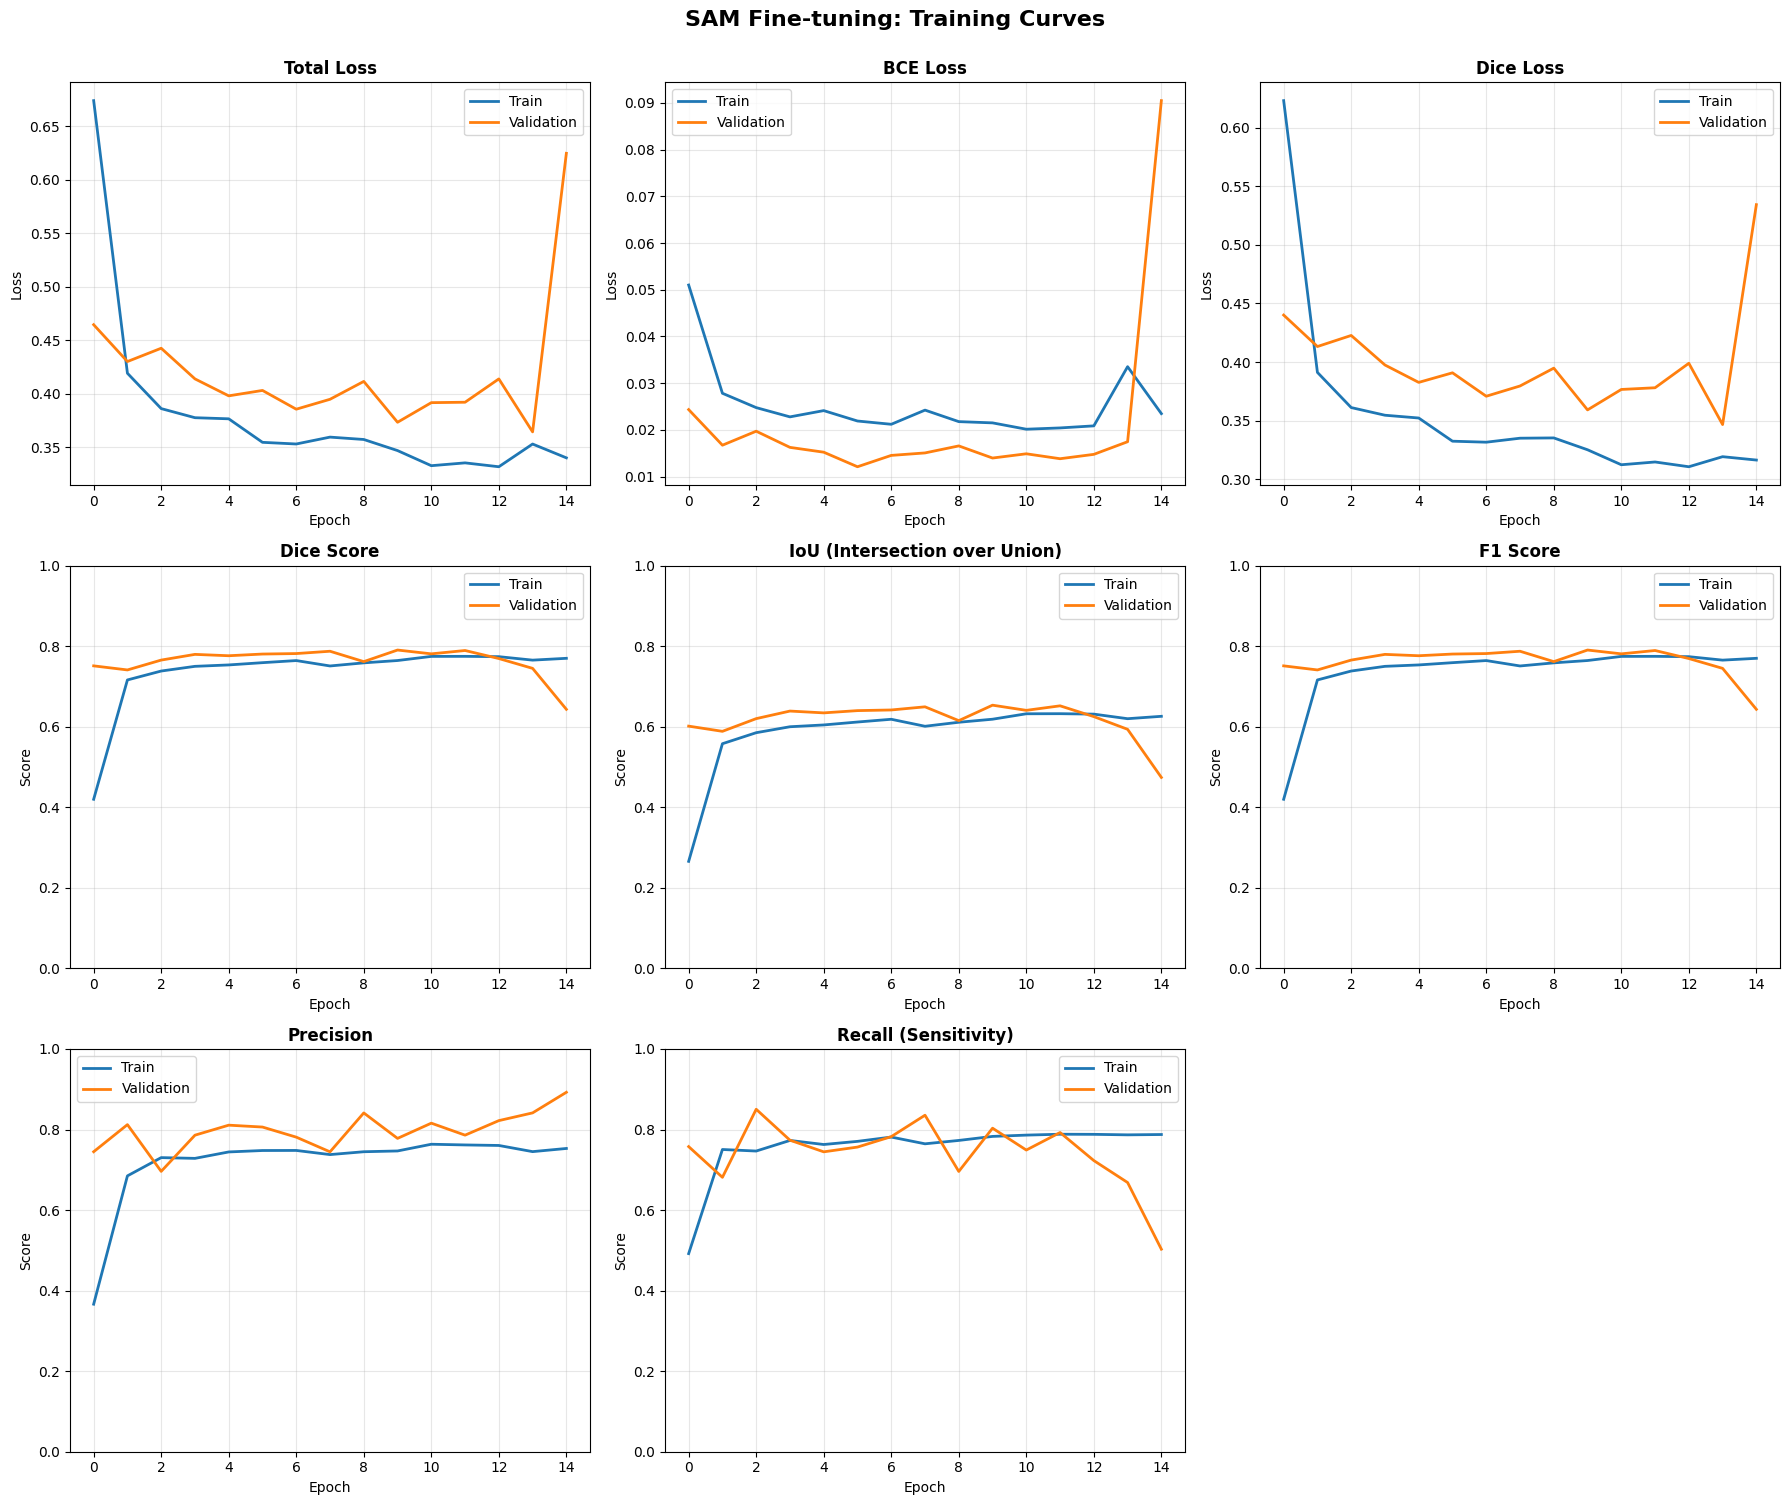

In [ ]:
plot_all_metrics(history)

Loaded best model from epoch 10
Best Validation Dice: 0.7905
Applied LoRA (rank=8) to 12 transformer blocks
Trainable parameters: 4,353,252 (4.63%)
  - LoRA parameters:  294,912
  - Decoder parameters: 4,058,340


Testing: 100%|██████████| 10/10 [00:11<00:00,  1.15s/it]


TILE-LEVEL TEST RESULTS
Loss:          0.3081
  - BCE Loss:  0.0092
  - Dice Loss: 0.2988

Segmentation Metrics:
  Dice:        0.7770
  IoU:         0.6354
  Precision:   0.7403
  Recall:      0.8176
  F1:          0.7770
Visualizing 6 random samples...



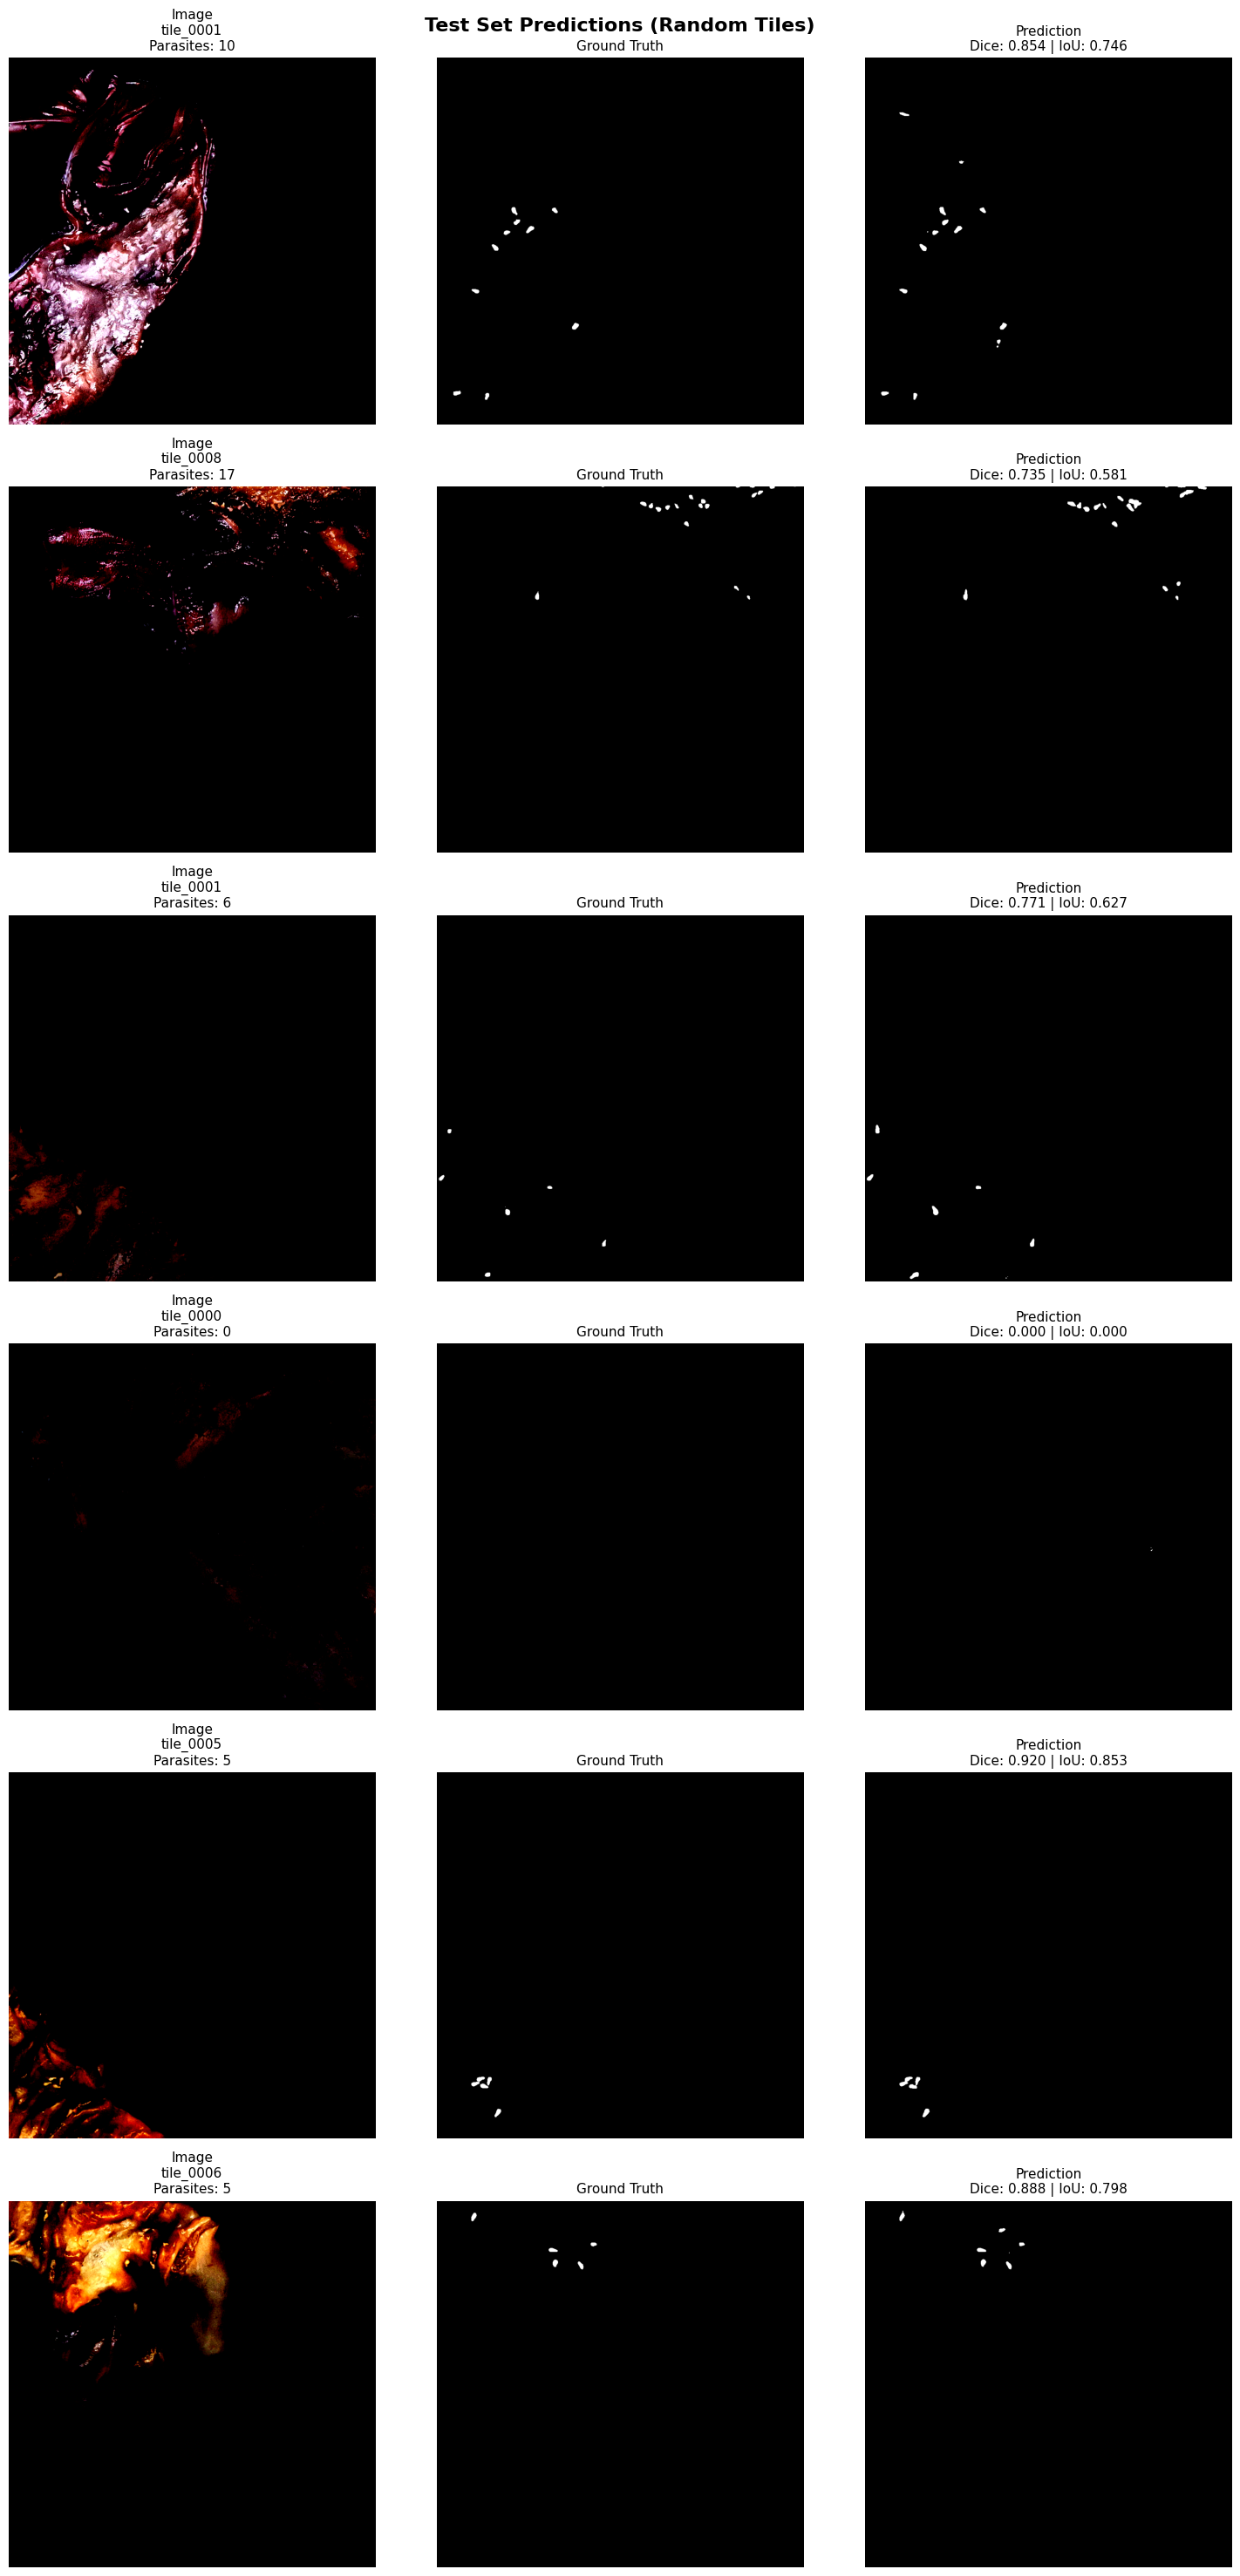

In [ ]:
# Load best checkpoint
best_checkpoint_path = f"{checkpoint_dir}/sam_best.pth"
checkpoint = torch.load(best_checkpoint_path, map_location=device)

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Validation Dice: {checkpoint['best_dice']:.4f}")

sam_model, device = load_sam_model()

# Create fine_tuner with same config as training
eval_fine_tuner = SAMFineTuner_LoRA(
    sam_model=sam_model,
    device=device,
    lora_rank=8,
    learning_rate=1e-4,
    bce_weight=1.0,
    dice_weight=1.0
)

# Load the trained weights
eval_fine_tuner.sam.load_state_dict(checkpoint['model_state_dict'])
eval_fine_tuner.sam.eval()

test_results = evaluate_on_test(
    fine_tuner=eval_fine_tuner,
    test_dataset=test_dataset,
    batch_size=4,
    visualize=True,         # Show some example predictions
    num_viz_samples=6       # Number of tiles to visualize
)


FULL IMAGE RECONSTRUCTION WITH VISUALIZATION
Testing on 6 images: ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']

Processing: B2025-00231b...
  Reconstructing: 4634 x 2805 (~148.8MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7178 | IoU: 0.5598 | Precision: 0.7811 | Recall: 0.6640

Processing: B2025-00143b...
  Reconstructing: 3707 x 3687 (~156.4MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.6629 | IoU: 0.4958 | Precision: 0.8402 | Recall: 0.5474

Processing: B2025-00206b...
  Reconstructing: 3660 x 3072 (~128.7MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.7014 | IoU: 0.5401 | Precision: 0.8156 | Recall: 0.6152

Processing: B2025-00136b...
  Reconstructing: 4025 x 3433 (~158.1MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7765 | IoU: 0.6346 | Precision: 0.9047 | Recall: 0.6801

Processing: B2025-00085.2...
  Reconstructing: 3207 x 3581 (~131.4MB, 9 tiles)
  Successfully processed 9/9 tiles
 

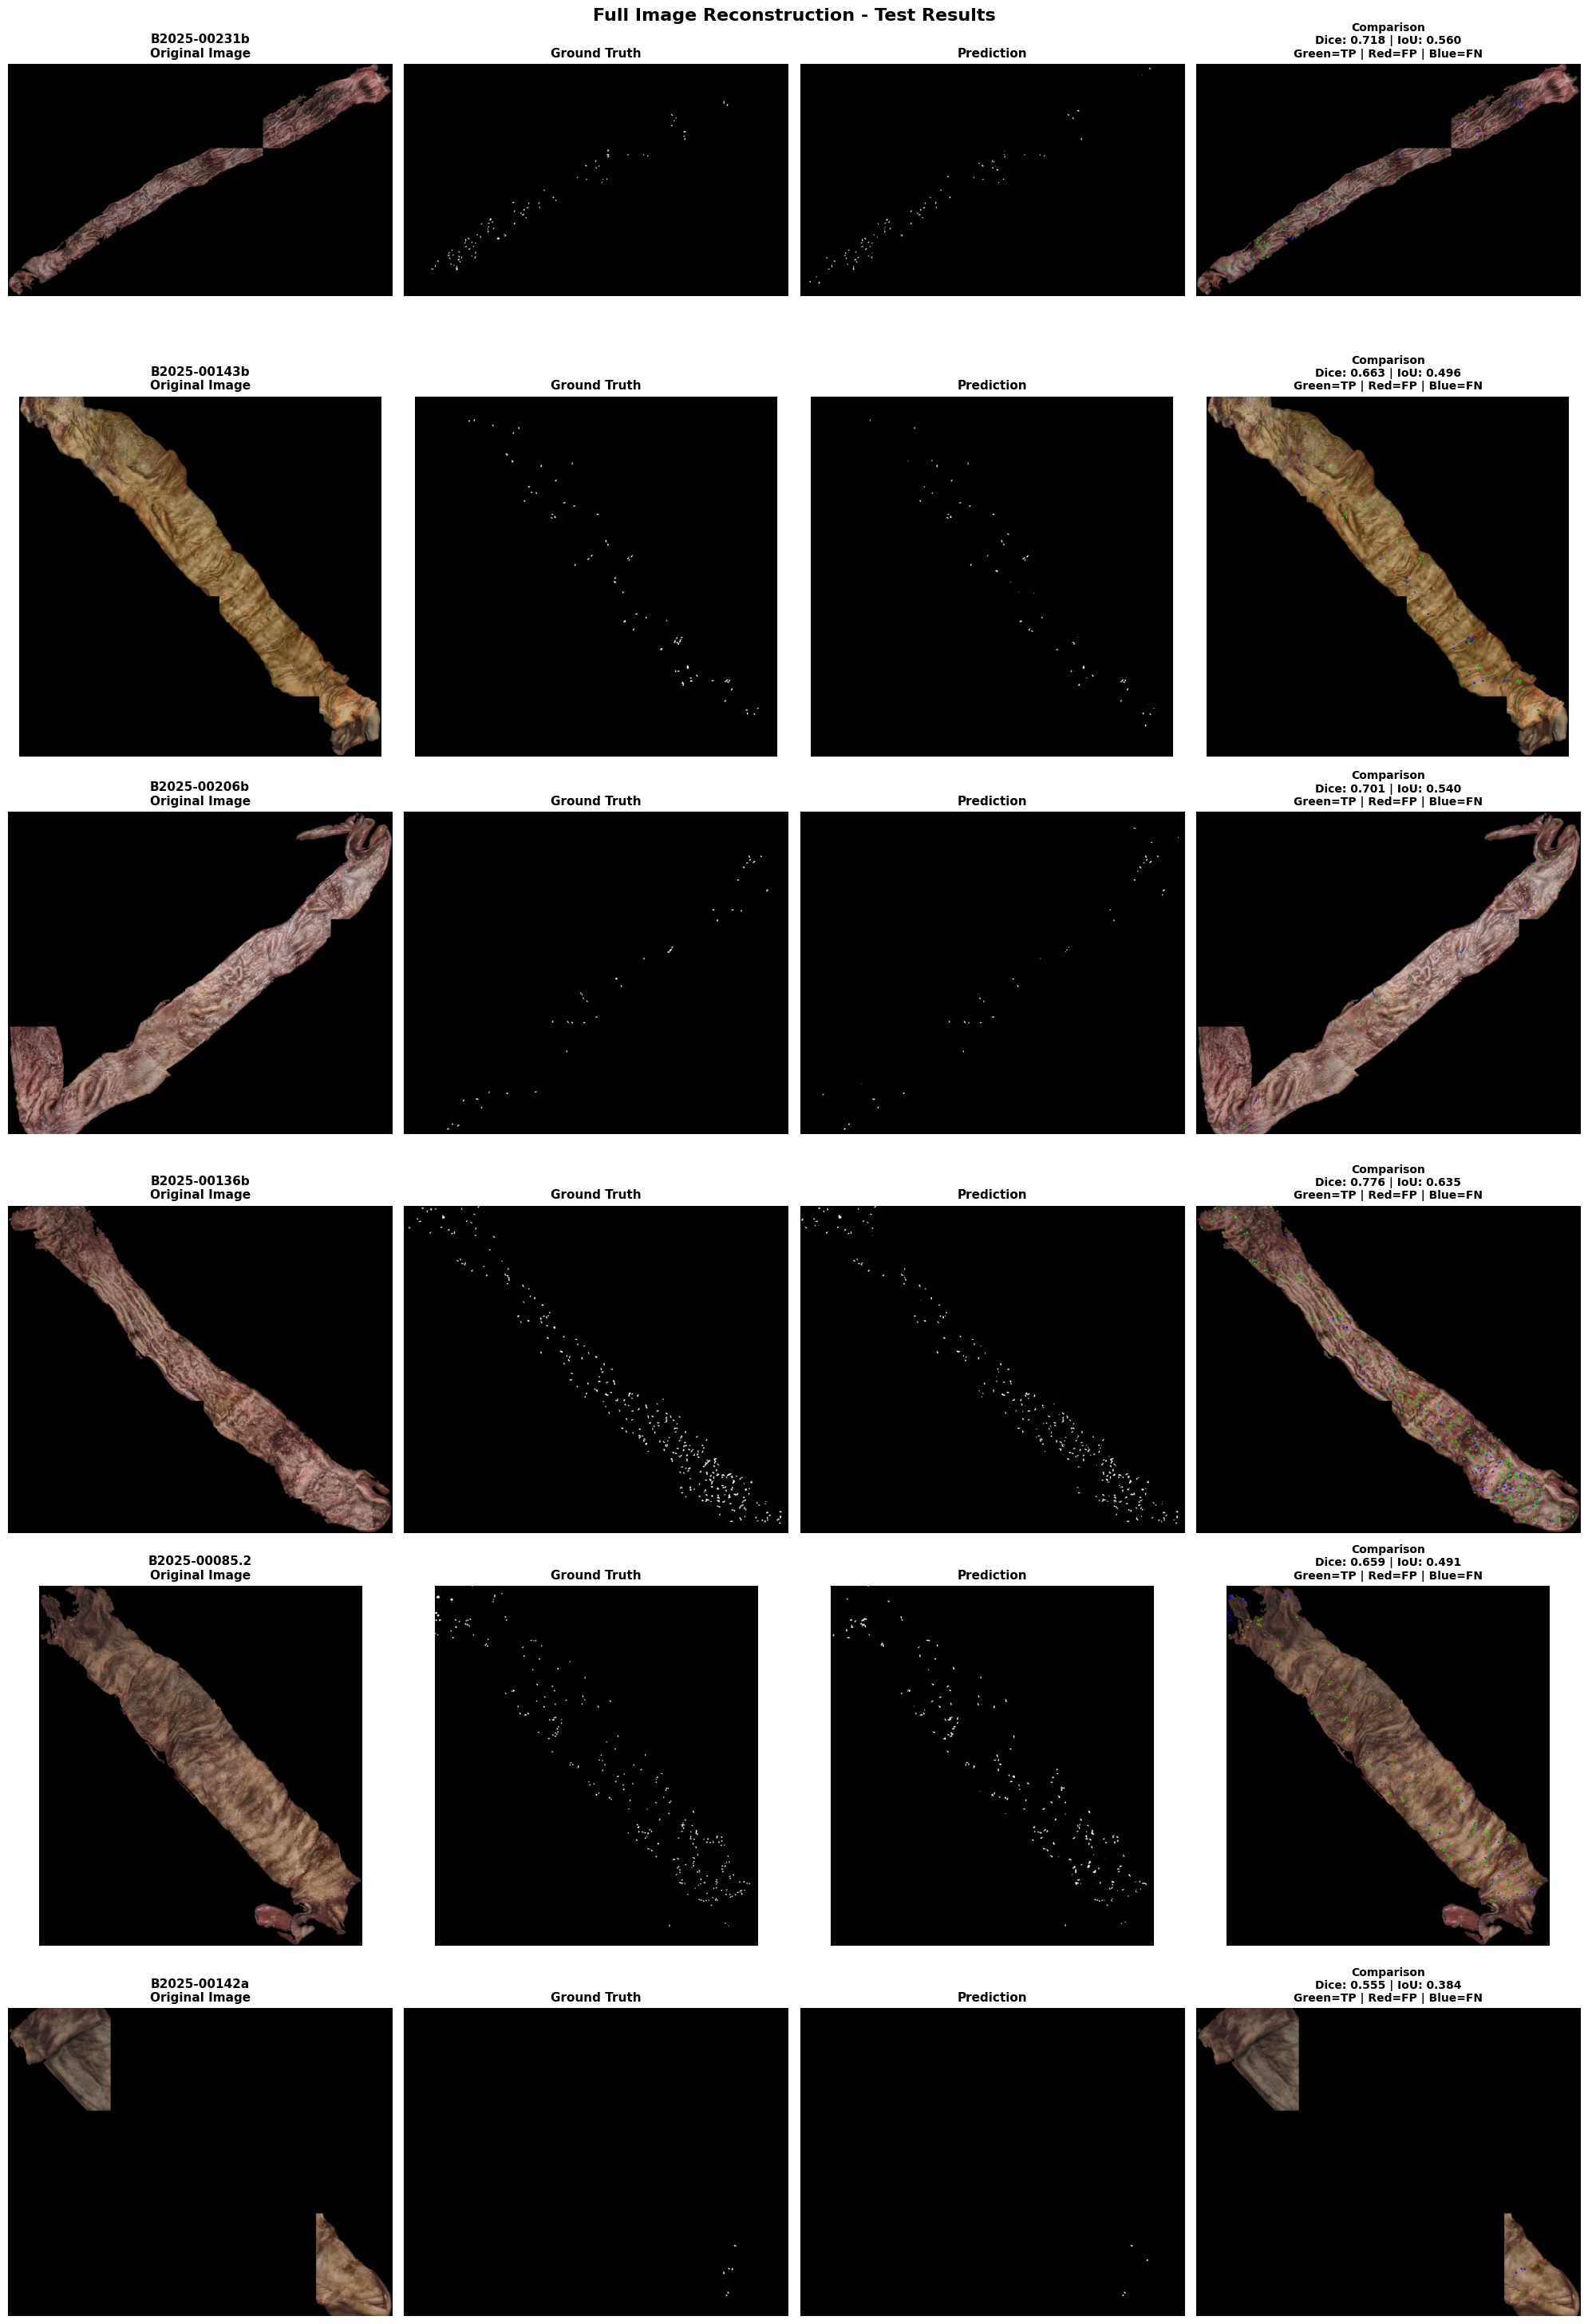

In [ ]:

results_df, visualizations = evaluate_full_images(
    fine_tuner=eval_fine_tuner,
    splits=splits,
    test_dataset=test_dataset,
    max_image_size_mb=300,                  # Skip images larger than 300MB
    process_in_chunks=True,                 # Process tiles in chunks
    chunk_size=30,                          # Clear cache every 30 tiles
)

## Experiment 2 - recall, lora 32, adamw

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

class SAMDatasetNoPrompt(Dataset):
    """Dataset for SAM fine-tuning WITHOUT prompts with Albumentations support"""

    def __init__(self, image_ids, output_dir, augment=False, transform=None):
        """
        Args:
            image_ids: List of image IDs
            output_dir: Directory containing processed tiles
            augment: Whether to use augmentation (for backward compatibility)
            transform: Albumentations transform pipeline (overrides augment if provided)
        """
        self.samples = []
        self.augment = augment
        self.transform = transform  # Albumentations transform

        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            masks_dir = os.path.join(output_dir, img_id, "masks")
            annotations_dir = os.path.join(output_dir, img_id, "annotations")

            if not os.path.exists(tiles_dir):
                continue

            tile_files = [f for f in os.listdir(tiles_dir) if f.endswith('.png')]

            for tile_file in tile_files:
                tile_id = tile_file.replace('.png', '')
                tile_path = os.path.join(tiles_dir, tile_file)
                mask_path = os.path.join(masks_dir, f"{tile_id}.png")
                anno_path = os.path.join(annotations_dir, f"{tile_id}.json")

                if os.path.exists(mask_path) and os.path.exists(anno_path):
                    with open(anno_path, 'r') as f:
                        anno = json.load(f)

                    self.samples.append({
                        'tile_path': tile_path,
                        'mask_path': mask_path,
                        'tile_id': tile_id,
                        'base_image_id': img_id,
                        'num_parasites': anno['num_parasites']
                    })

        aug_type = "Albumentations" if self.transform else ("Basic" if self.augment else "None")
        print(f"Loaded {len(self.samples)} samples (augmentation={aug_type})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load image and mask
        image = cv2.imread(sample['tile_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE)

        # Binary mask (0 or 1)
        binary_mask = (mask > 127).astype(np.uint8)

        # Apply Albumentations transform if provided
        if self.transform is not None:
            transformed = self.transform(image=image, mask=binary_mask)
            image = transformed['image']
            mask_tensor = transformed['mask']

            # Normalize image to [0, 1] for SAM
            image_tensor = image.float() / 255.0

            # Ensure mask is float and has correct shape [1, H, W]
            if mask_tensor.dim() == 2:
                mask_tensor = mask_tensor.unsqueeze(0)
            mask_tensor = mask_tensor.float()

        # Fallback to basic augmentation (for backward compatibility)
        elif self.augment:
            if random.random() > 0.5:
                image = cv2.flip(image, 1).copy()
                binary_mask = cv2.flip(binary_mask, 1).copy()
            if random.random() > 0.5:
                image = cv2.flip(image, 0).copy()
                binary_mask = cv2.flip(binary_mask, 0).copy()
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                image = np.rot90(image, k).copy()
                binary_mask = np.rot90(binary_mask, k).copy()

            # Convert to tensors
            image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        # No augmentation
        else:
            image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'tile_id': sample['tile_id'],
            'num_parasites': sample['num_parasites']
        }

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2


train_transforms = A.Compose([
    # Geometric augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.25),
    A.Rotate(limit=5, p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.25,
        rotate_limit=0,
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        mask_value=0
    ),
    A.Affine(
        shear=(-2, 2),
        p=0.3,
        mode=cv2.BORDER_CONSTANT,
        cval=0,
        cval_mask=0
    ),

    # Color augmentations
    A.HueSaturationValue(
        hue_shift_limit=int(0.015 * 180),
        sat_shift_limit=int(0.7 * 255),
        val_shift_limit=int(0.4 * 255),
        p=0.9
    ),

    # Additional augmentations
    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.1),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    # Convert to tensor (image will be normalized to [0,1] in __getitem__)
    ToTensorV2(),
])

# Validation: No augmentation, just convert to tensor
val_transforms = A.Compose([
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1757925039.py:10: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/tmp/ipython-input-1757925039.py:19: UserWarning: Argument(s) 'mode, cval, cval_mask' are not valid for transform Affine
  A.Affine(


In [ ]:
# Create datasets
train_dataset = SAMDatasetNoPrompt(
    image_ids=splits['train'],
    output_dir=output_dir,
    transform=train_transforms
)

val_dataset = SAMDatasetNoPrompt(
    image_ids=splits['val'],
    output_dir=output_dir,
    transform=val_transforms
)

test_dataset = SAMDatasetNoPrompt(
    image_ids=splits['test'],
    output_dir=output_dir,
    transform=val_transforms
)


Loaded 239 samples (augmentation=Albumentations)
Loaded 34 samples (augmentation=Albumentations)
Loaded 39 samples (augmentation=Albumentations)


The `SAMFineTuner_LoRA` class implements parameter-efficient fine-tuning using Low-Rank Adaptation. It injects trainable LoRA adapters into the image encoder's attention layers while keeping base weights frozen, and fully trains the mask decoder. The loss function combines BCE and Dice, with optional positive class weighting (`pos_weight > 1.0`) to penalize false negatives and improve detection recall.

In [ ]:
class SAMFineTuner_LoRA:
    """
    Fine-tuner for Segment Anything Model (SAM) using Low-Rank Adaptation (LoRA).

    LoRA enables parameter-efficient fine-tuning by injecting trainable low-rank
    matrices into the attention layers while keeping the base model frozen.

    Training strategy:
        - Image encoder: Frozen except for LoRA adapters on QKV projections
        - Prompt encoder: Fully frozen (no prompts used)
        - Mask decoder: Fully trainable

    Loss function:
        - BCE Loss: Pixel-level classification with optional positive class weighting
        - Dice Loss: Region-level overlap optimization
    """

    def __init__(self, sam_model, device, learning_rate=1e-4, lora_rank=8,
                optimizer_type='adam', weight_decay=1e-4,
                bce_weight=1.0, dice_weight=1.0, grad_clip=None,
                pos_weight=1.0):
        """
        Initialize SAM fine-tuner with LoRA configuration.

        Args:
            sam_model: Pretrained SAM model instance
            device: Target device ('cuda' or 'cpu')
            learning_rate: Learning rate for optimizer (default: 1e-4)
            lora_rank: Rank of LoRA decomposition matrices (default: 8)
            optimizer_type: Optimizer choice - 'adam', 'adamw', or 'sgd'
            weight_decay: L2 regularization strength (default: 1e-4)
            bce_weight: Weight for BCE loss component (default: 1.0)
            dice_weight: Weight for Dice loss component (default: 1.0)
            grad_clip: Maximum gradient norm for clipping (default: None)
            pos_weight: Positive class weight for BCE (default: 1.0)
                        Values > 1.0 penalize false negatives more heavily,
                        which improves recall for sparse targets
        """
        self.sam = sam_model
        self.device = device
        self.lora_rank = lora_rank
        self.grad_clip = grad_clip
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.pos_weight = pos_weight

        # Inject LoRA adapters into image encoder attention layers
        self._apply_lora_to_image_encoder()

        # Freeze base image encoder, keep only LoRA parameters trainable
        for name, param in self.sam.image_encoder.named_parameters():
            if 'lora' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        # Freeze prompt encoder entirely (not used in prompt-free mode)
        for param in self.sam.prompt_encoder.parameters():
            param.requires_grad = False

        # Train mask decoder fully
        for param in self.sam.mask_decoder.parameters():
            param.requires_grad = True

        # Collect trainable parameters: LoRA adapters + mask decoder
        lora_params = [p for n, p in self.sam.image_encoder.named_parameters()
                      if 'lora' in n and p.requires_grad]
        decoder_params = list(self.sam.mask_decoder.parameters())
        trainable_params = lora_params + decoder_params

        # Initialize optimizer based on specified type
        if optimizer_type.lower() == 'adam':
            self.optimizer = torch.optim.Adam(
                trainable_params,
                lr=learning_rate
            )
        elif optimizer_type.lower() == 'adamw':
            self.optimizer = torch.optim.AdamW(
                trainable_params,
                lr=learning_rate,
                weight_decay=weight_decay
            )
        elif optimizer_type.lower() == 'sgd':
            self.optimizer = torch.optim.SGD(
                trainable_params,
                lr=learning_rate,
                momentum=0.9,
                weight_decay=weight_decay
            )
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_type}")

        # Configure BCE loss with optional positive class weighting
        # Higher pos_weight helps with class imbalance (sparse parasites)
        if pos_weight > 1.0:
            self.bce_loss = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor([pos_weight]).to(device)
            )
            print(f"Using pos_weight={pos_weight} (prioritizing detection recall)")
        else:
            self.bce_loss = nn.BCEWithLogitsLoss()

        self.dice_loss = self.dice_loss_fn

        # Log parameter counts for verification
        total_params = sum(p.numel() for p in self.sam.parameters())
        trainable_params_count = sum(p.numel() for p in self.sam.parameters() if p.requires_grad)
        lora_params_count = sum(p.numel() for p in lora_params)

        print(f"Trainable parameters:    {trainable_params_count:,} ({100*trainable_params_count/total_params:.2f}%)")
        print(f"  - LoRA parameters:     {lora_params_count:,}")
        print(f"  - Decoder parameters:  {trainable_params_count - lora_params_count:,}")


    def _apply_lora_to_image_encoder(self):
        """
        Apply LoRA adapters to QKV projection layers in each transformer block.

        For each attention layer, the original linear projection is replaced with
        a LoRA-augmented version that adds a low-rank update: W' = W + BA
        where B and A are the trainable low-rank matrices.
        """
        for block_idx, block in enumerate(self.sam.image_encoder.blocks):
            attn = block.attn
            original_qkv = attn.qkv
            in_features = original_qkv.in_features
            out_features = original_qkv.out_features

            # Preserve original pretrained weights
            original_weight = original_qkv.weight.data.clone()
            original_bias = original_qkv.bias.data.clone() if original_qkv.bias is not None else None

            # Create LoRA-augmented linear layer
            # lora_alpha controls the scaling of the low-rank update
            lora_qkv = lora.Linear(
                in_features,
                out_features,
                r=self.lora_rank,
                lora_alpha=self.lora_rank * 2,
                lora_dropout=0.1,
                merge_weights=False,
                bias=original_qkv.bias is not None
            )

            # Copy pretrained weights to new layer (LoRA matrices initialized separately)
            with torch.no_grad():
                lora_qkv.weight.copy_(original_weight)
                if original_bias is not None:
                    lora_qkv.bias.copy_(original_bias)

            # Replace original layer with LoRA version
            attn.qkv = lora_qkv.to(self.device)

        print(f"Applied LoRA (rank={self.lora_rank}) to {len(self.sam.image_encoder.blocks)} transformer blocks")


    def dice_loss_fn(self, pred, target, smooth=1e-5):
        """
        Compute Dice loss for segmentation.

        Dice loss directly optimizes the Dice coefficient, which measures
        overlap between prediction and ground truth.

        Args:
            pred: Predicted logits (B, 1, H, W)
            target: Ground truth binary masks (B, 1, H, W)
            smooth: Smoothing term to avoid division by zero

        Returns:
            Scalar Dice loss (1 - Dice coefficient)
        """
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice.mean()

    def compute_metrics(self, pred, target, threshold=0.5):
        """
        Compute confusion matrix components for metric accumulation.

        Returns raw counts (TP, FP, FN, TN) rather than final metrics
        to enable proper aggregation across batches.

        Args:
            pred: Predicted logits
            target: Ground truth masks
            threshold: Binarization threshold for predictions

        Returns:
            Dictionary with tp, fp, fn, tn counts
        """
        pred_binary = (torch.sigmoid(pred) > threshold).float()
        target_binary = target.float()

        pred_flat = pred_binary.view(-1)
        target_flat = target_binary.view(-1)

        tp = (pred_flat * target_flat).sum()
        fp = (pred_flat * (1 - target_flat)).sum()
        fn = ((1 - pred_flat) * target_flat).sum()
        tn = ((1 - pred_flat) * (1 - target_flat)).sum()

        return {
            'tp': tp.item(),
            'fp': fp.item(),
            'fn': fn.item(),
            'tn': tn.item()
        }

    @staticmethod
    def compute_final_metrics(total_tp, total_fp, total_fn, total_tn):
        """
        Compute final evaluation metrics from accumulated confusion matrix counts.

        Args:
            total_tp: Total true positives across all batches
            total_fp: Total false positives
            total_fn: Total false negatives
            total_tn: Total true negatives

        Returns:
            Dictionary with IoU, Dice, precision, recall, and F1 scores
        """
        smooth = 1e-7
        iou = (total_tp + smooth) / (total_tp + total_fp + total_fn + smooth)
        dice = (2 * total_tp + smooth) / (2 * total_tp + total_fp + total_fn + smooth)
        precision = (total_tp + smooth) / (total_tp + total_fp + smooth)
        recall = (total_tp + smooth) / (total_tp + total_fn + smooth)
        f1 = (2 * precision * recall) / (precision + recall + smooth)

        return {
            'iou': iou,
            'dice': dice,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    def train_step(self, batch):
        """
        Execute single training step with forward pass, loss computation, and weight update.

        Args:
            batch: Dictionary containing 'image' and 'mask' tensors

        Returns:
            Dictionary with loss values and metric components
        """
        self.sam.train()
        self.optimizer.zero_grad()

        # Move data to device
        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Forward pass through image encoder (LoRA adapters active)
        image_embeddings = self.sam.image_encoder(images)

        # Get empty prompt embeddings (prompt-free mode)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        # Generate mask predictions
        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        # Upsample to original resolution for loss computation
        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Compute combined loss with configurable weights
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        # Backward pass
        loss.backward()

        # Optional gradient clipping for training stability
        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.sam.parameters() if p.requires_grad],
                max_norm=self.grad_clip
            )

        # Update weights
        self.optimizer.step()

        # Compute metrics without gradient tracking
        with torch.no_grad():
            metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    @torch.no_grad()
    def val_step(self, batch):
        """
        Execute validation step (inference only, no gradient computation).

        Args:
            batch: Dictionary containing 'image' and 'mask' tensors

        Returns:
            Dictionary with loss values and metric components
        """
        self.sam.eval()

        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Forward pass (same as training but without gradients)
        image_embeddings = self.sam.image_encoder(images)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Compute losses and metrics
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    def save_checkpoint(self, path):
        """
        Save model checkpoint with LoRA weights, decoder state, and optimizer.

        Only saves the trainable components (not the frozen base model),
        keeping checkpoint files compact.

        Args:
            path: File path for checkpoint
        """
        torch.save({
            'mask_decoder': self.sam.mask_decoder.state_dict(),
            'lora_state': {n: p.data for n, p in self.sam.image_encoder.named_parameters() if 'lora' in n},
            'optimizer': self.optimizer.state_dict()
        }, path)
        print(f"Checkpoint saved to {path}")

    def load_checkpoint(self, path, load_optimizer=True):
        """
        Load model checkpoint and restore LoRA weights and decoder state.

        Args:
            path: Path to checkpoint file
            load_optimizer: Whether to restore optimizer state (for resuming training)
        """
        checkpoint = torch.load(path, map_location=self.device)
        self.sam.mask_decoder.load_state_dict(checkpoint['mask_decoder'])

        # Restore LoRA adapter weights
        if 'lora_state' in checkpoint:
            for name, param in self.sam.image_encoder.named_parameters():
                if name in checkpoint['lora_state']:
                    param.data.copy_(checkpoint['lora_state'][name])

        # Optionally restore optimizer state for training continuation
        if load_optimizer and 'optimizer' in checkpoint:
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            print("Optimizer state loaded")

        print(f"Checkpoint loaded from {path}")

The `train_sam_lora` function runs the complete training pipeline with validation, metric logging, learning rate scheduling, and checkpoint saving to Google Drive. The best model is selected based on validation recall.

In [ ]:
def train_sam_lora(sam_model, train_dataset, val_dataset, config, save_to_drive=True):
    """
    Main training loop for SAM fine-tuning with LoRA.

    Handles the complete training pipeline including:
        - DataLoader setup
        - LoRA fine-tuner initialization
        - Learning rate scheduling
        - Metric tracking and logging
        - Checkpoint saving (best, periodic, final)
        - Early stopping based on validation recall

    Args:
        sam_model: Pretrained SAM model to fine-tune
        train_dataset: Training dataset (SAMDatasetNoPrompt instance)
        val_dataset: Validation dataset
        config: Dictionary containing training hyperparameters:
            - exp_name: Experiment name for checkpoint directory
            - batch_size: Batch size for training
            - num_epochs: Maximum number of training epochs
            - learning_rate: Initial learning rate
            - lora_rank: Rank for LoRA adapters (default: 8)
            - optimizer: 'adam', 'adamw', or 'sgd' (default: 'adam')
            - weight_decay: L2 regularization (default: 1e-4)
            - bce_weight: Weight for BCE loss (default: 1.0)
            - dice_weight: Weight for Dice loss (default: 1.0)
            - pos_weight: Positive class weight for BCE (default: 1.0)
            - grad_clip: Max gradient norm (default: None)
            - scheduler: 'cosine', 'plateau', 'step', or None
            - early_stop_patience: Epochs without improvement before stopping
        save_to_drive: If True, save checkpoints to Google Drive

    Returns:
        history: Dictionary containing training/validation metrics per epoch
        fine_tuner: Trained SAMFineTuner_LoRA instance
        checkpoint_dir: Path to saved checkpoints
    """
    # Extract configuration parameters
    exp_name = config['exp_name']
    batch_size = config['batch_size']
    num_epochs = config['num_epochs']
    learning_rate = config['learning_rate']
    lora_rank = config.get('lora_rank', 8)
    optimizer_type = config.get('optimizer', 'adam')
    weight_decay = config.get('weight_decay', 1e-4)
    bce_weight = config.get('bce_weight', 1.0)
    dice_weight = config.get('dice_weight', 1.0)
    pos_weight = config.get('pos_weight', 1.0)
    grad_clip = config.get('grad_clip', None)
    scheduler_type = config.get('scheduler', None)
    early_stop_patience = config.get('early_stop_patience', None)

    # Setup checkpoint directory (Google Drive for persistence across Colab sessions)
    if save_to_drive:
        checkpoint_dir = f"/content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/{exp_name}"
    else:
        checkpoint_dir = f"sam_checkpoints/{exp_name}"
    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"Checkpoints will be saved to: {checkpoint_dir}")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam_model.to(device)

    # Initialize LoRA fine-tuner
    fine_tuner = SAMFineTuner_LoRA(
        sam_model,
        device,
        learning_rate=learning_rate,
        lora_rank=lora_rank,
        optimizer_type=optimizer_type,
        weight_decay=weight_decay,
        bce_weight=bce_weight,
        dice_weight=dice_weight,
        grad_clip=grad_clip,
        pos_weight=pos_weight,
    )

    # Setup learning rate scheduler if specified
    scheduler = None
    if scheduler_type == 'cosine':
        # Smooth decay to minimum LR over training duration
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            fine_tuner.optimizer, T_max=num_epochs, eta_min=1e-6
        )
        print("Using CosineAnnealingLR scheduler")
    elif scheduler_type == 'plateau':
        # Reduce LR when validation loss plateaus
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            fine_tuner.optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        print("Using ReduceLROnPlateau scheduler")
    elif scheduler_type == 'step':
        # Fixed LR decay every N epochs
        scheduler = torch.optim.lr_scheduler.StepLR(
            fine_tuner.optimizer, step_size=10, gamma=0.5
        )
        print("Using StepLR scheduler")

    # Initialize training history for all tracked metrics
    history = {
        'train_loss': [], 'train_loss_bce': [], 'train_loss_dice': [],
        'train_iou': [], 'train_dice': [], 'train_precision': [],
        'train_recall': [], 'train_f1': [],
        'val_loss': [], 'val_loss_bce': [], 'val_loss_dice': [],
        'val_iou': [], 'val_dice': [], 'val_precision': [],
        'val_recall': [], 'val_f1': []
    }

    # Track best model based on validation recall (prioritize detection sensitivity)
    best_val_recall = 0.0
    best_epoch = 0
    patience_counter = 0

    # Main training loop
    for epoch in range(num_epochs):

        # ==================== TRAINING PHASE ====================
        train_losses = []
        train_losses_bce = []
        train_losses_dice = []
        train_tp = train_fp = train_fn = train_tn = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in pbar:
            step_results = fine_tuner.train_step(batch)

            # Accumulate losses
            train_losses.append(step_results['loss'])
            train_losses_bce.append(step_results['loss_bce'])
            train_losses_dice.append(step_results['loss_dice'])

            # Accumulate confusion matrix components
            train_tp += step_results['tp']
            train_fp += step_results['fp']
            train_fn += step_results['fn']
            train_tn += step_results['tn']

            # Compute running metrics for progress bar
            running_metrics = fine_tuner.compute_final_metrics(
                train_tp, train_fp, train_fn, train_tn
            )
            pbar.set_postfix({
                "loss": f"{step_results['loss']:.4f}",
                "dice": f"{running_metrics['dice']:.4f}",
                "iou": f"{running_metrics['iou']:.4f}",
            })

        # ==================== VALIDATION PHASE ====================
        val_losses = []
        val_losses_bce = []
        val_losses_dice = []
        val_tp = val_fp = val_fn = val_tn = 0

        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
            step_results = fine_tuner.val_step(batch)

            val_losses.append(step_results['loss'])
            val_losses_bce.append(step_results['loss_bce'])
            val_losses_dice.append(step_results['loss_dice'])

            val_tp += step_results['tp']
            val_fp += step_results['fp']
            val_fn += step_results['fn']
            val_tn += step_results['tn']

        # Compute final epoch metrics from accumulated counts
        train_metrics = fine_tuner.compute_final_metrics(train_tp, train_fp, train_fn, train_tn)
        val_metrics = fine_tuner.compute_final_metrics(val_tp, val_fp, val_fn, val_tn)

        # Record metrics to history
        history['train_loss'].append(np.mean(train_losses))
        history['train_loss_bce'].append(np.mean(train_losses_bce))
        history['train_loss_dice'].append(np.mean(train_losses_dice))
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['train_precision'].append(train_metrics['precision'])
        history['train_recall'].append(train_metrics['recall'])
        history['train_f1'].append(train_metrics['f1'])

        history['val_loss'].append(np.mean(val_losses))
        history['val_loss_bce'].append(np.mean(val_losses_bce))
        history['val_loss_dice'].append(np.mean(val_losses_dice))
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])

        # Extract current epoch metrics for logging
        avg_train_loss = history['train_loss'][-1]
        avg_train_dice = history['train_dice'][-1]
        avg_train_iou = history['train_iou'][-1]
        avg_train_precision = history['train_precision'][-1]
        avg_train_recall = history['train_recall'][-1]
        avg_train_f1 = history['train_f1'][-1]

        avg_val_loss = history['val_loss'][-1]
        avg_val_dice = history['val_dice'][-1]
        avg_val_iou = history['val_iou'][-1]
        avg_val_precision = history['val_precision'][-1]
        avg_val_recall = history['val_recall'][-1]
        avg_val_f1 = history['val_f1'][-1]

        # Update learning rate scheduler
        if scheduler is not None:
            if scheduler_type == 'plateau':
                scheduler.step(avg_val_loss)  # Plateau scheduler uses validation loss
            else:
                scheduler.step()

        # Log epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f" Train | Loss: {avg_train_loss:.4f} | Dice: {avg_train_dice:.4f} | IoU: {avg_train_iou:.4f}")
        print(f"       | Precision: {avg_train_precision:.4f} | Recall: {avg_train_recall:.4f} | F1: {avg_train_f1:.4f}")
        print(f" Val   | Loss: {avg_val_loss:.4f} | Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f}")
        print(f"       | Precision: {avg_val_precision:.4f} | Recall: {avg_val_recall:.4f} | F1: {avg_val_f1:.4f}")

        # ==================== CHECKPOINT SAVING ====================
        # Save best model based on validation recall (prioritize detection sensitivity)
        if avg_val_recall > best_val_recall:
            best_val_recall = avg_val_recall
            best_epoch = epoch + 1
            patience_counter = 0

            # Save comprehensive checkpoint with all metadata
            best_checkpoint_path = os.path.join(checkpoint_dir, "sam_best.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_val_recall': best_val_recall,
                'val_metrics': val_metrics,
                'train_metrics': train_metrics,
                'history': history,
                'lora_rank': lora_rank,
                'bce_weight': bce_weight,
                'dice_weight': dice_weight,
                'config': config,
            }, best_checkpoint_path)
            print(f"\nNew best model saved (Recall: {best_val_recall:.4f})")
        else:
            patience_counter += 1

        # Check early stopping condition
        if early_stop_patience is not None and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

        # Save periodic checkpoint every 5 epochs (for training resumption)
        if (epoch + 1) % 5 == 0:
            epoch_checkpoint_path = os.path.join(checkpoint_dir, f"sam_epoch_{epoch+1}.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'val_metrics': val_metrics,
                'train_metrics': train_metrics,
                'lora_rank': lora_rank,
                'config': config,
            }, epoch_checkpoint_path)
            print(f"Checkpoint saved: epoch_{epoch+1}.pth\n")

    # Save final model with complete training history
    final_checkpoint_path = os.path.join(checkpoint_dir, "sam_final.pth")
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': fine_tuner.sam.state_dict(),
        'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
        'final_val_dice': avg_val_dice,
        'best_val_recall': best_val_recall,
        'best_epoch': best_epoch,
        'lora_rank': lora_rank,
        'config': config,
        'history': history,
    }, final_checkpoint_path)

    return history, fine_tuner, checkpoint_dir

In [ ]:
sam_model, device = load_sam_model()


config = {
    'exp_name': '32_augm_recall_all_tiles',
    'batch_size': 1,
    'num_epochs': 30,
    'learning_rate': 1e-4,
    'lora_rank': 32,
    'optimizer': 'adamw',
    'weight_decay': 1e-4,
    'bce_weight': 1.0,
    'dice_weight': 1.0,
    'grad_clip': None,
    'scheduler': None,
    'early_stop_patience': 10
}

# Train
history, fine_tuner, checkpoint_dir = train_sam_lora(sam_model, train_dataset, val_dataset, config)

Checkpoints will be saved to: /content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/32_augm_recall_all_tiles
Applied LoRA (rank=32) to 12 transformer blocks
Trainable parameters:    5,237,988(5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340


Epoch 1/30 [Train]: 100%|██████████| 239/239 [02:24<00:00,  1.65it/s, loss=1.0710, dice=0.4586, iou=0.2975]



Epoch 1/30
 Train | Loss: 0.6260 | Dice: 0.4586 | IoU: 0.2975
       | Precision: 0.3945 | Recall: 0.5475 | F1: 0.4586
 Val   | Loss: 0.4970 | Dice: 0.6545 | IoU: 0.4864
       | Precision: 0.8475 | Recall: 0.5331 | F1: 0.6545

New best model saved (Recall: 0.5331)


Epoch 2/30 [Train]: 100%|██████████| 239/239 [02:25<00:00,  1.65it/s, loss=0.7226, dice=0.6374, iou=0.4678]



Epoch 2/30
 Train | Loss: 0.5083 | Dice: 0.6374 | IoU: 0.4678
       | Precision: 0.6469 | Recall: 0.6282 | F1: 0.6374
 Val   | Loss: 0.4722 | Dice: 0.7255 | IoU: 0.5692
       | Precision: 0.7374 | Recall: 0.7139 | F1: 0.7255

New best model saved (Recall: 0.7139)


...


Epoch 28/30
 Train | Loss: 0.3750 | Dice: 0.7275 | IoU: 0.5717
       | Precision: 0.7338 | Recall: 0.7212 | F1: 0.7275
 Val   | Loss: 0.3626 | Dice: 0.7870 | IoU: 0.6488
       | Precision: 0.7980 | Recall: 0.7763 | F1: 0.7870


Epoch 29/30 [Train]: 100%|██████████| 239/239 [02:25<00:00,  1.64it/s, loss=1.0116, dice=0.7103, iou=0.5507]



Epoch 29/30
 Train | Loss: 0.3850 | Dice: 0.7103 | IoU: 0.5507
       | Precision: 0.7406 | Recall: 0.6824 | F1: 0.7103
 Val   | Loss: 0.3690 | Dice: 0.7903 | IoU: 0.6532
       | Precision: 0.7929 | Recall: 0.7877 | F1: 0.7903


Epoch 30/30 [Train]: 100%|██████████| 239/239 [02:25<00:00,  1.64it/s, loss=0.7343, dice=0.7268, iou=0.5708]



Epoch 30/30
 Train | Loss: 0.3746 | Dice: 0.7268 | IoU: 0.5708
       | Precision: 0.7367 | Recall: 0.7171 | F1: 0.7268
 Val   | Loss: 0.3966 | Dice: 0.7897 | IoU: 0.6525
       | Precision: 0.7908 | Recall: 0.7886 | F1: 0.7897
Checkpoint saved: epoch_30.pth



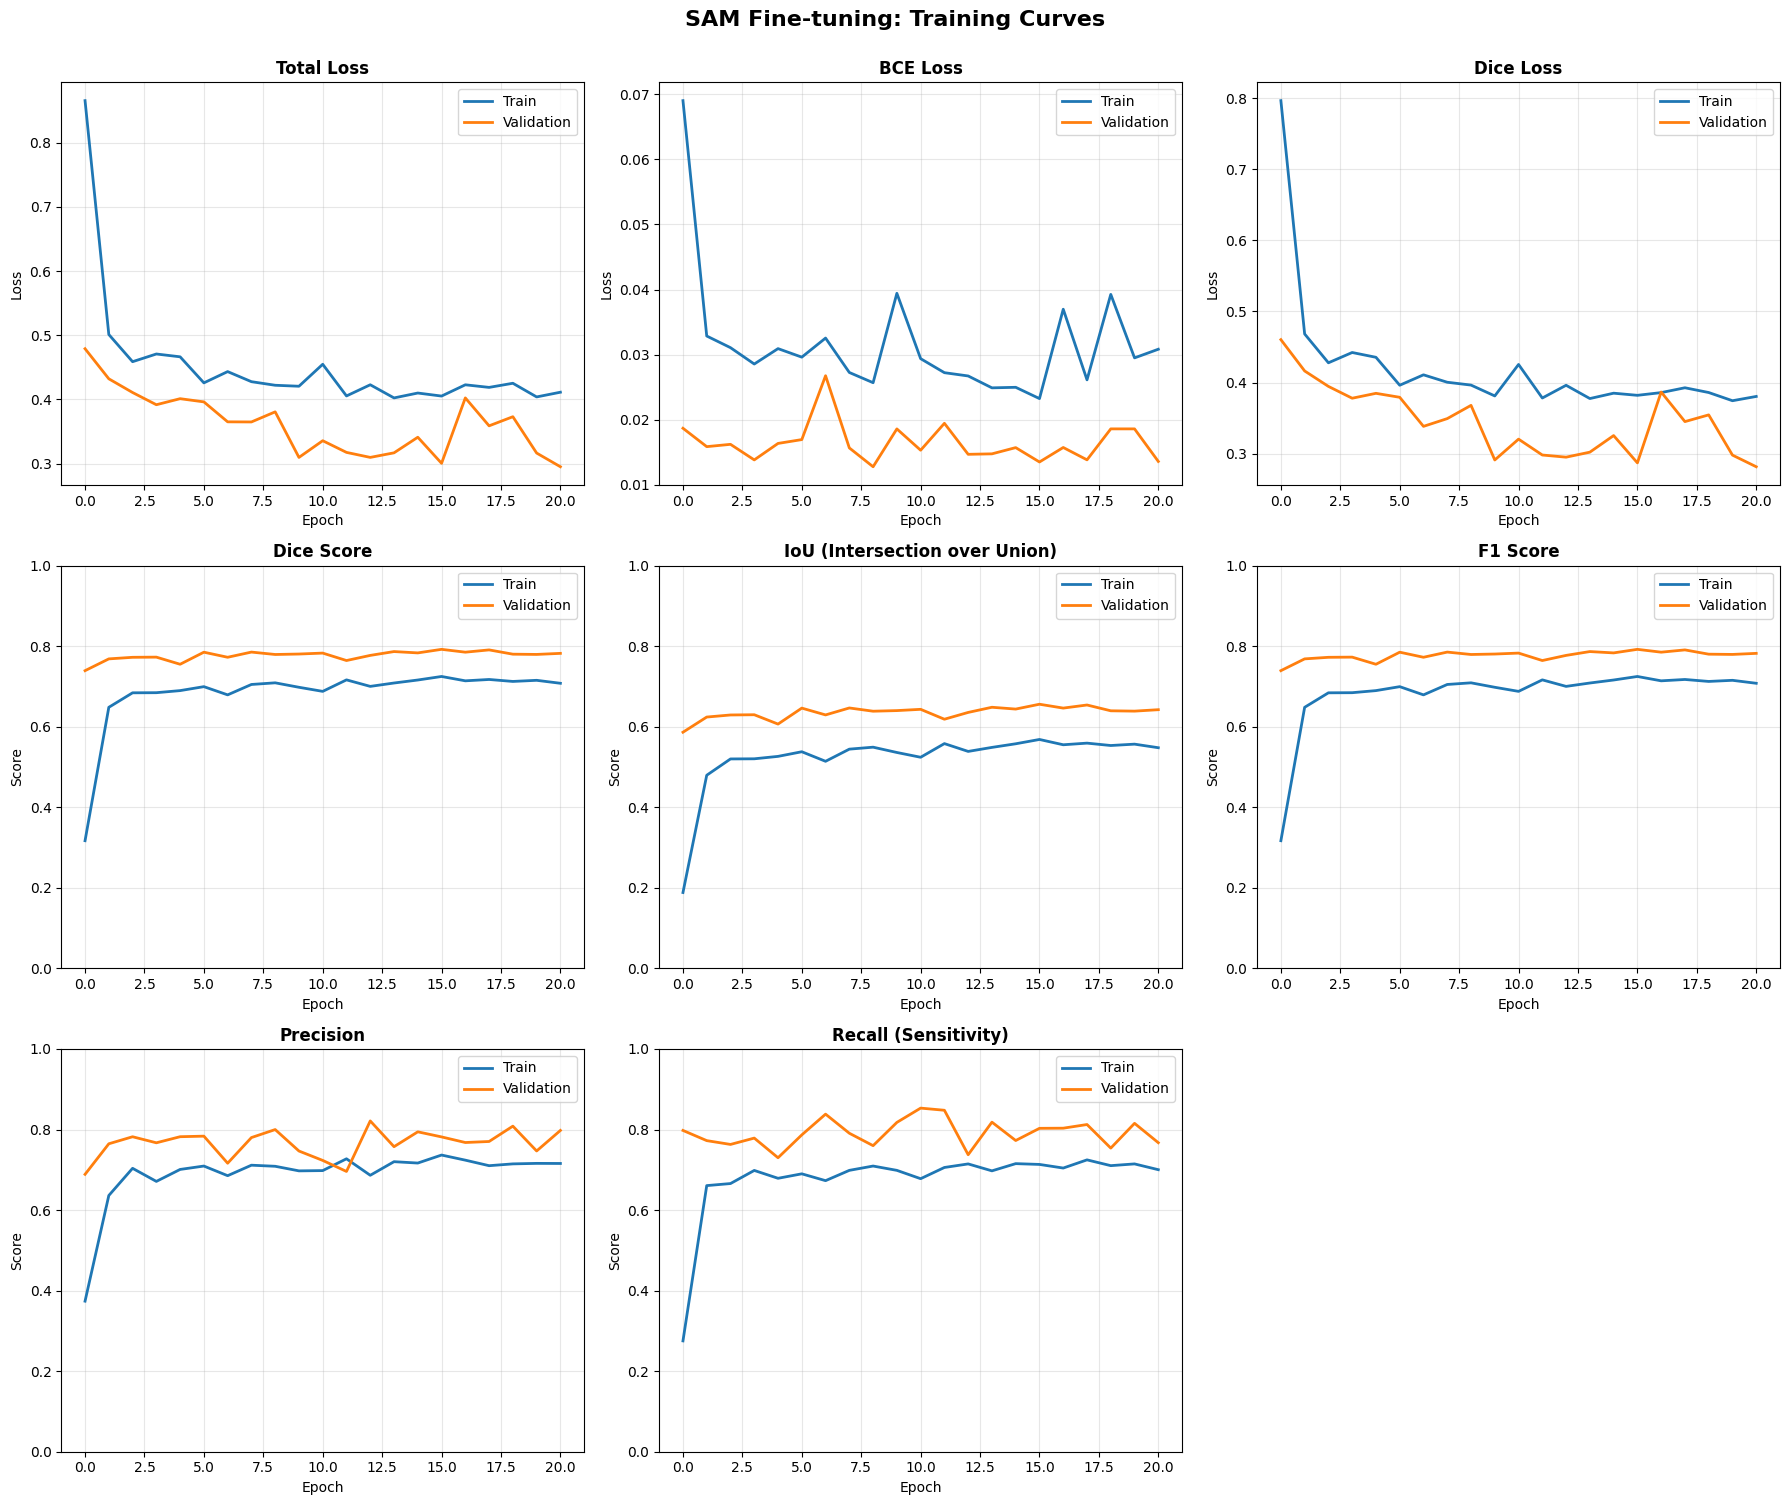

In [ ]:
plot_all_metrics(history)

Loaded best model from epoch 26
Best Validation Recall: 0.8289
Applied LoRA (rank=32) to 12 transformer blocks
Trainable parameters:    5,237,988(5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340


Testing: 100%|██████████| 10/10 [00:11<00:00,  1.12s/it]


TILE-LEVEL TEST RESULTS
Loss:          0.3324
  - BCE Loss:  0.0099
  - Dice Loss: 0.3225

Segmentation Metrics:
  Dice:        0.7647
  IoU:         0.6191
  Precision:   0.7253
  Recall:      0.8087
  F1:          0.7647
Visualizing 6 random samples...



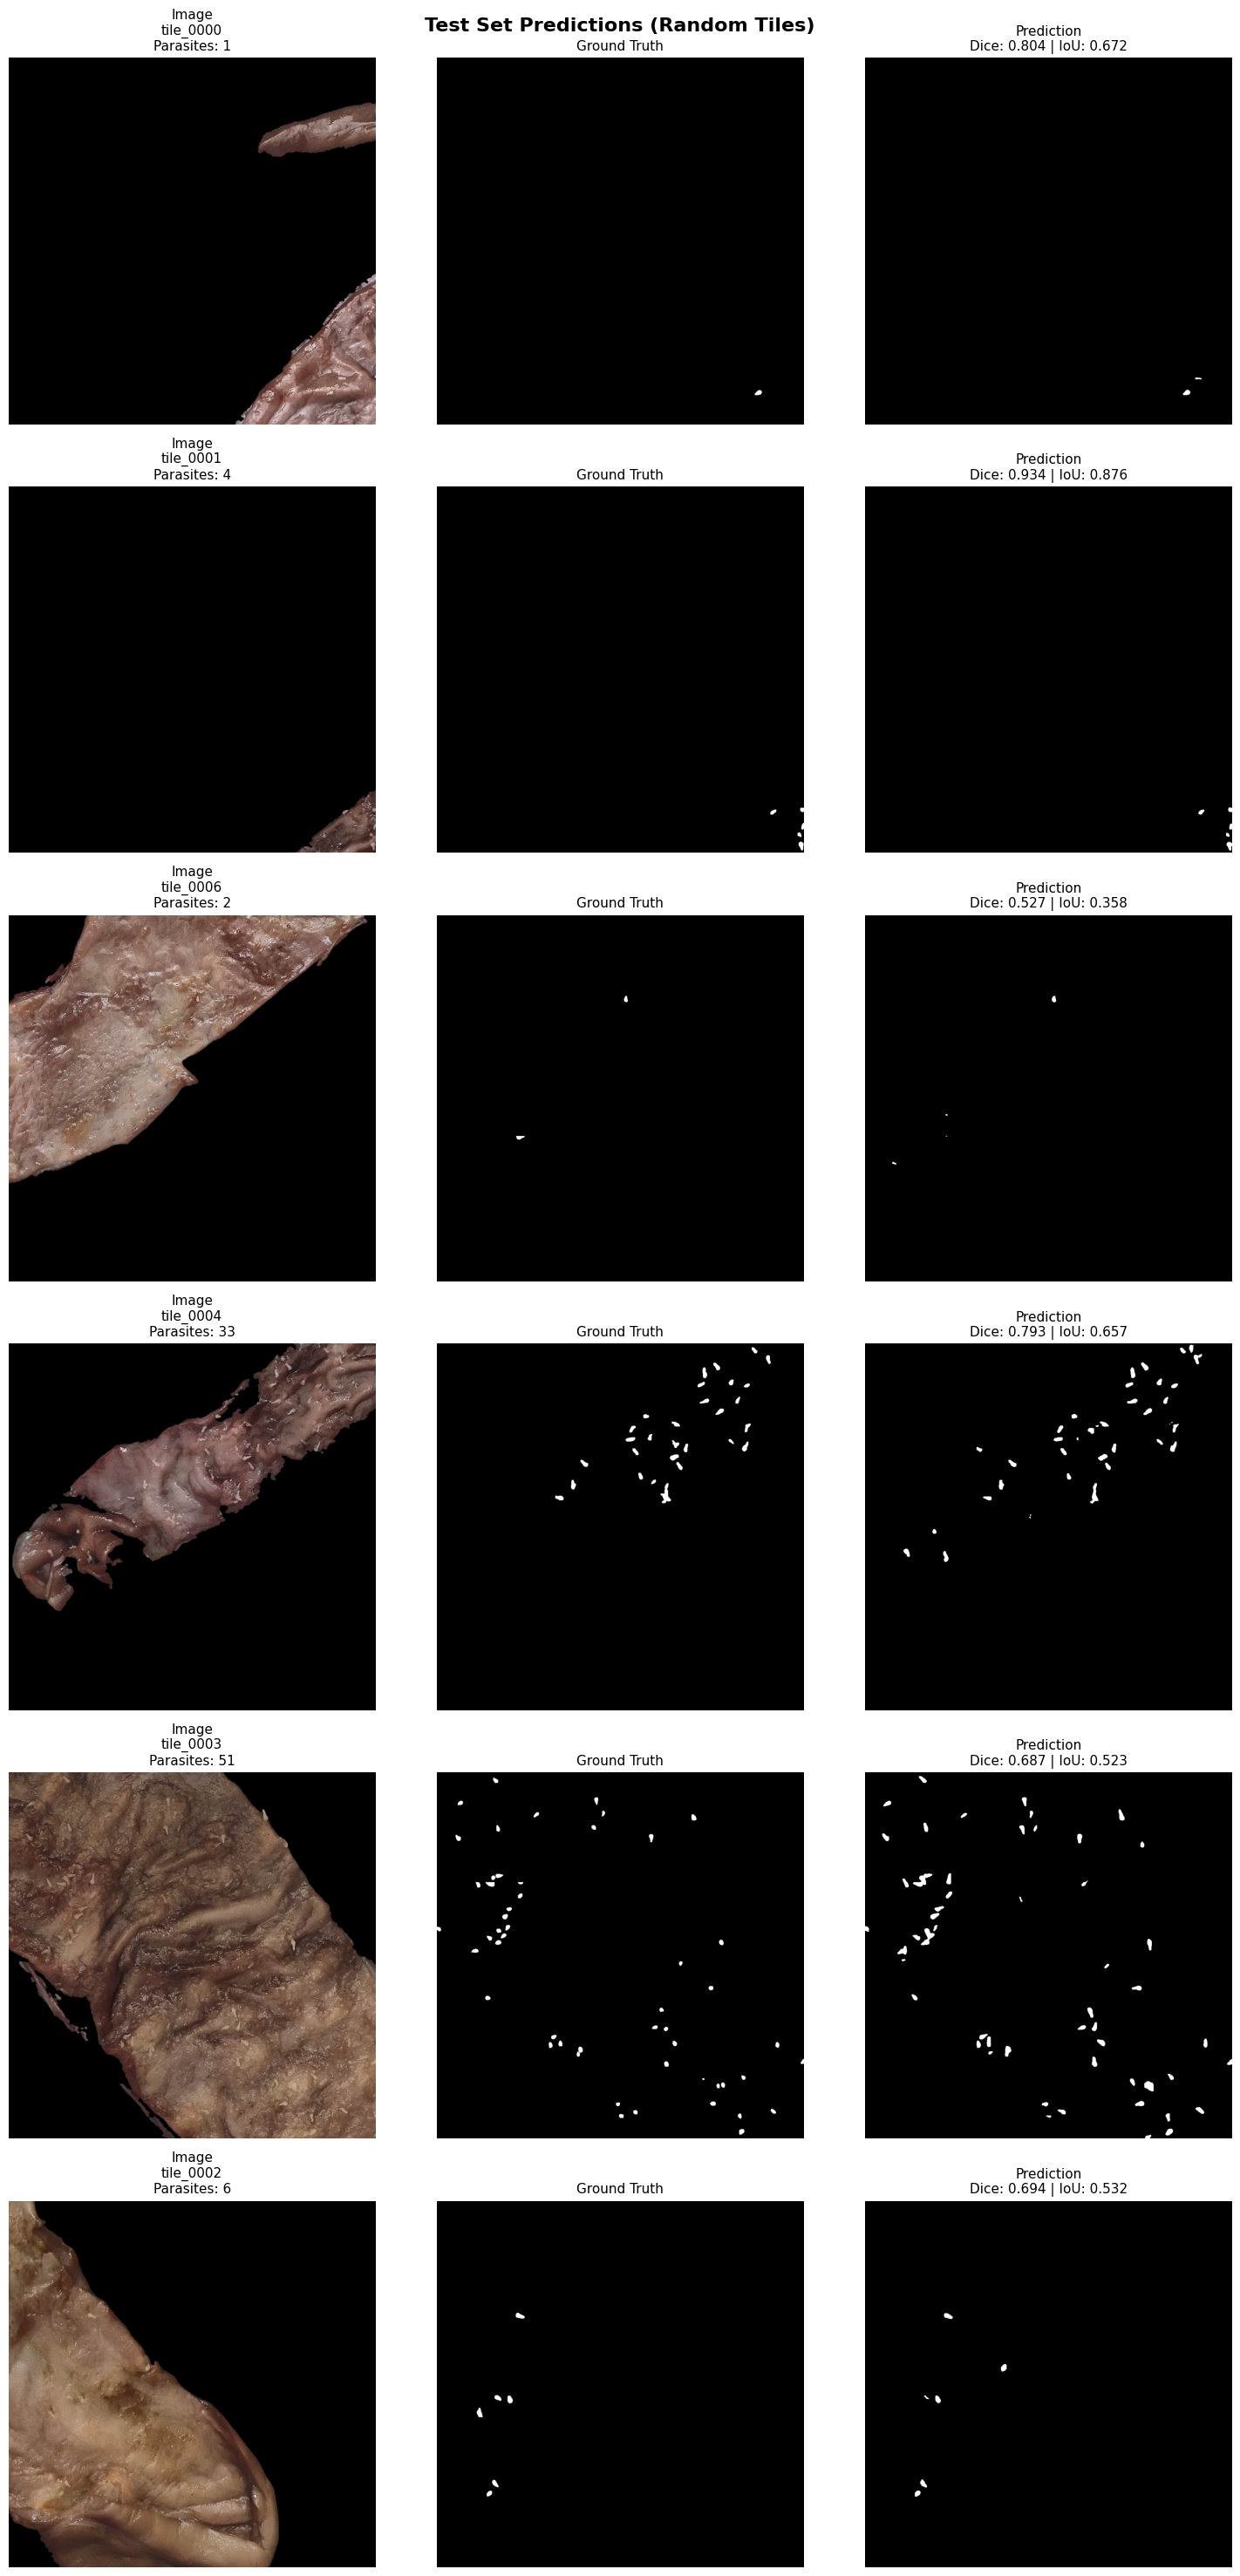

In [ ]:
import torch.serialization
import numpy as np

torch.serialization.add_safe_globals([np.core.multiarray.scalar])

best_checkpoint_path = f"{checkpoint_dir}/sam_best.pth"

checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=False  # Important
)

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Validation Recall: {checkpoint['best_val_recall']:.4f}")

sam_model, device = load_sam_model()

# Create fine_tuner with same config as training
eval_fine_tuner = SAMFineTuner_LoRA(
    sam_model=sam_model,
    device=device,
    lora_rank=checkpoint['lora_rank'],
    learning_rate=1e-4,
    bce_weight=checkpoint['bce_weight'],
    dice_weight=checkpoint['dice_weight']
)

# Load the trained weights
eval_fine_tuner.sam.load_state_dict(checkpoint['model_state_dict'])
eval_fine_tuner.sam.eval()

test_results = evaluate_on_test(
    fine_tuner=eval_fine_tuner,
    test_dataset=test_dataset,
    batch_size=4,
    visualize=True,         # Show some example predictions
    num_viz_samples=6       # Number of tiles to visualize
)

FULL IMAGE RECONSTRUCTION WITH VISUALIZATION
Testing on 6 images: ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']

Processing: B2025-00231b...
  Reconstructing: 4096 x 2805 (~131.5MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.7639 | IoU: 0.6179 | Precision: 0.7444 | Recall: 0.7843

Processing: B2025-00143b...
  Reconstructing: 3707 x 3687 (~156.4MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7507 | IoU: 0.6008 | Precision: 0.7958 | Recall: 0.7104

Processing: B2025-00206b...
  Reconstructing: 3660 x 3072 (~128.7MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7693 | IoU: 0.6251 | Precision: 0.7183 | Recall: 0.8282

Processing: B2025-00136b...
  Reconstructing: 4025 x 3433 (~158.1MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.8302 | IoU: 0.7097 | Precision: 0.8525 | Recall: 0.8090

Processing: B2025-00085.2...
  Reconstructing: 3207 x 3581 (~131.4MB, 9 tiles)
  Successfully processed 9/9 tiles
 

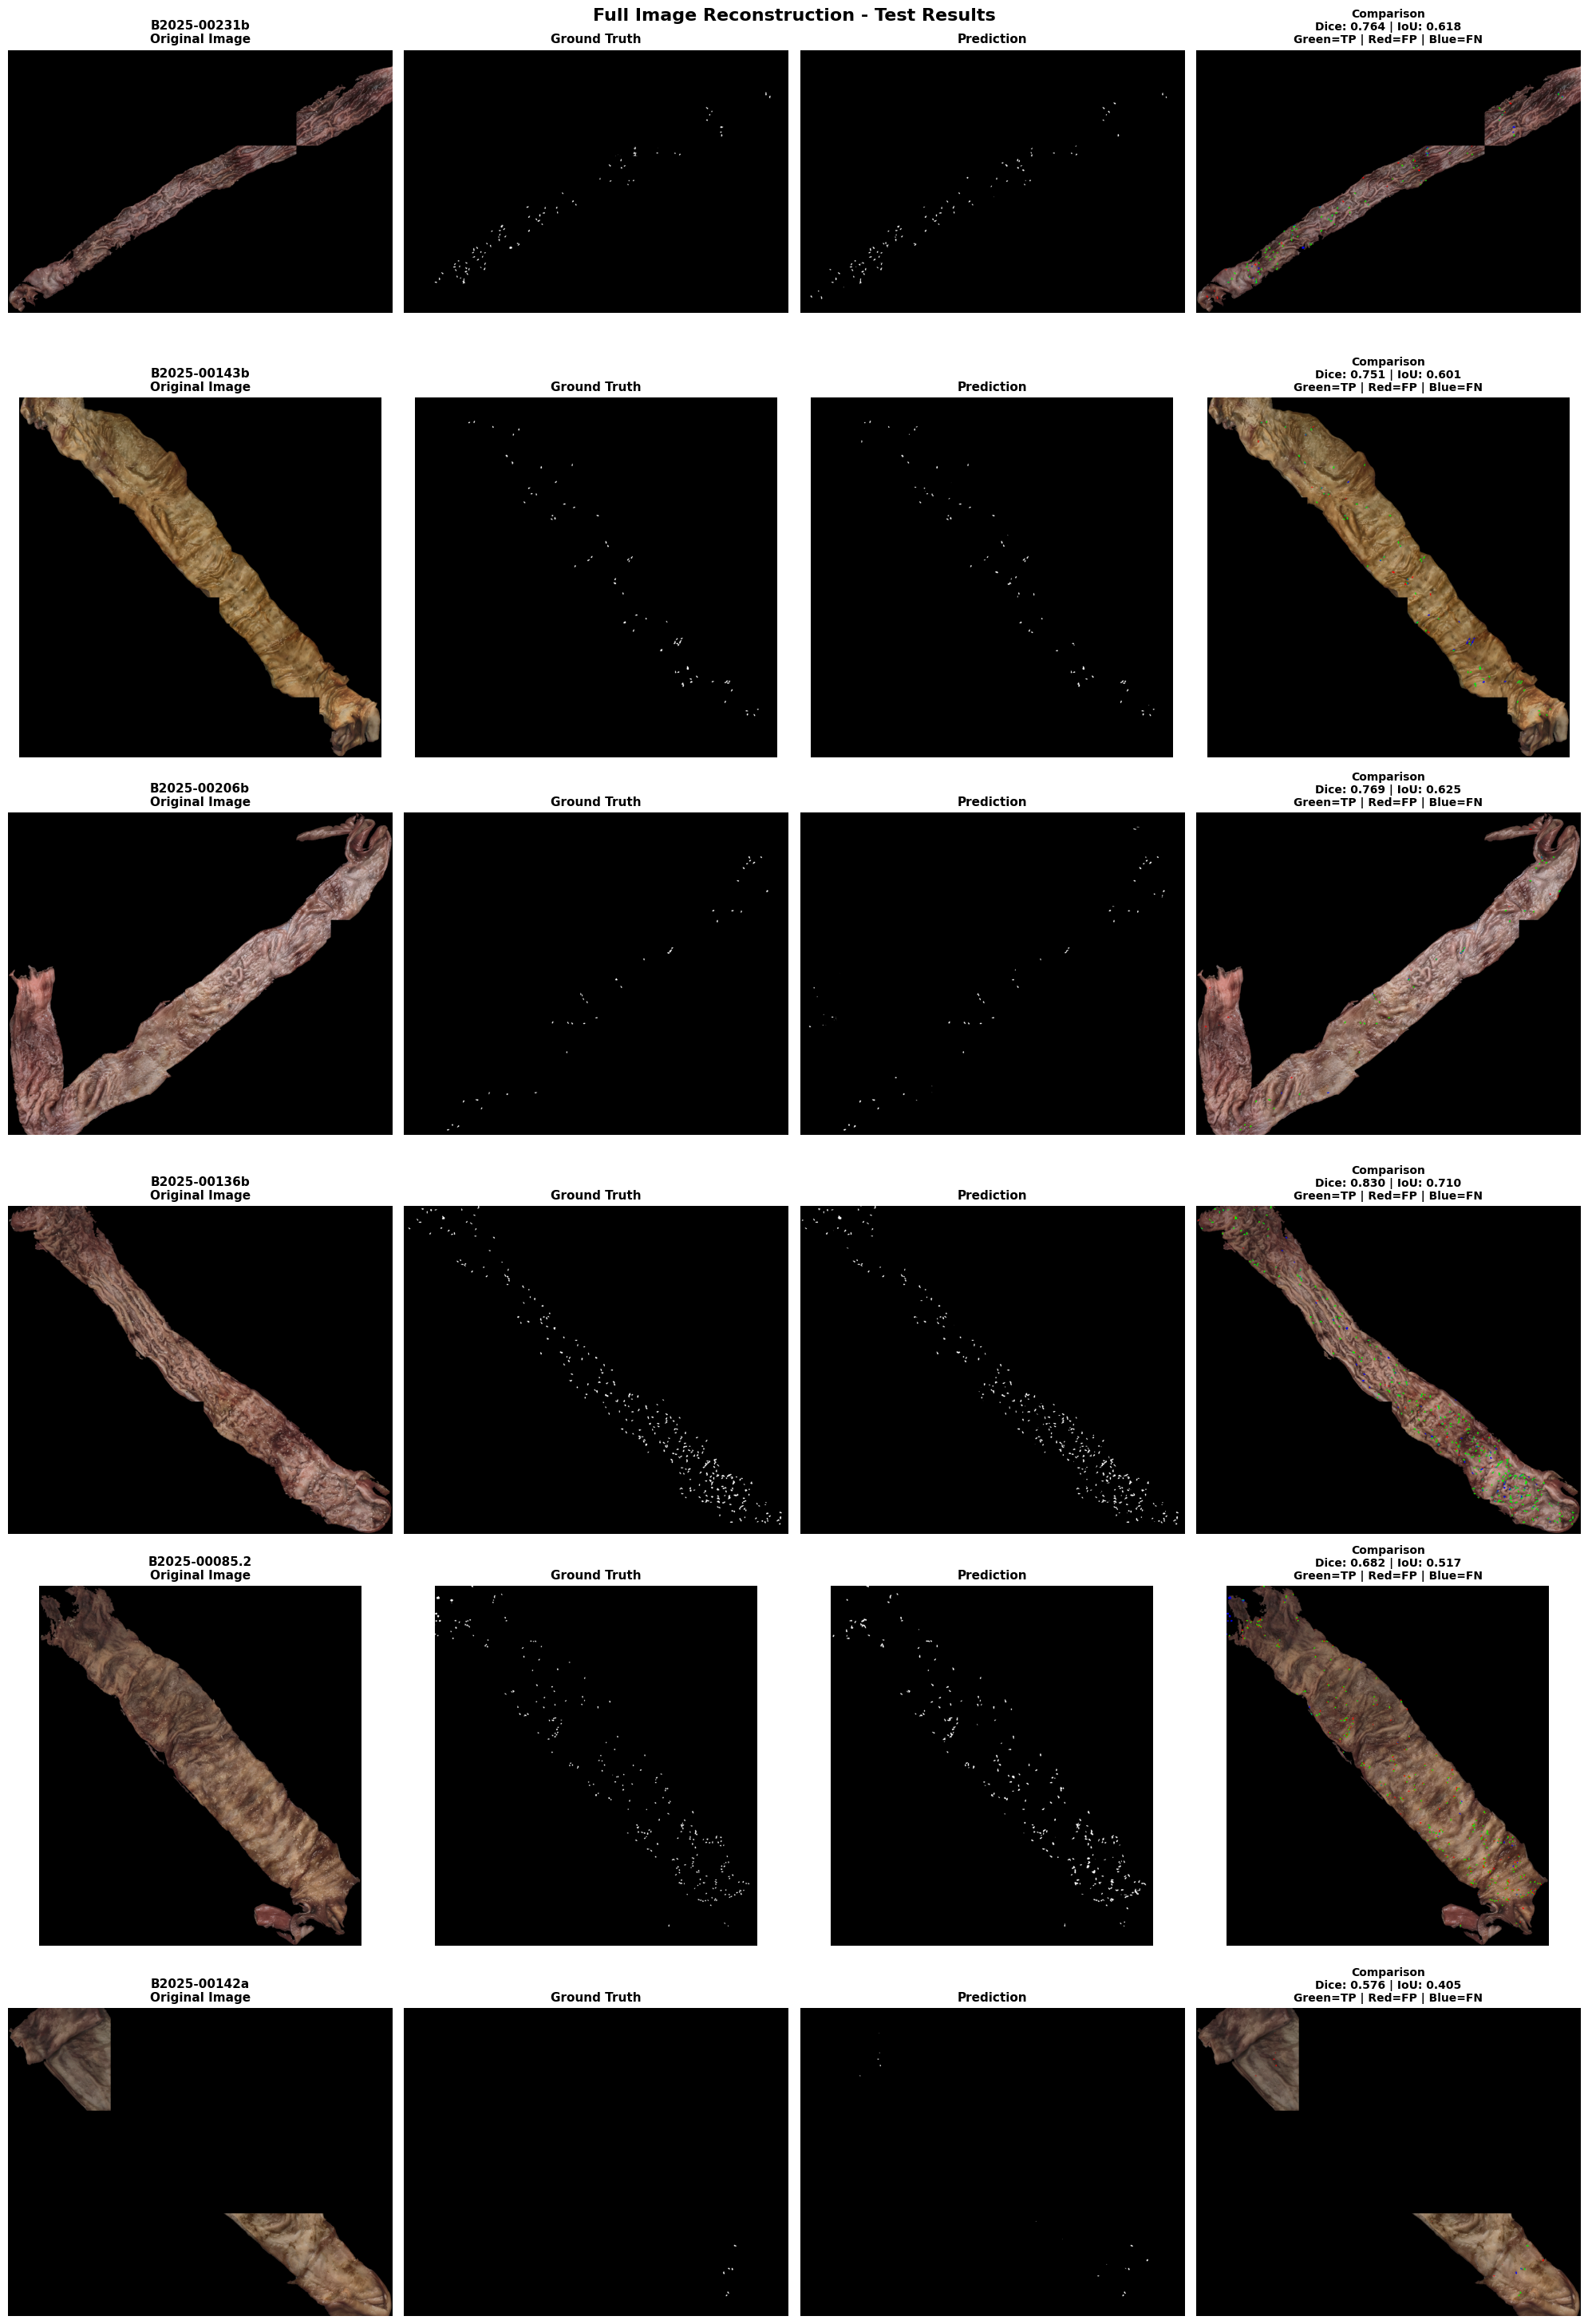

In [ ]:
import pandas as pd
results_df, visualizations = evaluate_full_images(
    fine_tuner=eval_fine_tuner,
    splits=splits,
    test_dataset=test_dataset,
    max_image_size_mb=300,                  # Skip images larger than 300MB
    process_in_chunks=True,                 # Process tiles in chunks
    chunk_size=30,                          # Clear cache every 30 tiles
)

## Experiment 3 - focal_loss, 'lora_rank': 32, 'optimizer': 'adam',

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

class SAMDatasetNoPrompt(Dataset):
    """Dataset for SAM fine-tuning WITHOUT prompts with Albumentations support"""

    def __init__(self, image_ids, output_dir, augment=False, transform=None):
        """
        Args:
            image_ids: List of image IDs
            output_dir: Directory containing processed tiles
            augment: Whether to use augmentation (for backward compatibility)
            transform: Albumentations transform pipeline (overrides augment if provided)
        """
        self.samples = []
        self.augment = augment
        self.transform = transform  # Albumentations transform

        for img_id in image_ids:
            tiles_dir = os.path.join(output_dir, img_id, "tiles")
            masks_dir = os.path.join(output_dir, img_id, "masks")
            annotations_dir = os.path.join(output_dir, img_id, "annotations")

            if not os.path.exists(tiles_dir):
                continue

            tile_files = [f for f in os.listdir(tiles_dir) if f.endswith('.png')]

            for tile_file in tile_files:
                tile_id = tile_file.replace('.png', '')
                tile_path = os.path.join(tiles_dir, tile_file)
                mask_path = os.path.join(masks_dir, f"{tile_id}.png")
                anno_path = os.path.join(annotations_dir, f"{tile_id}.json")

                if os.path.exists(mask_path) and os.path.exists(anno_path):
                    with open(anno_path, 'r') as f:
                        anno = json.load(f)

                    self.samples.append({
                        'tile_path': tile_path,
                        'mask_path': mask_path,
                        'tile_id': tile_id,
                        'base_image_id': img_id,
                        'num_parasites': anno['num_parasites']
                    })

        aug_type = "Albumentations" if self.transform else ("Basic" if self.augment else "None")
        print(f"Loaded {len(self.samples)} samples (augmentation={aug_type})")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load image and mask
        image = cv2.imread(sample['tile_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(sample['mask_path'], cv2.IMREAD_GRAYSCALE)

        # Binary mask (0 or 1)
        binary_mask = (mask > 127).astype(np.uint8)

        # Apply Albumentations transform if provided
        if self.transform is not None:
            transformed = self.transform(image=image, mask=binary_mask)
            image = transformed['image']
            mask_tensor = transformed['mask']

            # Normalize image to [0, 1] for SAM
            image_tensor = image.float() / 255.0

            # Ensure mask is float and has correct shape [1, H, W]
            if mask_tensor.dim() == 2:
                mask_tensor = mask_tensor.unsqueeze(0)
            mask_tensor = mask_tensor.float()

        # Fallback to basic augmentation (for backward compatibility)
        elif self.augment:
            if random.random() > 0.5:
                image = cv2.flip(image, 1).copy()
                binary_mask = cv2.flip(binary_mask, 1).copy()
            if random.random() > 0.5:
                image = cv2.flip(image, 0).copy()
                binary_mask = cv2.flip(binary_mask, 0).copy()
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])
                image = np.rot90(image, k).copy()
                binary_mask = np.rot90(binary_mask, k).copy()

            # Convert to tensors
            image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        # No augmentation
        else:
            image_tensor = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            mask_tensor = torch.from_numpy(binary_mask).unsqueeze(0).float()

        return {
            'image': image_tensor,
            'mask': mask_tensor,
            'tile_id': sample['tile_id'],
            'num_parasites': sample['num_parasites']
        }

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2


train_transforms = A.Compose([
    # Geometric augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.25),
    A.Rotate(limit=5, p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.25,
        rotate_limit=0,
        p=0.5,
        border_mode=cv2.BORDER_CONSTANT,
        value=0,
        mask_value=0
    ),
    A.Affine(
        shear=(-2, 2),
        p=0.3,
        mode=cv2.BORDER_CONSTANT,
        cval=0,
        cval_mask=0
    ),

    # Color augmentations
    A.HueSaturationValue(
        hue_shift_limit=int(0.015 * 180),
        sat_shift_limit=int(0.7 * 255),
        val_shift_limit=int(0.4 * 255),
        p=0.9
    ),

    # Additional augmentations
    A.OneOf([
        A.GaussianBlur(blur_limit=3, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.1),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),

    # Convert to tensor (image will be normalized to [0,1] in __getitem__)
    ToTensorV2(),
])

# Validation: No augmentation, just convert to tensor
val_transforms = A.Compose([
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-1757925039.py:10: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/tmp/ipython-input-1757925039.py:19: UserWarning: Argument(s) 'mode, cval, cval_mask' are not valid for transform Affine
  A.Affine(


In [ ]:
#Create datasets
train_dataset = SAMDatasetNoPrompt(
    image_ids=splits['train'],
    output_dir=output_dir,
    transform=train_transforms
)

val_dataset = SAMDatasetNoPrompt(
    image_ids=splits['val'],
    output_dir=output_dir,
    transform=val_transforms
)

test_dataset = SAMDatasetNoPrompt(
    image_ids=splits['test'],
    output_dir=output_dir,
    transform=val_transforms
)


Loaded 240 samples (augmentation=Albumentations)
Loaded 34 samples (augmentation=Albumentations)
Loaded 40 samples (augmentation=Albumentations)


The `FocalLoss` class implements focal loss for handling class imbalance. It down-weights easy examples (background pixels) and focuses training on hard examples (missed parasites).

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance in segmentation tasks.

    Focal loss down-weights well-classified examples and focuses training
    on hard negatives (missed detections). This is particularly useful for
    parasite detection where positive pixels are sparse and easy background
    pixels would otherwise dominate the gradient.

    Formula: FL(pt) = -alpha * (1 - pt)^gamma * log(pt)

    Reference: Lin et al., "Focal Loss for Dense Object Detection" (2017)
    """

    def __init__(self, alpha=0.25, gamma=2.0):
        """
        Initialize Focal Loss.

        Args:
            alpha: Weighting factor for the rare class (default: 0.25)
            gamma: Focusing parameter - higher values increase focus on
                   hard examples (default: 2.0)
                   - gamma=0 equivalent to standard cross-entropy
                   - gamma=2 recommended starting point
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, pred, target):
        """
        Compute focal loss between predictions and targets.

        Args:
            pred: Predicted logits (B, 1, H, W)
            target: Ground truth binary masks (B, 1, H, W)

        Returns:
            Scalar focal loss value
        """
        # Compute binary cross-entropy per pixel (without reduction)
        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')

        # Compute probability of correct classification
        # pt = p if y=1, else (1-p)
        pt = torch.exp(-bce)

        # Apply focal modulation: (1 - pt)^gamma
        # This reduces loss contribution from easy examples (high pt)
        # and increases contribution from hard examples (low pt)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce

        return focal_loss.mean()

The `SAMFineTuner_LoRA` class implements parameter-efficient fine-tuning using Low-Rank Adaptation. This version replaces standard BCE with Focal Loss.

In [ ]:
class SAMFineTuner_LoRA:
    """
    Fine-tuner for Segment Anything Model (SAM) using Low-Rank Adaptation (LoRA).

    This version uses Focal Loss instead of standard BCE to automatically focus
    on hard examples (missed parasites), improving detection of sparse targets.

    Training strategy:
        - Image encoder: Frozen except for LoRA adapters on QKV projections
        - Prompt encoder: Fully frozen (no prompts used)
        - Mask decoder: Fully trainable

    Loss function:
        - Focal Loss: Down-weights easy background pixels, focuses on hard examples
        - Dice Loss: Directly optimizes overlap, handles class imbalance
    """

    def __init__(self, sam_model, device, learning_rate=1e-4, lora_rank=8,
                optimizer_type='adam', weight_decay=1e-4,
                bce_weight=1.0, dice_weight=1.0, grad_clip=None,
                pos_weight=1.0):
        """
        Initialize SAM fine-tuner with LoRA and Focal Loss.

        Args:
            sam_model: Pretrained SAM model instance
            device: Target device ('cuda' or 'cpu')
            learning_rate: Learning rate for optimizer (default: 1e-4)
            lora_rank: Rank of LoRA decomposition matrices (default: 8)
            optimizer_type: Optimizer choice - 'adam', 'adamw', or 'sgd'
            weight_decay: L2 regularization strength (default: 1e-4)
            bce_weight: Weight for Focal loss component (default: 1.0)
            dice_weight: Weight for Dice loss component (default: 1.0)
            grad_clip: Maximum gradient norm for clipping (default: None)
            pos_weight: Unused in this version (Focal Loss handles imbalance)
        """
        self.sam = sam_model
        self.device = device
        self.lora_rank = lora_rank
        self.grad_clip = grad_clip
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.pos_weight = pos_weight

        # Inject LoRA adapters into image encoder attention layers
        self._apply_lora_to_image_encoder()

        # Freeze base image encoder, keep only LoRA parameters trainable
        for name, param in self.sam.image_encoder.named_parameters():
            if 'lora' not in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        # Freeze prompt encoder entirely (not used in prompt-free mode)
        for param in self.sam.prompt_encoder.parameters():
            param.requires_grad = False

        # Train mask decoder fully
        for param in self.sam.mask_decoder.parameters():
            param.requires_grad = True

        # Collect trainable parameters: LoRA adapters + mask decoder
        lora_params = [p for n, p in self.sam.image_encoder.named_parameters()
                      if 'lora' in n and p.requires_grad]
        decoder_params = list(self.sam.mask_decoder.parameters())
        trainable_params = lora_params + decoder_params

        # Initialize optimizer based on specified type
        if optimizer_type.lower() == 'adam':
            self.optimizer = torch.optim.Adam(
                trainable_params,
                lr=learning_rate
            )
        elif optimizer_type.lower() == 'adamw':
            self.optimizer = torch.optim.AdamW(
                trainable_params,
                lr=learning_rate,
                weight_decay=weight_decay
            )
        elif optimizer_type.lower() == 'sgd':
            self.optimizer = torch.optim.SGD(
                trainable_params,
                lr=learning_rate,
                momentum=0.9,
                weight_decay=weight_decay
            )
        else:
            raise ValueError(f"Unknown optimizer: {optimizer_type}")

        # Use Focal Loss instead of standard BCE
        # Focal Loss automatically down-weights easy examples and focuses on hard ones
        self.bce_loss = FocalLoss(alpha=0.25, gamma=2.0)
        print(f"Using Focal Loss (alpha=0.25, gamma=2.0) - automatic hard example mining")

        self.dice_loss = self.dice_loss_fn

        # Log parameter counts for verification
        total_params = sum(p.numel() for p in self.sam.parameters())
        trainable_params_count = sum(p.numel() for p in self.sam.parameters() if p.requires_grad)
        lora_params_count = sum(p.numel() for p in lora_params)

        print(f"Trainable parameters:    {trainable_params_count:,} ({100*trainable_params_count/total_params:.2f}%)")
        print(f"  - LoRA parameters:     {lora_params_count:,}")
        print(f"  - Decoder parameters:  {trainable_params_count - lora_params_count:,}")


    def _apply_lora_to_image_encoder(self):
        """
        Apply LoRA adapters to QKV projection layers in each transformer block.

        For each attention layer, the original linear projection is replaced with
        a LoRA-augmented version that adds a low-rank update: W' = W + BA
        where B and A are the trainable low-rank matrices.
        """
        for block_idx, block in enumerate(self.sam.image_encoder.blocks):
            attn = block.attn
            original_qkv = attn.qkv
            in_features = original_qkv.in_features
            out_features = original_qkv.out_features

            # Preserve original pretrained weights
            original_weight = original_qkv.weight.data.clone()
            original_bias = original_qkv.bias.data.clone() if original_qkv.bias is not None else None

            # Create LoRA-augmented linear layer
            # lora_alpha controls the scaling of the low-rank update
            lora_qkv = lora.Linear(
                in_features,
                out_features,
                r=self.lora_rank,
                lora_alpha=self.lora_rank * 2,
                lora_dropout=0.1,
                merge_weights=False,
                bias=original_qkv.bias is not None
            )

            # Copy pretrained weights to new layer (LoRA matrices initialized separately)
            with torch.no_grad():
                lora_qkv.weight.copy_(original_weight)
                if original_bias is not None:
                    lora_qkv.bias.copy_(original_bias)

            # Replace original layer with LoRA version
            attn.qkv = lora_qkv.to(self.device)

        print(f"Applied LoRA (rank={self.lora_rank}) to {len(self.sam.image_encoder.blocks)} transformer blocks")


    def dice_loss_fn(self, pred, target, smooth=1e-5):
        """
        Compute Dice loss for segmentation.

        Dice loss directly optimizes the Dice coefficient, which measures
        overlap between prediction and ground truth. Complements Focal Loss
        by providing region-level supervision.

        Args:
            pred: Predicted logits (B, 1, H, W)
            target: Ground truth binary masks (B, 1, H, W)
            smooth: Smoothing term to avoid division by zero

        Returns:
            Scalar Dice loss (1 - Dice coefficient)
        """
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        dice = (2. * intersection + smooth) / (union + smooth)
        return 1 - dice.mean()

    def compute_metrics(self, pred, target, threshold=0.5):
        """
        Compute confusion matrix components for metric accumulation.

        Returns raw counts (TP, FP, FN, TN) rather than final metrics
        to enable proper aggregation across batches.

        Args:
            pred: Predicted logits
            target: Ground truth masks
            threshold: Binarization threshold for predictions

        Returns:
            Dictionary with tp, fp, fn, tn counts
        """
        pred_binary = (torch.sigmoid(pred) > threshold).float()
        target_binary = target.float()

        pred_flat = pred_binary.view(-1)
        target_flat = target_binary.view(-1)

        tp = (pred_flat * target_flat).sum()
        fp = (pred_flat * (1 - target_flat)).sum()
        fn = ((1 - pred_flat) * target_flat).sum()
        tn = ((1 - pred_flat) * (1 - target_flat)).sum()

        return {
            'tp': tp.item(),
            'fp': fp.item(),
            'fn': fn.item(),
            'tn': tn.item()
        }

    @staticmethod
    def compute_final_metrics(total_tp, total_fp, total_fn, total_tn):
        """
        Compute final evaluation metrics from accumulated confusion matrix counts.

        Args:
            total_tp: Total true positives across all batches
            total_fp: Total false positives
            total_fn: Total false negatives
            total_tn: Total true negatives

        Returns:
            Dictionary with IoU, Dice, precision, recall, and F1 scores
        """
        smooth = 1e-7
        iou = (total_tp + smooth) / (total_tp + total_fp + total_fn + smooth)
        dice = (2 * total_tp + smooth) / (2 * total_tp + total_fp + total_fn + smooth)
        precision = (total_tp + smooth) / (total_tp + total_fp + smooth)
        recall = (total_tp + smooth) / (total_tp + total_fn + smooth)
        f1 = (2 * precision * recall) / (precision + recall + smooth)

        return {
            'iou': iou,
            'dice': dice,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }

    def train_step(self, batch):
        """
        Execute single training step with forward pass, loss computation, and weight update.

        Args:
            batch: Dictionary containing 'image' and 'mask' tensors

        Returns:
            Dictionary with loss values and metric components
        """
        self.sam.train()
        self.optimizer.zero_grad()

        # Move data to device
        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Forward pass through image encoder (LoRA adapters active)
        image_embeddings = self.sam.image_encoder(images)

        # Get empty prompt embeddings (prompt-free mode)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        # Generate mask predictions
        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        # Upsample to original resolution for loss computation
        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Compute combined loss (Focal + Dice)
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        # Backward pass
        loss.backward()

        # Optional gradient clipping for training stability
        if self.grad_clip:
            torch.nn.utils.clip_grad_norm_(
                [p for p in self.sam.parameters() if p.requires_grad],
                max_norm=self.grad_clip
            )

        # Update weights
        self.optimizer.step()

        # Compute metrics without gradient tracking
        with torch.no_grad():
            metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    @torch.no_grad()
    def val_step(self, batch):
        """
        Execute validation step (inference only, no gradient computation).

        Args:
            batch: Dictionary containing 'image' and 'mask' tensors

        Returns:
            Dictionary with loss values and metric components
        """
        self.sam.eval()

        images = batch['image'].to(self.device)
        masks_gt = batch['mask'].to(self.device)

        # Forward pass (same as training but without gradients)
        image_embeddings = self.sam.image_encoder(images)
        sparse_embeddings, dense_embeddings = self.sam.prompt_encoder(
            points=None, boxes=None, masks=None
        )
        sparse_embeddings = sparse_embeddings.to(self.device)
        dense_embeddings = dense_embeddings.to(self.device)

        low_res_masks, _ = self.sam.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=self.sam.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=False
        )

        pred_masks = F.interpolate(
            low_res_masks,
            size=masks_gt.shape[-2:],
            mode='bilinear',
            align_corners=False
        )

        # Compute losses and metrics
        loss_bce = self.bce_loss(pred_masks, masks_gt)
        loss_dice = self.dice_loss(pred_masks, masks_gt)
        loss = self.bce_weight * loss_bce + self.dice_weight * loss_dice

        metric_components = self.compute_metrics(pred_masks, masks_gt)

        return {
            'loss': loss.item(),
            'loss_bce': loss_bce.item(),
            'loss_dice': loss_dice.item(),
            **metric_components
        }

    def save_checkpoint(self, path):
        """
        Save model checkpoint with LoRA weights, decoder state, and optimizer.

        Only saves the trainable components (not the frozen base model),
        keeping checkpoint files compact.

        Args:
            path: File path for checkpoint
        """
        torch.save({
            'mask_decoder': self.sam.mask_decoder.state_dict(),
            'lora_state': {n: p.data for n, p in self.sam.image_encoder.named_parameters() if 'lora' in n},
            'optimizer': self.optimizer.state_dict()
        }, path)
        print(f"Checkpoint saved to {path}")

    def load_checkpoint(self, path, load_optimizer=True):
        """
        Load model checkpoint and restore LoRA weights and decoder state.

        Args:
            path: Path to checkpoint file
            load_optimizer: Whether to restore optimizer state (for resuming training)
        """
        checkpoint = torch.load(path, map_location=self.device)
        self.sam.mask_decoder.load_state_dict(checkpoint['mask_decoder'])

        # Restore LoRA adapter weights
        if 'lora_state' in checkpoint:
            for name, param in self.sam.image_encoder.named_parameters():
                if name in checkpoint['lora_state']:
                    param.data.copy_(checkpoint['lora_state'][name])

        # Optionally restore optimizer state for training continuation
        if load_optimizer and 'optimizer' in checkpoint:
            self.optimizer.load_state_dict(checkpoint['optimizer'])
            print("Optimizer state loaded")

        print(f"Checkpoint loaded from {path}")

The `train_sam_lora` function runs the complete training pipeline with Focal Loss and Dice loss. It accumulates confusion matrix components across batches for accurate epoch-level metrics, supports multiple learning rate schedulers (cosine, plateau, step) and saves checkpoints to Google Drive. The best model is selected based on validation Dice score, with early stopping available if no improvement is seen.

In [ ]:
def train_sam_lora(sam_model, train_dataset, val_dataset, config, save_to_drive=True):
    """
    Main training loop for SAM fine-tuning with LoRA.

    Handles the complete training pipeline including:
        - DataLoader setup
        - LoRA fine-tuner initialization
        - Learning rate scheduling
        - Metric tracking and logging
        - Checkpoint saving (best, periodic, final)
        - Early stopping based on validation Dice score

    Args:
        sam_model: Pretrained SAM model to fine-tune
        train_dataset: Training dataset (SAMDatasetNoPrompt instance)
        val_dataset: Validation dataset
        config: Dictionary containing training hyperparameters:
            - exp_name: Experiment name for checkpoint directory
            - batch_size: Batch size for training
            - num_epochs: Maximum number of training epochs
            - learning_rate: Initial learning rate
            - lora_rank: Rank for LoRA adapters (default: 8)
            - optimizer: 'adam', 'adamw', or 'sgd' (default: 'adam')
            - weight_decay: L2 regularization (default: 1e-4)
            - bce_weight: Weight for Focal loss (default: 1.0)
            - dice_weight: Weight for Dice loss (default: 1.0)
            - pos_weight: Unused with Focal Loss (default: 1.0)
            - grad_clip: Max gradient norm (default: None)
            - scheduler: 'cosine', 'plateau', 'step', or None
            - early_stop_patience: Epochs without improvement before stopping
        save_to_drive: If True, save checkpoints to Google Drive

    Returns:
        history: Dictionary containing training/validation metrics per epoch
        fine_tuner: Trained SAMFineTuner_LoRA instance
        checkpoint_dir: Path to saved checkpoints
    """
    # Extract configuration parameters
    exp_name = config['exp_name']
    batch_size = config['batch_size']
    num_epochs = config['num_epochs']
    learning_rate = config['learning_rate']
    lora_rank = config.get('lora_rank', 8)
    optimizer_type = config.get('optimizer', 'adam')
    weight_decay = config.get('weight_decay', 1e-4)
    bce_weight = config.get('bce_weight', 1.0)
    dice_weight = config.get('dice_weight', 1.0)
    pos_weight = config.get('pos_weight', 1.0)
    grad_clip = config.get('grad_clip', None)
    scheduler_type = config.get('scheduler', None)
    early_stop_patience = config.get('early_stop_patience', None)

    # Setup checkpoint directory (Google Drive for persistence across Colab sessions)
    if save_to_drive:
        checkpoint_dir = f"/content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/{exp_name}"
    else:
        checkpoint_dir = f"sam_checkpoints/{exp_name}"

    os.makedirs(checkpoint_dir, exist_ok=True)
    print(f"Checkpoints will be saved to: {checkpoint_dir}")

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # Move model to GPU if available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sam_model.to(device)

    # Initialize LoRA fine-tuner with Focal Loss
    fine_tuner = SAMFineTuner_LoRA(
        sam_model, device,
        learning_rate=learning_rate,
        lora_rank=lora_rank,
        optimizer_type=optimizer_type,
        weight_decay=weight_decay,
        bce_weight=bce_weight,
        dice_weight=dice_weight,
        grad_clip=grad_clip,
        pos_weight=pos_weight
    )

    # Setup learning rate scheduler if specified
    scheduler = None
    if scheduler_type == 'cosine':
        # Smooth decay to minimum LR over training duration
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            fine_tuner.optimizer, T_max=num_epochs, eta_min=1e-6
        )
        print(f"Using CosineAnnealingLR scheduler")
    elif scheduler_type == 'plateau':
        # Reduce LR when validation loss plateaus
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            fine_tuner.optimizer, mode='min', factor=0.5, patience=5, verbose=True
        )
        print(f"Using ReduceLROnPlateau scheduler")
    elif scheduler_type == 'step':
        # Fixed LR decay every N epochs
        scheduler = torch.optim.lr_scheduler.StepLR(
            fine_tuner.optimizer, step_size=10, gamma=0.5
        )
        print(f"Using StepLR scheduler")

    # Initialize training history for all tracked metrics
    history = {
        'train_loss': [], 'train_loss_bce': [], 'train_loss_dice': [],
        'train_iou': [], 'train_dice': [], 'train_precision': [],
        'train_recall': [], 'train_f1': [],
        'val_loss': [], 'val_loss_bce': [], 'val_loss_dice': [],
        'val_iou': [], 'val_dice': [], 'val_precision': [],
        'val_recall': [], 'val_f1': []
    }

    # Track best model based on validation Dice score
    best_val_dice = 0.0
    best_epoch = 0
    patience_counter = 0

    # Main training loop
    for epoch in range(num_epochs):

        # ==================== TRAINING PHASE ====================
        # Accumulate confusion matrix components across batches
        train_losses = []
        train_losses_bce = []
        train_losses_dice = []
        train_tp = 0
        train_fp = 0
        train_fn = 0
        train_tn = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for batch in pbar:
            step_results = fine_tuner.train_step(batch)

            # Accumulate losses
            train_losses.append(step_results['loss'])
            train_losses_bce.append(step_results['loss_bce'])
            train_losses_dice.append(step_results['loss_dice'])

            # Accumulate confusion matrix components
            train_tp += step_results['tp']
            train_fp += step_results['fp']
            train_fn += step_results['fn']
            train_tn += step_results['tn']

            # Compute running metrics for progress bar
            running_metrics = fine_tuner.compute_final_metrics(
                train_tp, train_fp, train_fn, train_tn
            )

            pbar.set_postfix({
                'loss': f"{step_results['loss']:.4f}",
                'dice': f"{running_metrics['dice']:.4f}",
                'iou': f"{running_metrics['iou']:.4f}"
            })

        # ==================== VALIDATION PHASE ====================
        val_losses = []
        val_losses_bce = []
        val_losses_dice = []
        val_tp = 0
        val_fp = 0
        val_fn = 0
        val_tn = 0

        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False):
            step_results = fine_tuner.val_step(batch)

            val_losses.append(step_results['loss'])
            val_losses_bce.append(step_results['loss_bce'])
            val_losses_dice.append(step_results['loss_dice'])

            val_tp += step_results['tp']
            val_fp += step_results['fp']
            val_fn += step_results['fn']
            val_tn += step_results['tn']

        # Compute final epoch metrics from accumulated counts
        train_metrics = fine_tuner.compute_final_metrics(train_tp, train_fp, train_fn, train_tn)
        val_metrics = fine_tuner.compute_final_metrics(val_tp, val_fp, val_fn, val_tn)

        # Record metrics to history
        history['train_loss'].append(np.mean(train_losses))
        history['train_loss_bce'].append(np.mean(train_losses_bce))
        history['train_loss_dice'].append(np.mean(train_losses_dice))
        history['train_iou'].append(train_metrics['iou'])
        history['train_dice'].append(train_metrics['dice'])
        history['train_precision'].append(train_metrics['precision'])
        history['train_recall'].append(train_metrics['recall'])
        history['train_f1'].append(train_metrics['f1'])

        history['val_loss'].append(np.mean(val_losses))
        history['val_loss_bce'].append(np.mean(val_losses_bce))
        history['val_loss_dice'].append(np.mean(val_losses_dice))
        history['val_iou'].append(val_metrics['iou'])
        history['val_dice'].append(val_metrics['dice'])
        history['val_precision'].append(val_metrics['precision'])
        history['val_recall'].append(val_metrics['recall'])
        history['val_f1'].append(val_metrics['f1'])

        # Extract current epoch metrics for logging
        avg_train_loss = history['train_loss'][-1]
        avg_train_dice = history['train_dice'][-1]
        avg_train_iou = history['train_iou'][-1]
        avg_train_precision = history['train_precision'][-1]
        avg_train_recall = history['train_recall'][-1]
        avg_train_f1 = history['train_f1'][-1]

        avg_val_loss = history['val_loss'][-1]
        avg_val_dice = history['val_dice'][-1]
        avg_val_iou = history['val_iou'][-1]
        avg_val_precision = history['val_precision'][-1]
        avg_val_recall = history['val_recall'][-1]
        avg_val_f1 = history['val_f1'][-1]

        # Update learning rate scheduler
        if scheduler:
            if scheduler_type == 'plateau':
                scheduler.step(avg_val_loss)  # Plateau scheduler uses validation loss
            else:
                scheduler.step()

        # Log epoch summary
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"  Train | Loss: {avg_train_loss:.4f} | Dice: {avg_train_dice:.4f} | IoU: {avg_train_iou:.4f}")
        print(f"        | Precision: {avg_train_precision:.4f} | Recall: {avg_train_recall:.4f} | F1: {avg_train_f1:.4f}")
        print(f"  Val   | Loss: {avg_val_loss:.4f} | Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f}")
        print(f"        | Precision: {avg_val_precision:.4f} | Recall: {avg_val_recall:.4f} | F1: {avg_val_f1:.4f}")

        # Save best model based on validation Dice score
        if avg_val_dice > best_val_dice:
            best_val_dice = avg_val_dice
            best_epoch = epoch + 1
            patience_counter = 0

            # Save comprehensive checkpoint with all metadata
            best_checkpoint_path = os.path.join(checkpoint_dir, "sam_best.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'best_dice': best_val_dice,
                'val_metrics': val_metrics,
                'train_metrics': train_metrics,
                'lora_rank': lora_rank,
                'bce_weight': bce_weight,
                'dice_weight': dice_weight,
                'config': config
            }, best_checkpoint_path)

            print(f"\nNew best model saved (Dice: {best_val_dice:.4f})")
        else:
            patience_counter += 1

        # Check early stopping condition
        if early_stop_patience and patience_counter >= early_stop_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

        # Save periodic checkpoint every 5 epochs (for training resumption)
        if (epoch + 1) % 5 == 0:
            epoch_checkpoint_path = os.path.join(checkpoint_dir, f"sam_epoch_{epoch+1}.pth")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': fine_tuner.sam.state_dict(),
                'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
                'val_dice': avg_val_dice,
                'lora_rank': lora_rank,
                'config': config
            }, epoch_checkpoint_path)
            print(f"Checkpoint saved: epoch_{epoch+1}.pth")

        print()

    # Save final model with complete training history
    final_checkpoint_path = os.path.join(checkpoint_dir, "sam_final.pth")
    torch.save({
        'epoch': num_epochs,
        'model_state_dict': fine_tuner.sam.state_dict(),
        'optimizer_state_dict': fine_tuner.optimizer.state_dict(),
        'final_val_dice': avg_val_dice,
        'best_val_dice': best_val_dice,
        'best_epoch': best_epoch,
        'lora_rank': lora_rank,
        'config': config,
        'history': history
    }, final_checkpoint_path)

    return history, fine_tuner, checkpoint_dir

In [ ]:
# Training configuration
config = {
    'exp_name': '32_focal_all_tiles',
    'batch_size': 1,
    'num_epochs': 30,
    'learning_rate': 1e-4,
    'lora_rank': 32,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'bce_weight': 1.0,
    'dice_weight': 1.0,
    'grad_clip': None,
    'augmentation': False,
    'scheduler': None,
    'early_stop_patience': 5
}

sam_model, device = load_sam_model()
# Train
history, fine_tuner, checkpoint_dir = train_sam_lora(sam_model, train_dataset, val_dataset, config)

Checkpoints will be saved to: /content/drive/MyDrive/SAM_Parasite_Detection/checkpoints/32_focal_all_tiles
Applied LoRA (rank=32) to 12 transformer blocks
Using Focal Loss (alpha=0.25, gamma=2.0) - automatic hard example mining
Trainable parameters:    5,237,988(5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340


Epoch 1/30 [Train]: 100%|██████████| 240/240 [02:25<00:00,  1.65it/s, loss=0.2736, dice=0.4904, iou=0.3249]



Epoch 1/30
  Train | Loss: 0.5716 | Dice: 0.4904 | IoU: 0.3249
        | Precision: 0.4109 | Recall: 0.6082 | F1: 0.4904
  Val   | Loss: 0.4434 | Dice: 0.7572 | IoU: 0.6093
        | Precision: 0.7386 | Recall: 0.7768 | F1: 0.7572

New best model saved (Dice: 0.7572)



Epoch 2/30 [Train]: 100%|██████████| 240/240 [02:25<00:00,  1.65it/s, loss=0.5185, dice=0.6698, iou=0.5036]



Epoch 2/30
  Train | Loss: 0.4588 | Dice: 0.6698 | IoU: 0.5036
        | Precision: 0.6644 | Recall: 0.6753 | F1: 0.6698
  Val   | Loss: 0.4220 | Dice: 0.7662 | IoU: 0.6210
        | Precision: 0.7205 | Recall: 0.8181 | F1: 0.7662

New best model saved (Dice: 0.7662)



...


Epoch 9/30
  Train | Loss: 0.4126 | Dice: 0.7073 | IoU: 0.5471
        | Precision: 0.7144 | Recall: 0.7002 | F1: 0.7073
  Val   | Loss: 0.3459 | Dice: 0.7813 | IoU: 0.6410
        | Precision: 0.7539 | Recall: 0.8106 | F1: 0.7812



Epoch 10/30 [Train]: 100%|██████████| 240/240 [02:25<00:00,  1.65it/s, loss=0.2864, dice=0.7017, iou=0.5405]



Epoch 10/30
  Train | Loss: 0.4004 | Dice: 0.7017 | IoU: 0.5405
        | Precision: 0.7079 | Recall: 0.6957 | F1: 0.7017
  Val   | Loss: 0.3169 | Dice: 0.7805 | IoU: 0.6400
        | Precision: 0.7815 | Recall: 0.7795 | F1: 0.7805
Checkpoint saved: epoch_10.pth



Epoch 11/30 [Train]: 100%|██████████| 240/240 [02:25<00:00,  1.65it/s, loss=0.2881, dice=0.7062, iou=0.5458]



Epoch 11/30
  Train | Loss: 0.3905 | Dice: 0.7062 | IoU: 0.5458
        | Precision: 0.7077 | Recall: 0.7047 | F1: 0.7062
  Val   | Loss: 0.3751 | Dice: 0.7783 | IoU: 0.6370
        | Precision: 0.7398 | Recall: 0.8210 | F1: 0.7783

Early stopping triggered at epoch 11


Loaded best model from epoch 6
Best Validation Dice: 0.7843
Applied LoRA (rank=32) to 12 transformer blocks
Using Focal Loss (alpha=0.25, gamma=2.0) - automatic hard example mining
Trainable parameters:    5,237,988(5.52%)
  - LoRA parameters:     1,179,648
  - Decoder parameters:  4,058,340


Testing: 100%|██████████| 10/10 [00:11<00:00,  1.16s/it]


TILE-LEVEL TEST RESULTS
Loss:          0.3535
  - BCE Loss:  0.0026
  - Dice Loss: 0.3509

Segmentation Metrics:
  Dice:        0.7522
  IoU:         0.6029
  Precision:   0.6912
  Recall:      0.8252
  F1:          0.7522
Visualizing 6 random samples...



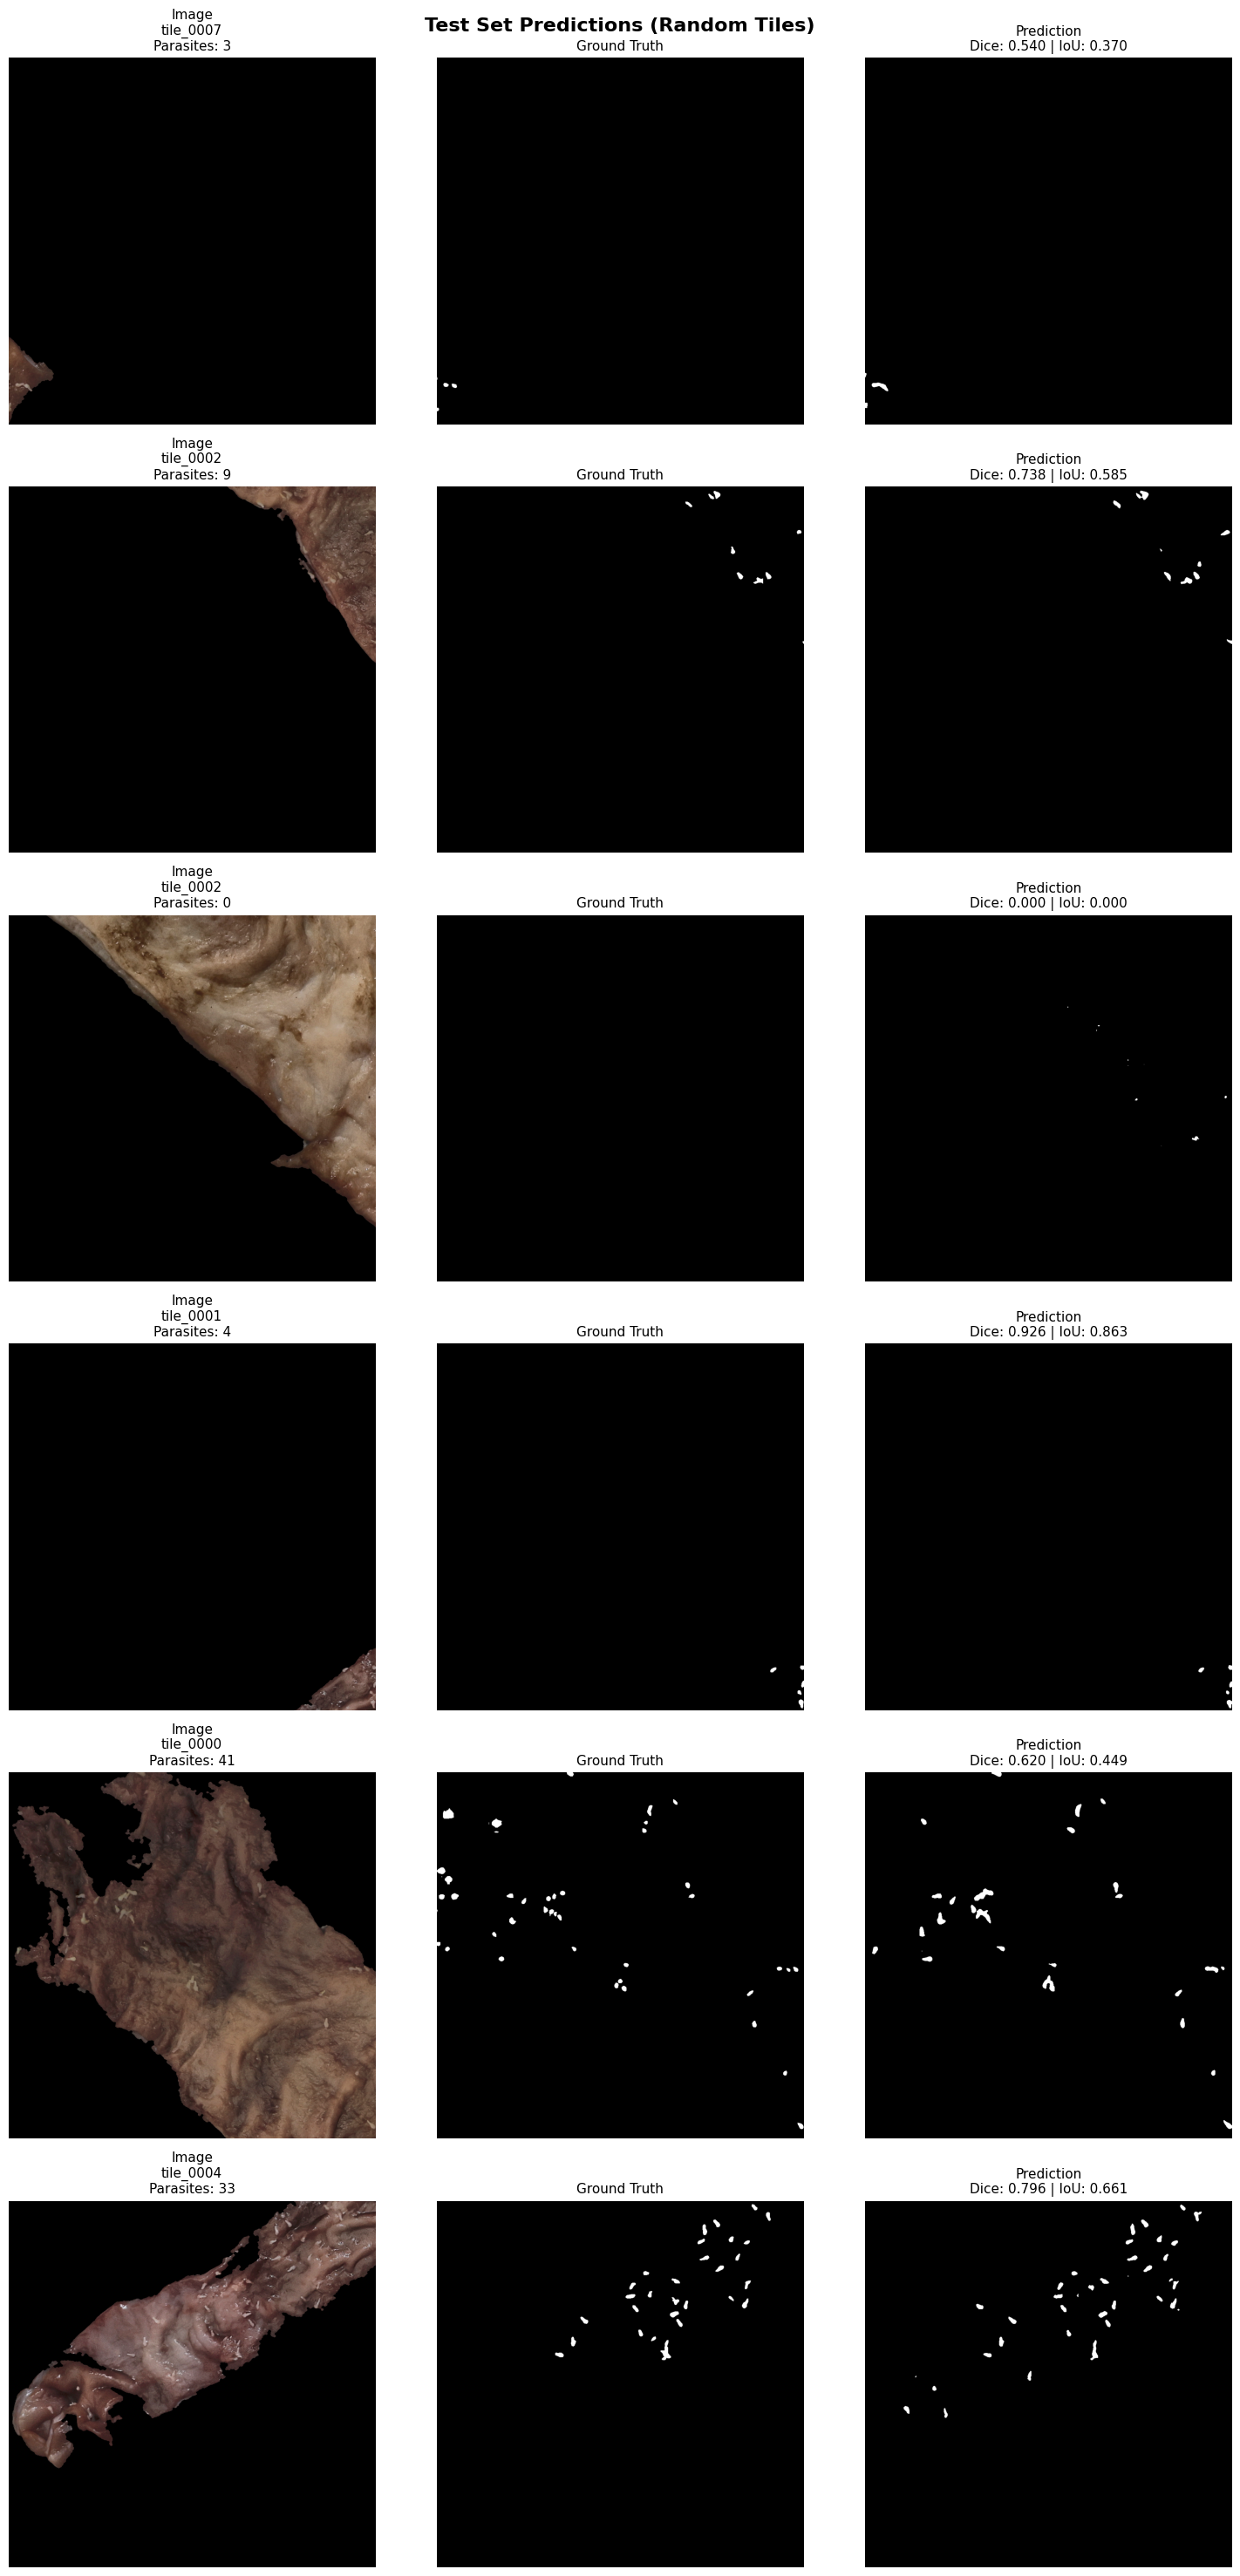

In [ ]:
# Load best checkpoint
best_checkpoint_path = f"{checkpoint_dir}/sam_best.pth"
checkpoint = torch.load(best_checkpoint_path, map_location=device)

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Best Validation Dice: {checkpoint['best_dice']:.4f}")

sam_model, device = load_sam_model()

# Create fine_tuner with same config as training
eval_fine_tuner = SAMFineTuner_LoRA(
    sam_model=sam_model,
    device=device,
    lora_rank=checkpoint['lora_rank'],
    learning_rate=1e-4,
    bce_weight=checkpoint['bce_weight'],
    dice_weight=checkpoint['dice_weight']
)

# Load the trained weights
eval_fine_tuner.sam.load_state_dict(checkpoint['model_state_dict'])
eval_fine_tuner.sam.eval()

test_results = evaluate_on_test(
    fine_tuner=eval_fine_tuner,
    test_dataset=test_dataset,
    batch_size=4,
    visualize=True,         # Show some example predictions
    num_viz_samples=6       # Number of tiles to visualize
)


FULL IMAGE RECONSTRUCTION WITH VISUALIZATION
Testing on 6 images: ['B2025-00231b', 'B2025-00143b', 'B2025-00206b', 'B2025-00136b', 'B2025-00085.2', 'B2025-00142a']

Processing: B2025-00231b...
  Reconstructing: 4096 x 2805 (~131.5MB, 6 tiles)
  Successfully processed 6/6 tiles
  Dice: 0.7525 | IoU: 0.6032 | Precision: 0.7391 | Recall: 0.7664

Processing: B2025-00143b...
  Reconstructing: 3707 x 3687 (~156.4MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7196 | IoU: 0.5620 | Precision: 0.6818 | Recall: 0.7619

Processing: B2025-00206b...
  Reconstructing: 3660 x 3072 (~128.7MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.7193 | IoU: 0.5617 | Precision: 0.6360 | Recall: 0.8279

Processing: B2025-00136b...
  Reconstructing: 4025 x 3433 (~158.1MB, 7 tiles)
  Successfully processed 7/7 tiles
  Dice: 0.8247 | IoU: 0.7017 | Precision: 0.8155 | Recall: 0.8342

Processing: B2025-00085.2...
  Reconstructing: 3207 x 3581 (~131.4MB, 9 tiles)
  Successfully processed 9/9 tiles
 

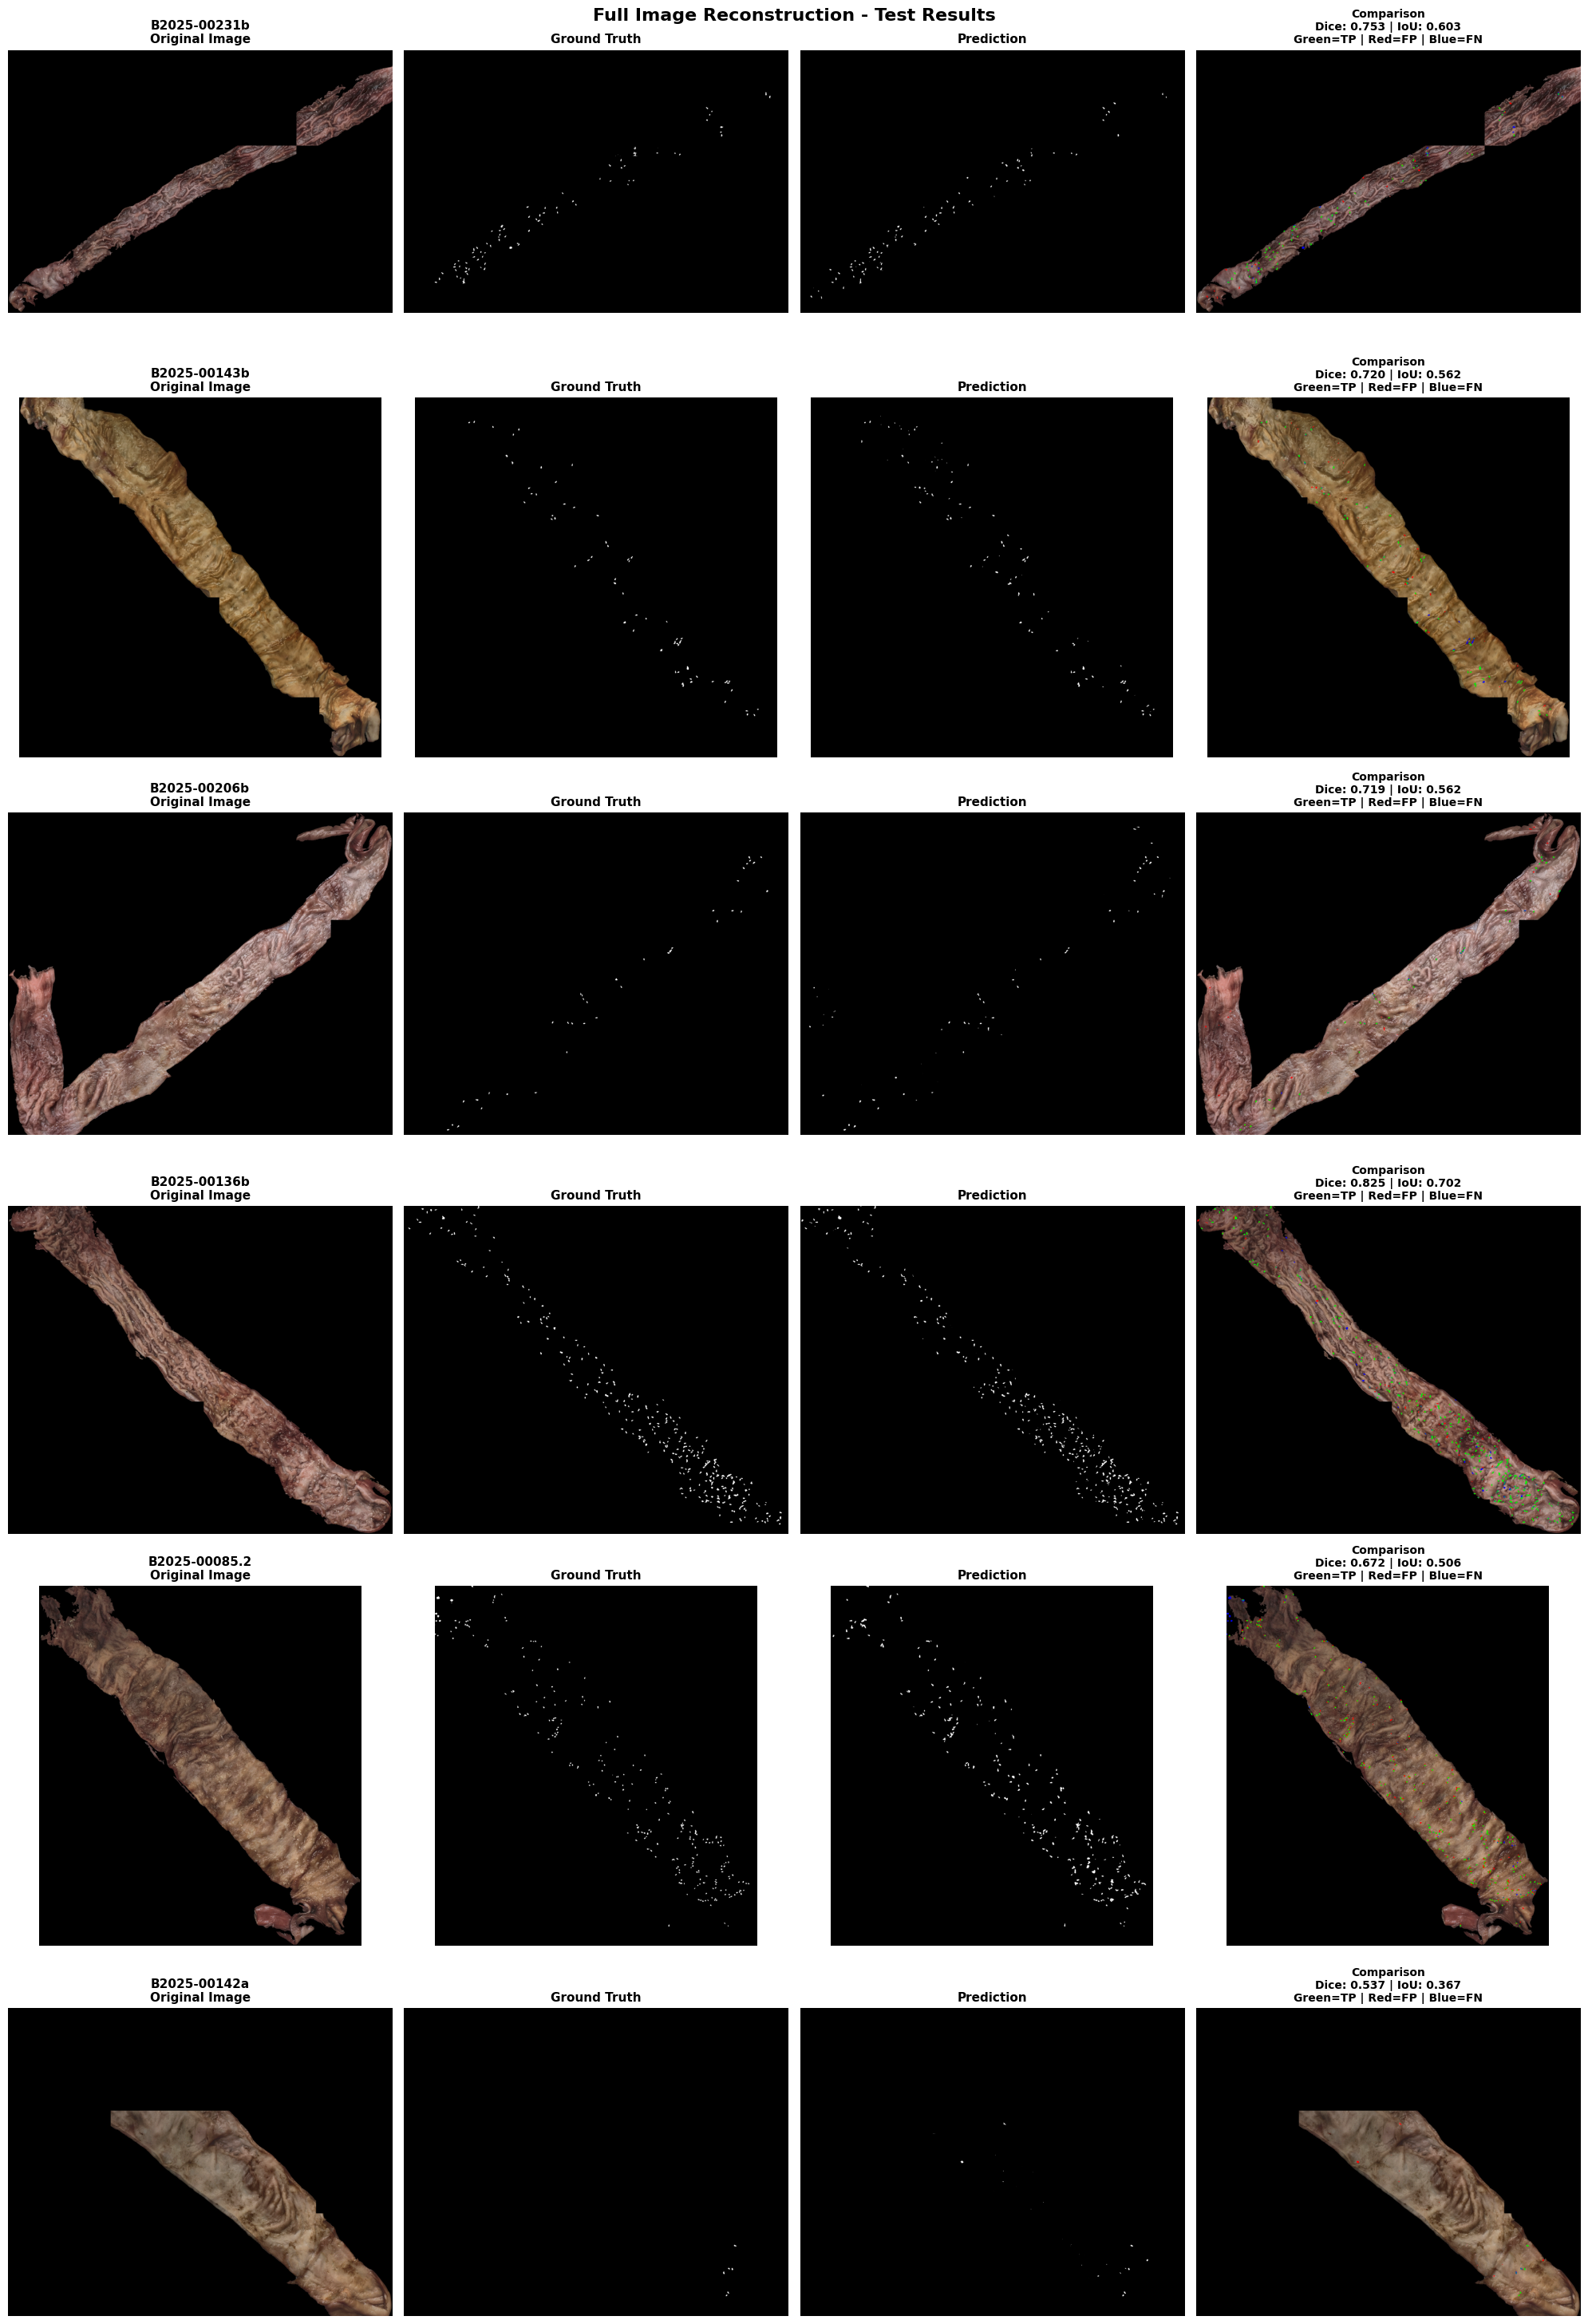

In [ ]:
import pandas as pd
results_df, visualizations = evaluate_full_images(
    fine_tuner=eval_fine_tuner,
    splits=splits,                          # Your train/val/test splits
    test_dataset=test_dataset,
    max_image_size_mb=300,                  # Skip images larger than 300MB
    process_in_chunks=True,                 # Process tiles in chunks
    chunk_size=30,                          # Clear cache every 30 tiles
)